# **Quantity, Exchange and Shift Through Time (QUEST)**
---
Author: Robert Gilmore Pontius Jr, Antonio Fonseca

Institution: Clark University

Email: antfonseca@clarku.edu

Version: 3.0

Updates:

This version includes the new sections:

*   Number of Changes Analysis
*   Updated Heat Maps
*   Extent Change, Alternation Exchange and Alternation Shift Maps





## User Instructions


---
1. Specify only the input parameters in section `1.Environment Setup`, including input raster images, input and output directories, time-series years, and class definitions.  
2. Keep the default settings in all other sections; the notebook will read your inputs and run automatically without additional parameter changes.  
3. Change plotting or cartographic parameters only if you intentionally want to customize a specific map or graph.  
4. Provide input raster maps in the format `*year.tif`, where `year` is the four-digit year of the map and the filename always ends with `year.tif`. Any characters before the year are allowed.  
5. Ensure that all inputs are raster maps with consistent spatial characteristics so that the analysis can process the full time series correctly.




## **1. Environment setup**



In [9]:
# @title 1.1 Setup Environment (run this cell first) { display-mode: "form" }
# @markdown Installs required libraries, loads imports, and connects to Google Drive if running on Colab. No action needed below.

%pip -q install \
    rasterio \
    seaborn \
    xlsxwriter \
    matplotlib-scalebar \
    matplotlib-map-utils

# Standard library
import glob
import os
import re
import pickle
import sys
import time
import math
from pathlib import Path

# Typing for annotations
from typing import Dict, List, Optional, Iterable, Tuple

# Third-party
import numba as nb
import numpy as np
import pandas as pd
import rasterio
import xlsxwriter
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker
from numba import prange
from pyproj import Transformer
from pyproj import CRS, Geod, Transformer
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# Rasterio submodules
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.enums import Resampling
from rasterio.transform import from_origin

# Matplotlib extensions
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow
from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    Normalize,
    LinearSegmentedColormap,
)
from matplotlib.patches import Patch, Rectangle, FancyArrowPatch

# Mount Google Drive only when running on Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

print("Environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.


## **2. Data preparation**

In [12]:
# @title 2.1 Data Input { display-mode: "form" }

# @markdown ### Input Files
# @markdown Folder containing the input raster maps:
INPUT_FOLDER = "/content/drive/MyDrive/Events/2026CGA/workshop/dataset/vcr" #@param {type:"string"}
# @markdown Comma-separated raster file names in chronological order:
INPUT_FILES = "1990.tif, 2000.tif, 2010.tif, 2020.tif" #@param {type:"string"}
# @markdown Pixel value representing NoData:
noData_value = 255 #@param {type:"integer"}

# @markdown ### Output Settings
# @markdown Folder where tables, charts, and maps will be saved:
output_path = "/content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2" #@param {type:"string"}

# @markdown ### Time Settings
# @markdown Comma-separated years corresponding to the input rasters, in chronological order:
YEARS = "1990, 2000, 2010, 2020" #@param {type:"string"}

# @markdown ### Class Settings
# @markdown Fill in ID, Name, and Color for each class. Leave Name blank for rows you don't need (up to 10 classes).
CLASS_1_ID = 1 #@param {type:"integer"}
CLASS_1_NAME = "Trees" #@param {type:"string"}
CLASS_1_COLOR = "#035f1f" #@param {type:"string"}
CLASS_2_ID = 2 #@param {type:"integer"}
CLASS_2_NAME = "Marsh" #@param {type:"string"}
CLASS_2_COLOR = "#7FA35C" #@param {type:"string"}
CLASS_3_ID = 3 #@param {type:"integer"}
CLASS_3_NAME = "Beach" #@param {type:"string"}
CLASS_3_COLOR = "#E8C87A" #@param {type:"string"}
CLASS_4_ID = 4 #@param {type:"integer"}
CLASS_4_NAME = "Water" #@param {type:"string"}
CLASS_4_COLOR = "#3182bd" #@param {type:"string"}
CLASS_5_ID = None #@param {type:"integer"}
CLASS_5_NAME = "" #@param {type:"string"}
CLASS_5_COLOR = "" #@param {type:"string"}

# --- Validation: Input Files ---
image_paths = [
    os.path.join(INPUT_FOLDER, file_name.strip())
    for file_name in INPUT_FILES.split(",")
    if file_name.strip()
]

if not image_paths:
    raise ValueError("Please provide at least one input raster file.")

missing_files = [
    file_path for file_path in image_paths
    if not os.path.isfile(file_path)
]

if missing_files:
    print("Configuration needs attention. Missing raster maps:")
    for file_path in missing_files:
        print(f" - {file_path}")
else:
    print(f"Ready to process {len(image_paths)} input raster maps.")

# --- Validation: Output Folder ---
if not output_path.strip():
    raise ValueError("Please provide an output folder.")

os.makedirs(output_path, exist_ok=True)
print(f"Output folder ready: {output_path}")

# --- Validation: Time Points ---
years = [
    int(year.strip())
    for year in YEARS.split(",")
    if year.strip()
]

if not years:
    raise ValueError("Please provide at least one time point.")
if years != sorted(set(years)):
    raise ValueError("Time points must be unique and in chronological order.")
if len(years) != len(image_paths):
    raise ValueError(
        f"Provide one year for each input raster: {len(image_paths)} files and {len(years)} years."
    )

print(f"Time points configured: {', '.join(map(str, years))}")

# --- Validation: Class Definitions ---
class_slots = [
    (CLASS_1_ID, CLASS_1_NAME, CLASS_1_COLOR),
    (CLASS_2_ID, CLASS_2_NAME, CLASS_2_COLOR),
    (CLASS_3_ID, CLASS_3_NAME, CLASS_3_COLOR),
    (CLASS_4_ID, CLASS_4_NAME, CLASS_4_COLOR),
    (CLASS_5_ID, CLASS_5_NAME, CLASS_5_COLOR),
]

class_labels_dict = {}
for class_id, class_name, class_color in class_slots:
    class_name = class_name.strip()
    class_color = class_color.strip()

    # Skip unused rows (no name provided)
    if not class_name and not class_color:
        continue

    if not class_name or not class_color:
        raise ValueError(
            f"Class ID {class_id}: provide both Name and Color, or leave both blank to skip this row."
        )

    if class_id in class_labels_dict:
        raise ValueError(f"Duplicate class ID: {class_id}. Each class ID must be unique.")

    class_labels_dict[class_id] = {
        "name": class_name,
        "color": class_color
    }

if not class_labels_dict:
    raise ValueError("Please provide at least one class definition.")

class_labels = [
    class_labels_dict[class_id]["name"]
    for class_id in sorted(class_labels_dict)
]

print(f"Configured {len(class_labels)} classes: {', '.join(class_labels)}")
print("Input configuration is valid.")


Ready to process 4 input raster maps.
Output folder ready: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2
Time points configured: 1990, 2000, 2010, 2020
Configured 4 classes: Trees, Marsh, Beach, Water
Input configuration is valid.


## **3. Plot time series maps**

In [13]:
# @title 3.1 Set visualization parameters
def compute_display_pixel_size_km(
    raster_path: str,
    downsample_divisor: int,
) -> float:
    """
    Compute horizontal resolution in kilometers per displayed pixel.

    Parameters
    ----------
    raster_path : str
        Path to a raster file used to derive spatial extent and CRS.
    downsample_divisor : int
        Integer factor used to downsample the raster width for display.

    Returns
    -------
    float
        Pixel size in kilometers for the downsampled display grid.
    """

    with rasterio.open(raster_path) as src:
        left, bottom, right, top = src.bounds
        lat_mid_src = (top + bottom) / 2.0

        to_ll = Transformer.from_crs(
            src.crs,
            "EPSG:4326",
            always_xy=True,
        )
        lon_l, lat_mid = to_ll.transform(
            left,
            lat_mid_src,
        )
        lon_r, _ = to_ll.transform(
            right,
            lat_mid_src,
        )

        geod = Geod(
            ellps="WGS84",
        )
        _, _, width_m = geod.inv(
            lon_l,
            lat_mid,
            lon_r,
            lat_mid,
        )

        cols_disp = max(
            1,
            src.width // downsample_divisor,
        )

        return (width_m / cols_disp) / 1_000

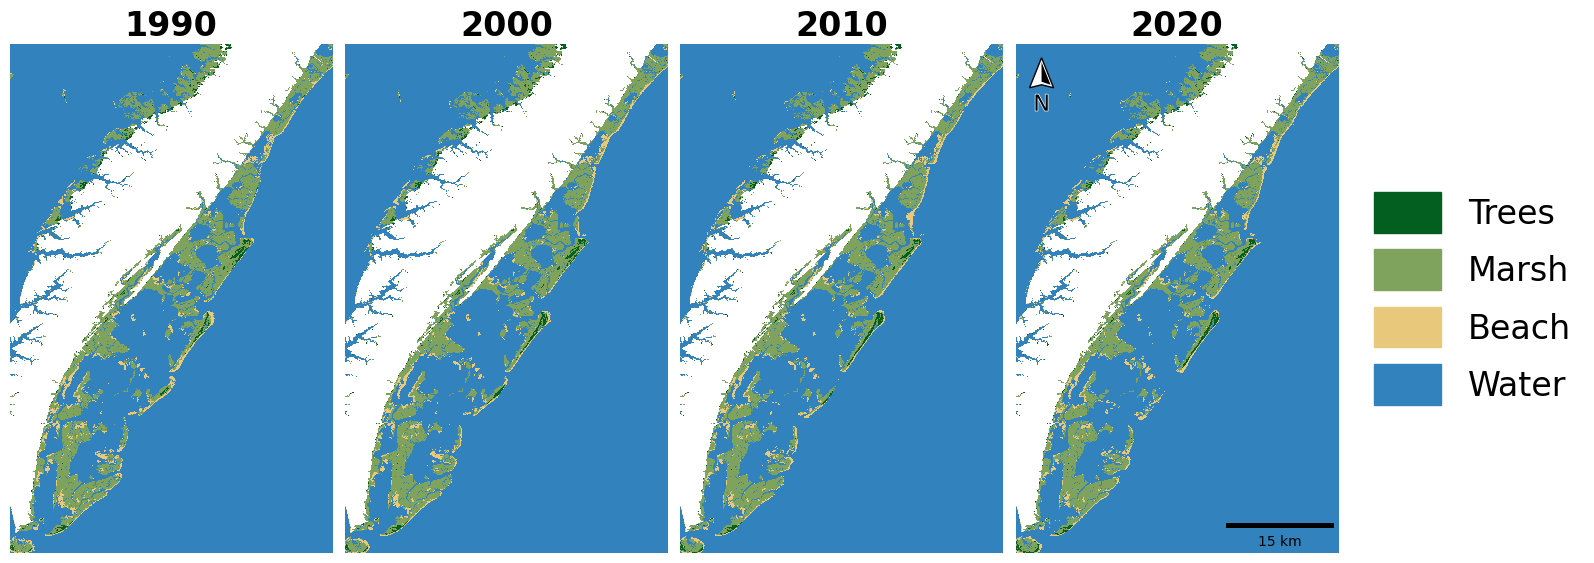

In [14]:
# @title 3.2 Read and plot time series maps
def plot_input_maps(
    class_map: Dict[int, Dict[str, str]],
    years: List[int],
    output_path: str,
    image_paths_arg: List[str],
    nodata_val: int,
    downsample_divisor: int = 1,
    panel_size: tuple = (4.0, 6.0),
    dx_km: Optional[float] = None,
    resampling_method: Resampling = Resampling.nearest,
) -> None:
    """
    Plot classified rasters over time with legend, north arrow, and scale bar.

    Parameters
    ----------
    class_map : Dict[int, Dict[str, str]]
        Mapping from class ID to metadata with at least
        ``{"name": str, "color": str}`` for each class.
    years : List[int]
        List of years corresponding to each classified raster.
    output_path : str
        Directory where input rasters are stored and the figure is saved.
    downsample_divisor : int, optional
        Factor used to downsample raster dimensions for display, by default 1.
    panel_size : tuple, optional
        Width and height in inches for a single panel, by default (4.0, 6.0).
    dx_km : float, optional
        Pixel size in kilometers for the scale bar. If None, it is computed
        from the first raster, by default None.
    resampling_method : Resampling, optional
        Resampling method used when reading rasters, by default
        ``Resampling.bilinear``.

    Returns
    -------
    None
        This function saves a multi-panel figure to disk and shows the plot.
    """

    # Use the explicitly passed list
    if not image_paths_arg:
        raise ValueError("No image paths provided.")

    image_paths = sorted(image_paths_arg)

    # Configure subplot grid with a maximum number of columns
    n_images = len(image_paths)
    max_cols = 10
    ncols = min(
        max_cols,
        n_images,
    )
    nrows = math.ceil(n_images / max_cols)

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(
            panel_size[0] * ncols,
            panel_size[1] * nrows,
        ),
        sharey=True,
        constrained_layout=False,
    )
    plt.subplots_adjust(
        left=0.02,
        right=0.85,
        top=0.95,
        bottom=0.05,
        wspace=0.04,
        hspace=0.04,
    )

    if isinstance(axs, np.ndarray):
        axes = axs.ravel()
    else:
        axes = [axs]

    # Build colormap and normalization for class IDs.
    class_ids_sorted = sorted(class_map.keys())
    cmap = ListedColormap(
        [
            class_map[k]["color"]
            for k in class_ids_sorted
        ],
    )
    norm = BoundaryNorm(
        class_ids_sorted + [class_ids_sorted[-1] + 1],
        cmap.N,
    )

    # Derive km per displayed pixel when not provided.
    if dx_km is None:
        dx_km = compute_display_pixel_size_km(
            raster_path=image_paths[0],
            downsample_divisor=downsample_divisor,
        )

    # Plot each classified raster in its subplot.
    for i, (path, year) in enumerate(
        zip(
            image_paths,
            years,
        ),
    ):
        ax = axes[i]

        with rasterio.open(path) as src:
            h = max(
                1,
                src.height // downsample_divisor,
            )
            w = max(
                1,
                src.width // downsample_divisor,
            )
            data = src.read(
                1,
                out_shape=(
                    h,
                    w,
                ),
                resampling=resampling_method,
            )

        data = np.ma.masked_where(data == nodata_val, data)

        ax.imshow(
            data,
            cmap=cmap,
            norm=norm,
            interpolation="nearest"
        )
        ax.set_title(
            f"{year}",
            fontweight="bold",
            fontsize=24,
        )
        ax.axis("off")

    # Disable unused axes when the grid is larger than the number of images
    for j in range(
        n_images,
        len(axes),
    ):
        axes[j].axis("off")

    # Create legend using all class IDs on the last axis
    legend_elements = [
        Rectangle(
            (0, 0),
            1,
            1,
            color=class_map[k]["color"],
            label=class_map[k]["name"],
        )
        for k in class_map.keys()
    ]

    last_ax = axes[n_images - 1]

    last_ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(
            1.02,
            0.5,
        ),
        frameon=False,
        fontsize=24,
        handlelength=2.0,
        handleheight=1.5,
    )

    # Add scale bar to the last subplot
    scalebar = ScaleBar(
        dx=dx_km,
        units="km",
        length_fraction=0.35,
        location="lower right",
        scale_loc="bottom",
        color="black",
        box_alpha=0,
    )
    axes[n_images - 1].add_artist(
        scalebar,
    )

    # Add north arrow to the last subplot
    north_arrow(
        axes[n_images - 1],
        location="upper left",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3,
    )

    # Save map panel
    maps_dir = os.path.join(
        output_path,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    out_fig = os.path.join(
        maps_dir,
        "map_input_map_panel.png",
    )

    plt.savefig(
        out_fig,
        format="png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
    plt.close()

# Execute function
plot_input_maps(
    class_map=class_labels_dict,
    years=years,
    output_path=output_path,
    image_paths_arg=image_paths,
    nodata_val=noData_value,
    panel_size=(4.0, 6.0),
)

## **4. Class size at time points**
This section calculate pixel counts per class over time, generating a stacked bar chart and exporting the statistical results to a CSV file.

In [ ]:
# @title 4.1 Compute class size at time points
def process_and_save_pixel_counts_csv(
    image_paths,
    years,
    class_labels_dict,
    output_dir,
    no_data_value=noData_value,
):
    """
    Processes raster images in chunks to count pixels per class and exports the results to a CSV file.

    Parameters
    ----------
    image_paths : list of str
        List of file paths to the raster images (must be sorted).
    years : list of str or int
        List of years corresponding to the images.
    class_labels_dict : dict
        Dictionary mapping class IDs to metadata (must contain "name" and "color").
    output_dir : str
        Directory path where the output CSV will be saved.
    no_data_value : int, optional
        Pixel value to be treated as NoData.

    Returns
    -------
    pd.DataFrame
        The pivot table containing pixel counts per year and class.
    """
    # 1. Validate that input lengths match
    if len(image_paths) != len(years):
        raise ValueError(
            f"Input mismatch: {len(image_paths)} images vs {len(years)} years.",
        )

    records: list[dict] = []

    # 2. Iterate through each year and corresponding image path
    for year, path in zip(years, image_paths):
        year_counts = {}

        # 3. Read the raster data using chunk processing
        with rasterio.open(path) as src:
            windows = [window for ij, window in src.block_windows()]
            if not windows:
                windows = []
                for idx in range(0, src.height, 256):
                    height = min(256, src.height - idx)
                    windows.append(rasterio.windows.Window(0, idx, src.width, height))

            for window in tqdm(windows, desc=f"Processing {year}"):
                data = src.read(1, window=window)
                values, counts = np.unique(data, return_counts=True)

                # Accumulate counts for the current chunk
                for value, count in zip(values, counts):
                    value = int(value)
                    if value == no_data_value or value not in class_labels_dict:
                        continue
                    year_counts[value] = year_counts.get(value, 0) + int(count)

        # 4. Map accumulated counts to records
        for value, count in year_counts.items():
            records.append(
                {
                    "Year": year,
                    "ClassID": value,
                    "ClassName": class_labels_dict[value]["name"],
                    "Pixels": count,
                }
            )

    # 5. Create DataFrame and Pivot Table
    df_pixels = pd.DataFrame(records)

    if df_pixels.empty:
        print("No valid pixels found for the defined classes.")
        return pd.DataFrame()

    pivot_pixels = (
        df_pixels.pivot_table(
            index="Year",
            columns="ClassName",
            values="Pixels",
            aggfunc="sum",
        )
        .fillna(0)
        .astype(int)
    )

    # 6. Save CSV file
    tables_dir = os.path.join(output_dir, "tables")
    os.makedirs(tables_dir, exist_ok=True)

    csv_output_path = os.path.join(tables_dir, "pixels_per_class_per_year.csv")
    pivot_pixels.to_csv(csv_output_path, index_label="Year")

    print(f"CSV file saved to: {csv_output_path}")

    return pivot_pixels

# 7. Execute the function
df_result = process_and_save_pixel_counts_csv(
    image_paths=image_paths,
    years=years,
    class_labels_dict=class_labels_dict,
    output_dir=output_path,
    no_data_value=noData_value,
)


Processing 2020: 100%|██████████| 1480/1480 [00:00<00:00, 5775.73it/s]


CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/pixels_per_class_per_year.csv


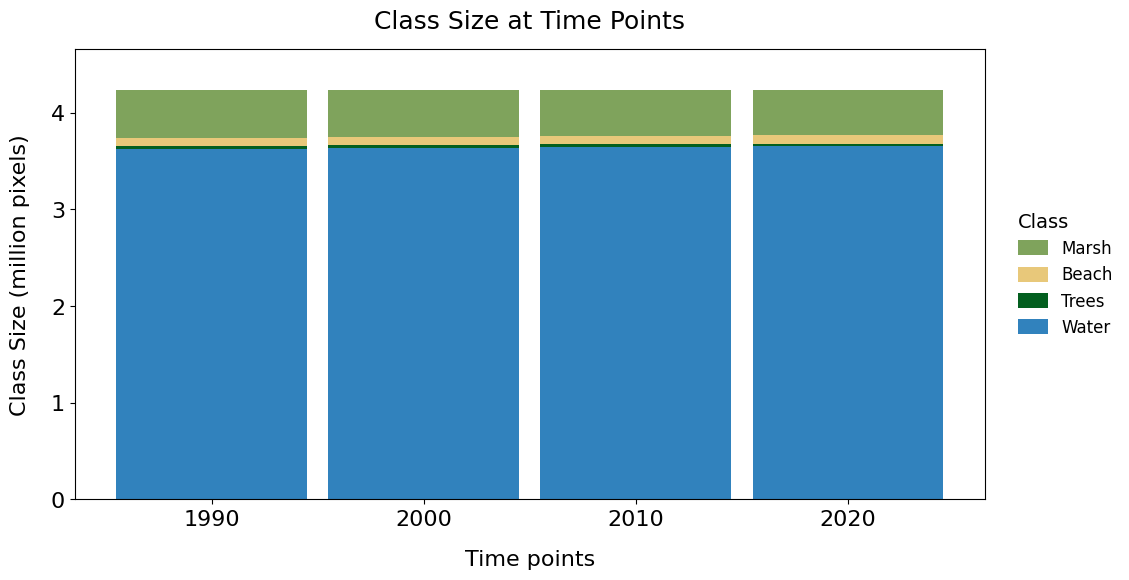

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_class_size_time_points.png


In [ ]:
# @title 4.2 Plot class size at time points
def plot_pixel_counts_bar_chart(
    pivot_pixels: pd.DataFrame,
    class_labels_dict: dict,
    output_dir: str,
) -> None:
    """
    Generates and saves a stacked bar chart of pixel counts per class over time.

    Parameters
    ----------
    pivot_pixels : pd.DataFrame
        The pivot table containing pixel counts per year and class.
    class_labels_dict : dict
        Dictionary mapping class IDs to metadata (must contain "name" and "color").
    output_dir : str
        Directory path where the output plot will be saved.
    """
    years_array = pivot_pixels.index.values

    # 1. Determine Y-axis scaling factor and label
    max_val = pivot_pixels.to_numpy().max()

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Class Size{suffix}"
    pivot_scaled = pivot_pixels / scale_factor

    # 2. Prepare color map and sorting logic
    class_ids_plot = sorted(
        class_labels_dict.keys(),
    )

    color_map = {
        class_labels_dict[class_id]["name"]: class_labels_dict[class_id]["color"]
        for class_id in class_ids_plot
    }

    # Calculate Net Change
    first_year = years_array[0]
    last_year = years_array[-1]
    net_change_per_class = (
        pivot_scaled.loc[last_year]
        - pivot_scaled.loc[first_year]
    )

    # Map names back to IDs for tie-breaking
    name_to_id_map = {
        v["name"]: k
        for k, v in class_labels_dict.items()
    }

    df_sorting = net_change_per_class.to_frame(
        name="net_change",
    )
    df_sorting["class_id"] = df_sorting.index.map(
        name_to_id_map,
    )

    # Sort: Net Change (Desc) then Class ID (Desc)
    classes_for_stack = list(
        df_sorting.sort_values(
            by=[
                "net_change",
                "class_id",
            ],
            ascending=[
                False,
                False,
            ],
        ).index,
    )

    # Legend order: Reversed stack order
    classes_for_legend = list(
        reversed(classes_for_stack),
    )

    # 3. Generate the Stacked Bar Chart
    fig, ax = plt.subplots(
        figsize=(
            14,
            6,
        ),
    )

    x = np.arange(
        len(years_array),
    )
    width = 0.9
    base = np.zeros(
        len(years_array),
        dtype=float,
    )
    patches_by_class: dict[str, plt.Artist] = {}

    for cls in classes_for_stack:
        if cls not in pivot_scaled.columns:
            continue

        values_cls = pivot_scaled[cls].reindex(
            years_array,
            fill_value=0.0,
        ).values

        bars = ax.bar(
            x,
            values_cls,
            bottom=base,
            width=width,
            label=cls,
            color=color_map.get(cls, "gray"),
        )
        patches_by_class[cls] = bars[0]
        base += values_cls

    # 4. Configure Axes
    ax.set_xticks(
        x,
    )
    ax.set_xticklabels(
        years_array,
    )

    # Adaptive rotation for X-axis labels
    n_labels = len(years_array)

    # 0 degrees if <= 6 labels, else 90 degrees
    if n_labels <= 6:
        rotation = 0
        ha = "center"
    else:
        rotation = 90
        ha = "center"

    plt.setp(
        ax.get_xticklabels(),
        rotation=rotation,
        ha=ha,
    )

    ax.tick_params(
        axis="both",
        labelsize=16,
    )
    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15
    )
    ax.set_xlabel(
        "Time points",
        fontsize=16,
        labelpad=15,
    )
    ax.set_title(
        "Class Size at Time Points",
        fontsize=18,
        pad=15
    )

    # Y-axis limit and formatting
    y_max_scaled = base.max() * 1.1 if base.max() > 0 else 1.0
    ax.set_ylim(
        0,
        y_max_scaled,
    )
    ax.yaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=8,
            integer=True,
        ),
    )

    # 5. Add Legend
    handles = [
        patches_by_class[cls]
        for cls in classes_for_legend
        if cls in patches_by_class
    ]
    labels = [
        cls
        for cls in classes_for_legend
        if cls in patches_by_class
    ]

    leg = ax.legend(
        handles,
        labels,
        title="Class",
        title_fontsize=14,
        bbox_to_anchor=(
            1.02,
            0.5,
        ),
        loc="center left",
        frameon=False,
        fontsize=12,
        alignment="left",
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force main plotting box spatial coordinates to match other interval charts
    fig.subplots_adjust(
        left=0.1,
        right=0.75,
        bottom=0.15,
        top=0.9,
    )

    # 6. Save Figure
    charts_dir = os.path.join(
        output_dir,
        "charts",
    )

    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    out_fig = os.path.join(
        charts_dir,
        "chart_class_size_time_points.png",
    )

    plt.savefig(
        out_fig,
        format="png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
    print(f"Chart saved to: {out_fig}")


# 7. Execute the function by reading the saved CSV
tables_dir = os.path.join(
    output_path,
    "tables",
)

csv_input_path = os.path.join(
    tables_dir,
    "pixels_per_class_per_year.csv",
)

# Check if the file exists to avoid errors
if os.path.exists(csv_input_path):
    # Load the CSV into a DataFrame, setting 'Year' back as the index
    df_loaded = pd.read_csv(
        csv_input_path,
        index_col="Year",
    )

    # Generate the plot using the loaded data
    plot_pixel_counts_bar_chart(
        pivot_pixels=df_loaded,
        class_labels_dict=class_labels_dict,
        output_dir=output_path,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}. "
        "Please run the pixel counting cell first."
    )


## **5. Number of Changes**

In [ ]:
# @title 5.1 Compute number of changes
@nb.njit(
    nogil=True,
)
def compute_change_counts_matrix(
    stack: np.ndarray,
    nodata: int,
) -> np.ndarray:
    """
    Counts pixels changing in each interval, categorized by their total
    number of changes across the entire time series.

    Parameters
    ----------
    stack : np.ndarray
        3D array (time, height, width) with pixel values.
    nodata : int
        Value to ignore.

    Returns
    -------
    np.ndarray
        2D array of shape (n_intervals, n_intervals).
        Rows represent time intervals, columns represent the total changes.
    """
    n_times = stack.shape[0]
    height = stack.shape[1]
    width = stack.shape[2]
    n_intervals = n_times - 1

    # 1. Initialize the counts array
    # Rows: Time Intervals (0 to T-1)
    # Cols: Total life changes (0 = 1 total change, 1 = 2 total changes, etc.)
    counts = np.zeros(
        (
            n_intervals,
            n_intervals,
        ),
        dtype=np.int64,
    )

    # 2. Iterate over every pixel in the raster
    for y in range(
        height,
    ):
        for x in range(
            width,
        ):

            # 3. Discover the total number of changes in the pixel's lifetime
            total_changes_for_pixel = 0

            for t in range(
                n_intervals,
            ):
                v_curr = stack[
                    t, y, x,
                ]
                v_next = stack[
                    t + 1, y, x,
                ]

                if v_curr != nodata and v_next != nodata:
                    if v_curr != v_next:
                        total_changes_for_pixel += 1

            # 4. Register the pixel in the intervals where it changed
            # Only proceed if the pixel had at least 1 change in total
            if total_changes_for_pixel > 0:
                for t in range(
                    n_intervals,
                ):
                    v_curr = stack[
                        t, y, x,
                    ]
                    v_next = stack[
                        t + 1, y, x,
                    ]

                    if v_curr != nodata and v_next != nodata:
                        # 5. Check if the pixel changed in THIS specific interval
                        if v_curr != v_next:
                            # Add 1 to the count of this interval
                            # Column index is total changes (-1 to match index 0)
                            counts[
                                t,
                                total_changes_for_pixel - 1,
                            ] += 1

    return counts


def compute_number_change_time_interval(
    image_paths: list[str],
    output_path: str,
    years: list[int],
    nodata_val: int,
) -> pd.DataFrame:
    """
    Load rasters in chunks, compute the total changes per pixel, and save to CSV.

    Parameters
    ----------
    image_paths : list[str]
        List of paths to input rasters.
    output_path : str
        Directory to save the CSV file.
    years : list[int]
        List of years for indexing.
    nodata_val : int
        NoData value.

    Returns
    -------
    pd.DataFrame
        DataFrame with intervals as index and change total as columns.
    """
    # 1. Read metadata from first raster to establish chunks (windows)
    with rasterio.open(image_paths[0]) as src:
        windows = [window for ij, window in src.block_windows()]
        if not windows:
            windows = []
            for idx in range(0, src.height, 256):
                height = min(256, src.height - idx)
                windows.append(rasterio.windows.Window(0, idx, src.width, height))

    n_intervals = len(years) - 1
    raw_counts = np.zeros((n_intervals, n_intervals), dtype=np.int64)

    print(f"Computing total changes per pixel across {len(windows)} chunks...")

    # 2. Iterate through chunks to build stack piecewise
    for window in tqdm(windows, desc="Processing chunks"):
        stack_list = []
        for p in image_paths:
            with rasterio.open(p) as src_layer:
                stack_list.append(src_layer.read(1, window=window))

        stack = np.array(stack_list)

        # 3. Run the Numba-optimized calculation for the chunk and accumulate
        chunk_counts = compute_change_counts_matrix(
            stack=stack,
            nodata=int(nodata_val),
        )
        raw_counts += chunk_counts

    # 4. Find the maximum number of changes observed in total
    max_changes_observed = 0
    if np.any(raw_counts > 0):
        col_sums = raw_counts.sum(axis=0)
        if np.any(col_sums > 0):
            max_changes_observed = np.max(np.nonzero(col_sums))

    # 5. Filter the array up to the maximum observed changes
    relevant_counts = raw_counts[:, :max_changes_observed + 1]

    # 6. Create column names representing total changes from 1 to N
    column_names = [str(i + 1) for i in range(relevant_counts.shape[1])]

    # 7. Create interval labels for the index (e.g., 2000-2001)
    interval_labels = [
        f"{years[i]}-{years[i+1]}" for i in range(len(years) - 1)
    ]

    df_freq = pd.DataFrame(
        relevant_counts,
        index=interval_labels,
        columns=column_names,
    )

    # 8. Save the DataFrame to a CSV file
    tables_dir = os.path.join(output_path, "tables")
    os.makedirs(tables_dir, exist_ok=True)

    csv_filename = os.path.join(tables_dir, "number_change_per_interval.csv")
    df_freq.to_csv(csv_filename)

    print(f"CSV file saved to: {csv_filename}")

    return df_freq

# 9. Execute the function to generate the CSV
df_change_freq = compute_number_change_time_interval(
    image_paths=image_paths,
    output_path=output_path,
    years=years,
    nodata_val=noData_value,
)


Computing total changes per pixel across 1480 chunks...


Processing chunks: 100%|██████████| 1480/1480 [00:32<00:00, 46.02it/s]

CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/number_change_per_interval.csv


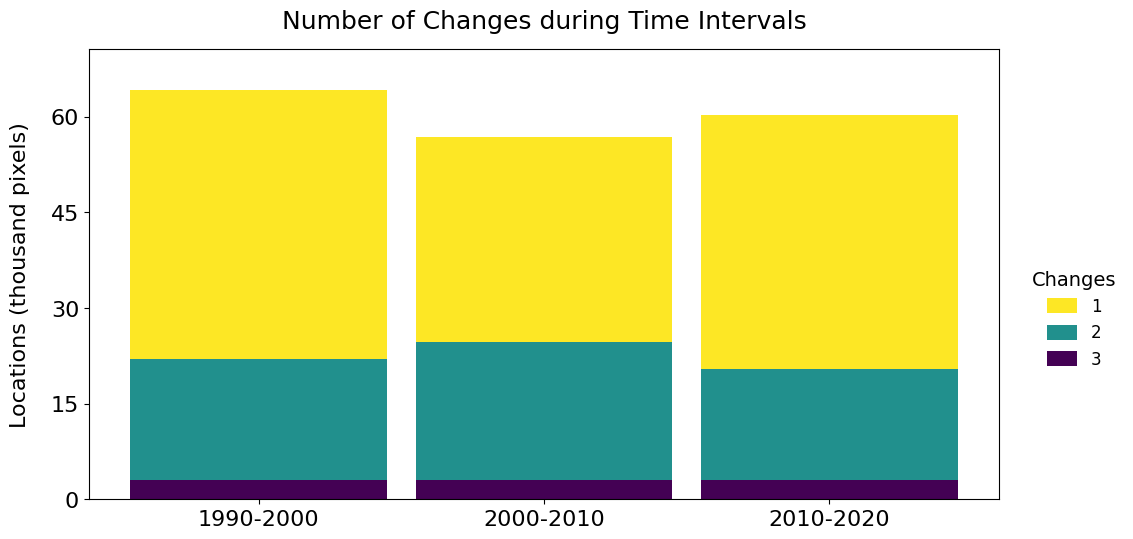

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_number_change_time_interval.png


In [ ]:
# @title 5.2 Plot number of changes during time intervals
def plot_number_change_time_interval(
    df: pd.DataFrame,
    output_path: str,
) -> None:
    """
    Create a stacked bar chart showing the sequence of changes per interval.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with intervals as index and change counts as columns.
    output_path : str
        Directory to save the resulting figure.

    Returns
    -------
    None
    """
    # 1. Determine Unit Scaling (Consistent with Pixels rule requested by advisor)
    max_val = df.sum(
        axis=1,
    ).max()

    if max_val >= 1_000_000_000_000:
        factor = 1_000_000_000_000.0
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        factor = 1_000_000_000.0
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        factor = 1_000_000.0
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        factor = 1_000.0
        suffix = " (thousand pixels)"
    else:
        factor = 1.0
        suffix = " (pixels)"

    df_scaled = df / factor

    # 2. Setup Figure and Colors
    fig, ax = plt.subplots(
        figsize=(
            14,
            6,
        ),
    )

    n_cols = len(
        df.columns,
    )

    # 3. Use viridis_r to invert the colormap (light to dark sequence)
    cmap = plt.cm.viridis_r

    if n_cols > 1:
        colors = [
            cmap(
                i / (
                    n_cols - 1
                ),
            )
            for i in range(
                n_cols,
            )
        ]
    else:
        colors = [
            cmap(
                0.5,
            ),
        ]

    # 4. Plot Stacked Bars
    bottom = pd.Series(
        0.0,
        index=df_scaled.index,
    )

    for i, col in reversed(
        list(
            enumerate(
                df.columns,
            )
        )
    ):
        vals = df_scaled[
            col
        ]

        # Legend showing only the number as requested
        if vals.sum() == 0:
            label_txt = "_nolegend_"
        else:
            label_txt = f"{col}"

        ax.bar(
            df_scaled.index,
            vals,
            bottom=bottom,
            label=label_txt,
            color=colors[
                i
            ],
            edgecolor="none",
            linewidth=0.5,
            width=0.9,
        )
        bottom += vals

    # 5. Formatting Axes and Labels
    y_label_text = f"Locations{suffix}"

    ax.set_ylabel(
        y_label_text,
        fontsize=16,
        labelpad=15,
    )

    # Dynamically set y-axis limits and ticks
    max_y = df_scaled.sum(axis=1).max()
    ax.set_ylim(0, max_y * 1.1 if max_y > 0 else 1.0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

    ax.set_title(
        "Number of Changes during Time Intervals",
        fontsize=18,
        pad=15,
    )

    # 6. X-Axis labels

    # Adaptive rotation for X-axis labels based on the number of intervals
    labels = ax.get_xticklabels()
    n_labels = len(labels)

    if n_labels <= 6:
        rotation = 0
        ha = "center"
    elif n_labels <= 12:
        rotation = 45
        ha = "right"
    else:
        rotation = 90
        ha = "center"

    plt.setp(
        labels,
        rotation=rotation,
        ha=ha,
        fontsize=16
    )

    ax.tick_params(
        axis="y",
        rotation=0,
        labelsize=16,
    )

    # 7. Legend
    handles, labels = ax.get_legend_handles_labels()

    # Store the legend in a variable to modify its elements
    leg = ax.legend(
        handles[::-1],
        labels[::-1],
        title="Changes",
        title_fontsize=14,
        bbox_to_anchor=(
            1.02,
            0.4,
        ),
        loc="center left",
        frameon=False,
        fontsize=12,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Iterate over the color boxes in the legend and remove the border
    for patch in leg.get_patches():
        patch.set_linewidth(
            0,
        )

    # Force main plotting box spatial coordinates to match other interval charts
    fig.subplots_adjust(
        left=0.1,
        right=0.75,
        bottom=0.15,
        top=0.9,
    )

    # 9. Save Figure
    charts_dir = os.path.join(
        output_path,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    output_fig = os.path.join(
        charts_dir,
        "chart_number_change_time_interval.png",
    )

    plt.savefig(
        output_fig,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Chart saved to: {output_fig}",
    )

# Execution by reading the saved CSV
tables_dir = os.path.join(
    output_path,
    "tables",
)

csv_input_path = os.path.join(
    tables_dir,
    "number_change_per_interval.csv",
)

# Check if the file exists to avoid errors
if os.path.exists(csv_input_path):
    # Load the CSV, setting the first column (intervals) as the index
    df_loaded_freq = pd.read_csv(
        csv_input_path,
        index_col=0,
    )

    # Generate the plot using the loaded data
    plot_number_change_time_interval(
        df=df_loaded_freq,
        output_path=output_path,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}. "
        "Please run the number of changes calculation cell first."
    )


In [ ]:
# @title 5.3 Compute number of changes overall (default)
def compute_number_change_overall(
    output_dir: str,
) -> pd.DataFrame:
    """
    Compute the overall number of changes by summing the interval counts.

    Parameters
    ----------
    output_dir : str
        The base output directory where 'tables' subfolder is located.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the overall sum of changes per category.
    """
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )

    csv_input_path = os.path.join(
        tables_dir,
        "number_change_per_interval.csv",
    )

    # Verify if the input CSV exists before processing
    if not os.path.exists(
        csv_input_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_input_path}. "
            "Please run the 'Compute Number of Changes' cell first to generate this file."
        )
        return None

    # Load the interval CSV
    df_intervals = pd.read_csv(
        csv_input_path,
        index_col=0,
    )

    # Sum across the intervals (summing each column)
    overall_sums = df_intervals.sum(
        axis=0,
    )

    # Convert the Series to a DataFrame
    df_overall = pd.DataFrame(
        overall_sums,
        columns=[
            "Pixels",
        ],
    )
    df_overall.index.name = "Changes"

    # Save to a new summary CSV
    csv_output_path = os.path.join(
        tables_dir,
        "number_change_overall_summary.csv",
    )

    df_overall.to_csv(
        csv_output_path,
    )

    print(
        f"CSV file saved to: {csv_output_path}",
    )

    return df_overall

# Execute the function
df_change_overall = compute_number_change_overall(
    output_dir=output_path,
)

if df_change_overall is not None:
    display(
        df_change_overall,
    )


CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/number_change_overall_summary.csv


,Pixels
Changes,
1,114079
2,58266
3,8838


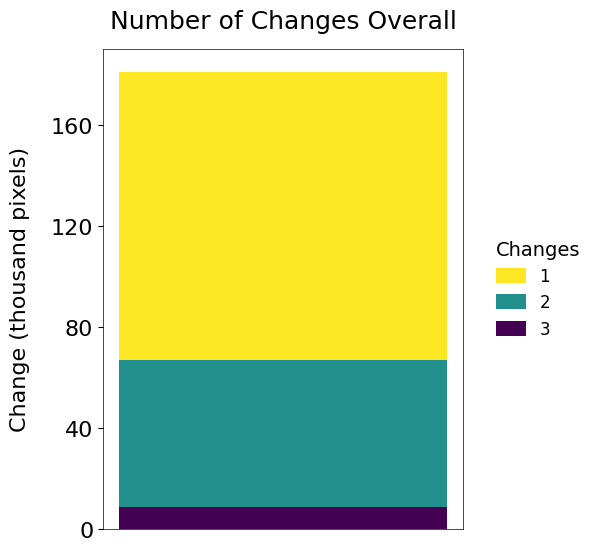

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_number_changes_pixels_overall_default.png


In [ ]:
# @title 5.4 Plot number of changes overall (default)
def plot_number_of_changes_overall_from_csv(
    output_dir: str,
) -> None:
    """
    Read the summary CSV for overall number of changes and plot it as a stacked bar chart
    using the standard layout for number of pixels.

    Parameters
    ----------
    output_dir : str
        The base output directory where the 'tables' subfolder is located.

    Returns
    -------
    None
    """
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    csv_input_path = os.path.join(
        tables_dir,
        "number_change_overall_summary.csv",
    )

    if not os.path.exists(
        csv_input_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_input_path}.",
        )
        return

    # Load the summary CSV
    df = pd.read_csv(
        csv_input_path,
        index_col="Changes",
    )

    # Setup Colors based on all changes
    all_changes = list(
        df.index,
    )
    active_changes = [
        k for k, v in df[
            "Pixels"
        ].items() if v > 0
    ]

    if not active_changes:
        active_changes = all_changes

    n_colors = len(
        all_changes,
    )
    cmap = plt.cm.viridis_r

    sorted_changes_desc = sorted(
        active_changes,
        reverse=True,
    )

    colors = {
        n: cmap(
            i / (
                n_colors - 1
            ),
        ) if n_colors > 1 else cmap(
            0.5,
        )
        for i, n in enumerate(
            sorted(
                all_changes,
            ),
        )
    }

    # Create the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            6,
        ),
    )

    bottom = 0.0
    for n_change in sorted_changes_desc:
        val = df.loc[
            n_change,
            "Pixels",
        ]
        if val > 0:
            ax.bar(
                0,
                val,
                bottom=bottom,
                color=colors[
                    n_change
                ],
                width=0.4,
                edgecolor="none",
            )
            bottom += val

    # Formatting the Axes
    max_val = bottom

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Change{suffix}"

    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15,
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, pos: f"{x / scale_factor:g}",
        )
    )

    ax.set_title(
        "Number of Changes Overall",
        fontsize=18,
        pad=15,
    )

    for spine in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )
        ax.spines[
            spine
        ].set_color(
            "black",
        )
        ax.spines[
            spine
        ].set_linewidth(
            0.5,
        )

    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )
    ax.set_xticks(
        [],
    )

    # ----- Y-Axis Dynamic Scaling Logic -----
    max_y_unscaled = bottom
    max_ylim = max_y_unscaled * 1.05 if max_y_unscaled > 0 else 1.0
    ax.set_ylim(
        0,
        max_ylim,
    )

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=max(6, int(max_ylim) + 2) if max_ylim < 20 else 6,
        )
    )
    # ----------------------------------------

    # Legend
    legend_elements = [
        Patch(
            facecolor=colors[
                n
            ],
            label=str(
                n,
            ),
        )
        for n in sorted(
            active_changes,
        )
    ]

    ax.legend(
        handles=legend_elements,
        title="Changes",
        title_fontsize=14,
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        fontsize=12,
        alignment="left",
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force main plotting box spatial coordinates
    fig.subplots_adjust(
        left=0.15,
        right=0.75,
        bottom=0.1,
        top=0.9,
    )

    # Save and show
    charts_dir = os.path.join(
        output_dir,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )
    out_fig_path = os.path.join(
        charts_dir,
        "chart_number_changes_pixels_overall_default.png",
    )

    plt.savefig(
        out_fig_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()
    print(
        f"Chart saved to: {out_fig_path}",
    )

# Execute function
plot_number_of_changes_overall_from_csv(
    output_dir=output_path,
)


### 5.5 Optinal number of changes overall

#### 5.5.1 Percentage of study area

In [ ]:
# @title 5.5.1.1 Compute the percentage of the study area with change
def compute_percentage_of_study_area_with_change_csv(
    df_intervals: pd.DataFrame,
    image_paths: list[str],
    nodata_val: int,
    output_dir: str,
) -> pd.DataFrame:
    """
    Calculate the true number of unique pixels and their percentage
    relative to the valid study area for each change category,
    and save the results to a CSV file.

    Parameters
    ----------
    df_intervals : pd.DataFrame
        DataFrame containing interval change frequencies.
    image_paths : list of str
        List of file paths to the raster images used to determine the total valid study area.
    nodata_val : int
        Pixel value to be treated as NoData.
    output_dir : str
        Directory path where the output CSV will be saved.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the changes, unique pixels, and percentage of the valid study area.
    """
    # 1. Total valid study area (Chunk-based processing)
    total_study_area_pixels = 0
    with rasterio.open(
        image_paths[0],
    ) as src:
        windows = [
            window for ij, window in src.block_windows()
        ]
        if not windows:
            for idx in range(0, src.height, 256):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

        for window in tqdm(
            windows,
            desc="Calculating study area",
        ):
            chunk = src.read(
                1,
                window=window,
            )
            total_study_area_pixels += np.sum(
                chunk != nodata_val,
            )

    # 2. Calculate unique pixels and percentages
    records = []
    for col_name in df_intervals.columns:
        n_changes = int(
            col_name,
        )
        total_transitions = df_intervals[
            col_name
        ].sum()

        # Divide by n_changes because a pixel that changed N times
        # appears N times across the intervals
        if n_changes > 0:
            unique_pixels = total_transitions / n_changes
        else:
            unique_pixels = 0

        if total_study_area_pixels > 0:
            pct = (
                unique_pixels / total_study_area_pixels
            ) * 100.0
        else:
            pct = 0.0

        records.append(
            {
                "Changes": n_changes,
                "Unique_Pixels": int(
                    unique_pixels,
                ),
                "Percentage": pct,
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # 3. Save to CSV
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "percentage_of_study_area_with_change.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )

    return df_dist

# Execution
tables_dir = os.path.join(
    output_path,
    "tables",
)
csv_input_path = os.path.join(
    tables_dir,
    "number_change_per_interval.csv",
)

if os.path.exists(
    csv_input_path,
):
    df_loaded_freq = pd.read_csv(
        csv_input_path,
        index_col=0,
    )

    df_distribution = compute_percentage_of_study_area_with_change_csv(
        df_intervals=df_loaded_freq,
        image_paths=image_paths,
        nodata_val=noData_value,
        output_dir=output_path,
    )
    display(
        df_distribution,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}. Please run the previous calculation cells.",
    )

Calculating study area: 100%|██████████| 1480/1480 [00:00<00:00, 10084.43it/s]

CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/percentage_of_study_area_with_change.csv


,Changes,Unique_Pixels,Percentage
0,1,114079,2.695162
1,2,29133,0.688279
2,3,2946,0.069600


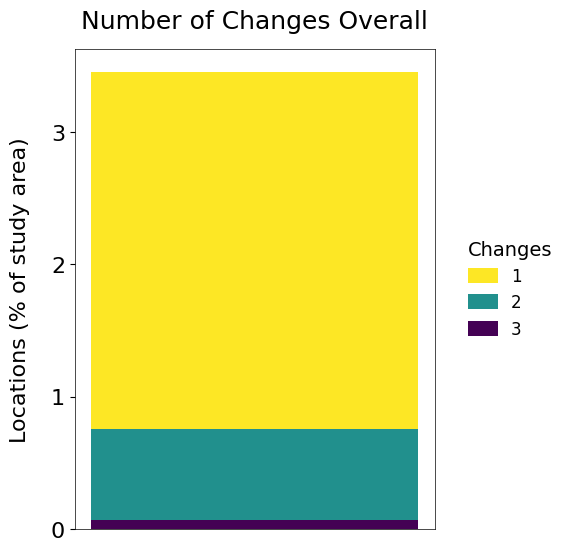

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_number_changes_percentage_overall.png


In [ ]:
# @title 5.5.1.2 Plot percentage of study area with change
def plot_percentage_of_study_area_with_change(
    output_dir: str,
) -> None:
    """
    Generate a single stacked bar chart of the number of changes distribution.

    This function reads the previously calculated percentages of unique pixels
    from the CSV file and plots them relative to the ENTIRE valid study area.

    Parameters
    ----------
    output_dir : str
        Directory to read the CSV file from and save the resulting figure.

    Returns
    -------
    None
    """
    # 1. Read the CSV file
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    csv_path = os.path.join(
        tables_dir,
        "percentage_of_study_area_with_change.csv",
    )

    if not os.path.exists(
        csv_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_path}. "
            "Please run the previous calculation cells."
        )
        return

    df_dist = pd.read_csv(
        csv_path,
    )

    # 2. Extract percentages and changes
    percentages = dict(
        zip(
            df_dist["Changes"],
            df_dist["Percentage"],
        )
    )

    # 4. Setup Colors
    all_changes = df_dist["Changes"].tolist()

    active_changes = [
        k for k, v in percentages.items()
        if v > 0
    ]

    if not active_changes:
        active_changes = all_changes

    n_colors = len(
        all_changes,
    )
    cmap = plt.cm.viridis_r

    sorted_changes_desc = sorted(
        active_changes,
        reverse=True,
    )

    colors = {
        n: cmap(
            i / (n_colors - 1)
        )
        if n_colors > 1
        else cmap(0.5)
        for i, n in enumerate(
            sorted(
                all_changes,
            )
        )
    }

    # 5. Create the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            6,
        ),
    )

    bottom = 0.0
    for n_change in sorted_changes_desc:
        val = percentages[
            n_change
        ]
        if val > 0:
            ax.bar(
                0,
                val,
                bottom=bottom,
                color=colors[
                    n_change
                ],
                width=0.4,
                edgecolor="none",
            )
            bottom += val

    # 6. Formatting the Axes
    ax.set_ylabel(
        "Locations (% of study area)",
        fontsize=16,
        labelpad=15,
    )

    ax.set_title(
        "Number of Changes Overall",
        fontsize=18,
        pad=15,
    )

    for spine in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )
        ax.spines[
            spine
        ].set_color(
            "black",
        )
        ax.spines[
            spine
        ].set_linewidth(
            0.5,
        )

    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )

    ax.set_xticks(
        [],
    )

    # Note: Keep Y-axis limit at 105 so the scale is always absolute
    max_y = bottom * 1.05 if bottom > 0 else 1.0

    ax.set_ylim(
        0,
        max_y,
    )

    # Define the number of bins
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=10,
        ),
    )

    # 7. Legend
    legend_elements = []

    for n in sorted(active_changes):
        legend_elements.append(
            Patch(
                facecolor=colors[n],
                label=str(n),
            )
        )

    ax.legend(
        handles=legend_elements,
        title="Changes",
        title_fontsize=14,
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        fontsize=12,
        alignment="left",
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force the main plotting box to always occupy the exact same spatial coordinates in the figure
    fig.subplots_adjust(
        left=0.15,
        right=0.75,
        bottom=0.1,
        top=0.9
    )

    # 8. Save and show the figure
    charts_dir = os.path.join(
        output_dir,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    out_fig_path = os.path.join(
        charts_dir,
        "chart_number_changes_percentage_overall.png",
    )

    plt.savefig(
        out_fig_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()
    print(
        f"Chart saved to: {out_fig_path}",
    )

# Execution
plot_percentage_of_study_area_with_change(
    output_dir=output_path,
)


#### 5.5.2 Location of changes

In [ ]:
# @title 5.5.2.1 Compute location of changes

def compute_number_of_changes_location_csv(
    df_intervals: pd.DataFrame,
    output_dir: str,
) -> pd.DataFrame:
    """
    Calculate the true number of unique pixels that underwent
    1, 2, 3, or N total changes, and save to CSV.

    Parameters
    ----------
    df_intervals : pd.DataFrame
        DataFrame containing interval change frequencies.
    output_dir : str
        Base directory to save output tables.

    Returns
    -------
    pd.DataFrame
        A DataFrame representing the location distribution of changes.
    """
    records = []
    for col_name in df_intervals.columns:
        n_changes = int(
            col_name,
        )
        total_transitions = df_intervals[
            col_name
        ].sum()

        # Divide by n_changes to get unique pixels
        if n_changes > 0:
            unique_pixels = (
                total_transitions / n_changes
            )
        else:
            unique_pixels = 0

        records.append(
            {
                "Changes": n_changes,
                "Unique_Pixels": int(
                    unique_pixels,
                ),
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # Save to CSV
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "number_of_changes_location.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )
    return df_dist

# Execution
tables_dir = os.path.join(
    output_path,
    "tables",
)
csv_input_path = os.path.join(
    tables_dir,
    "number_change_per_interval.csv",
)

if os.path.exists(
    csv_input_path,
):
    df_loaded_freq = pd.read_csv(
        csv_input_path,
        index_col=0,
    )
    df_distribution = compute_number_of_changes_location_csv(
        df_intervals=df_loaded_freq,
        output_dir=output_path,
    )
    display(
        df_distribution,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}.",
    )


CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/number_of_changes_location.csv


,Changes,Unique_Pixels
0,1,114079
1,2,29133
2,3,2946


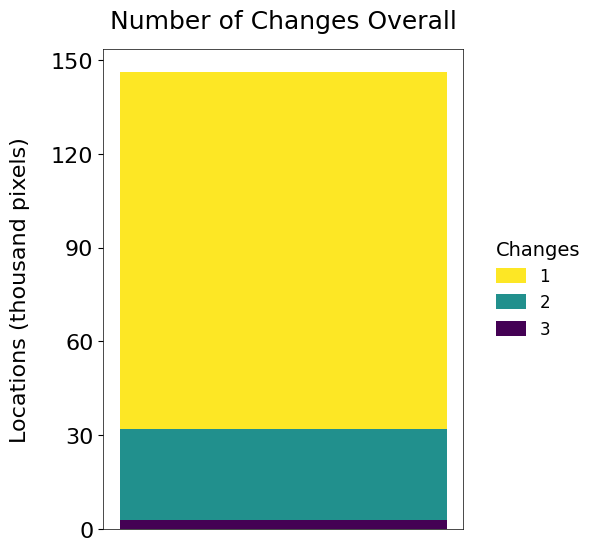

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_number_changes_pixels_overall.png


In [ ]:
# @title 5.5.2.2 Plot location of changes

def plot_number_of_changes_distribution_csv(
    output_dir: str,
) -> None:
    """
    Generate a single stacked bar chart of the number of changes distribution
    by reading the previously saved CSV.

    Parameters
    ----------
    output_dir : str
        The base output directory where the 'tables' subfolder is located.

    Returns
    -------
    None
    """
    # 1. Read the CSV file
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    csv_path = os.path.join(
        tables_dir,
        "number_of_changes_location.csv",
    )

    if not os.path.exists(
        csv_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_path}.",
        )
        return

    df_dist = pd.read_csv(
        csv_path,
    )

    # 2. Extract values
    unique_pixels_per_change = dict(
        zip(
            df_dist[
                "Changes"
            ],
            df_dist[
                "Unique_Pixels"
            ],
        )
    )

    # 3. Setup Colors
    all_changes = df_dist[
        "Changes"
    ].tolist()

    active_changes = [
        k for k, v in unique_pixels_per_change.items()
        if v > 0
    ]

    if not active_changes:
        active_changes = all_changes

    n_colors = len(
        all_changes,
    )
    cmap = plt.cm.viridis_r

    sorted_changes_desc = sorted(
        active_changes,
        reverse=True,
    )

    colors = {
        n: cmap(
            i / (
                n_colors - 1
            )
        ) if n_colors > 1 else cmap(
            0.5,
        )
        for i, n in enumerate(
            sorted(
                all_changes,
            ),
        )
    }

    # 4. Create the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            6,
        ),
    )

    bottom = 0.0
    for n_change in sorted_changes_desc:
        val = unique_pixels_per_change[
            n_change
        ]
        if val > 0:
            ax.bar(
                0,
                val,
                bottom=bottom,
                color=colors[
                    n_change
                ],
                width=0.4,
                edgecolor="none",
            )
            bottom += val

    # 5. Formatting the Axes
    max_val = bottom

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Locations{suffix}"

    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15,
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, pos: f"{x / scale_factor:g}",
        ),
    )

    ax.set_title(
        "Number of Changes Overall",
        fontsize=18,
        pad=15,
    )

    for spine in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )
        ax.spines[
            spine
        ].set_color(
            "black",
        )
        ax.spines[
            spine
        ].set_linewidth(
            0.5,
        )

    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )
    ax.set_xticks(
        [],
    )

    max_y = bottom * 1.05 if bottom > 0 else 1.0
    ax.set_ylim(
        0,
        max_y,
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=max(6, int(max_y) + 2) if max_y < 20 else 6,
        )
    )

    # 6. Legend
    legend_elements = []
    for n in sorted(
        active_changes,
    ):
        legend_elements.append(
            Patch(
                facecolor=colors[
                    n
                ],
                label=str(
                    n,
                ),
            ),
        )

    ax.legend(
        handles=legend_elements,
        title="Changes",
        title_fontsize=14,
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        fontsize=12,
        alignment="left",
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    fig.subplots_adjust(
        left=0.15,
        right=0.75,
        bottom=0.1,
        top=0.9,
    )

    # 7. Save and show the figure
    charts_dir = os.path.join(
        output_dir,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    out_fig_path = os.path.join(
        charts_dir,
        "chart_number_changes_pixels_overall.png",
    )

    plt.savefig(
        out_fig_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()
    print(
        f"Chart saved to: {out_fig_path}",
    )

# Execution
plot_number_of_changes_distribution_csv(
    output_dir=output_path,
)


### 5.6 Number of changes map

In [ ]:
# @title 5.6.1 Compute number of changes raster map
@nb.njit(
    nogil=True,
)
def compute_number_of_changes_chunk(
    stack: np.ndarray,
    nodata: int,
) -> np.ndarray:
    """
    Numba-optimized function to calculate the total number of changes per pixel.

    Parameters
    ----------
    stack : np.ndarray
        3D numpy array (time, height, width) for a specific spatial chunk.
    nodata : int
        Value representing NoData pixels.

    Returns
    -------
    np.ndarray
        2D numpy array (height, width) with the total number of changes.
    """
    time_steps = stack.shape[
        0
    ]
    h = stack.shape[
        1
    ]
    w = stack.shape[
        2
    ]

    out_changes = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )

    for y in range(
        h,
    ):
        for x in range(
            w,
        ):
            traj = stack[
                :,
                y,
                x,
            ]

            # Check for NoData in any time step
            has_nodata = False
            for t in range(
                time_steps,
            ):
                if traj[
                    t
                ] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            # Calculate total changes
            changes = 0
            for t in range(
                time_steps - 1,
            ):
                if traj[
                    t
                ] != traj[
                    t + 1
                ]:
                    changes += 1

            out_changes[
                y,
                x,
            ] = changes

    return out_changes


def number_of_changes_raster(
    file_list: list,
    output_dir: str,
    nodata_val: int,
    compress: str = "deflate",
) -> str:
    """
    Compute and save a raster representing the total number of class changes per pixel,
    using Numba optimization and chunk-based processing.

    Parameters
    ----------
    file_list : list
        List of file paths to the input raster images.
    output_dir : str
        Directory to save the output raster.
    nodata_val : int
        Value representing NoData pixels to be ignored in comparisons.
    compress : str, optional
        Compression algorithm to use (default is "deflate").

    Returns
    -------
    str
        Path to the output raster map.
    """
    image_paths = sorted(
        file_list,
    )

    # 1. Read metadata from first raster
    with rasterio.open(
        image_paths[
            0
        ],
    ) as src:
        profile = src.profile.copy()

        profile.update(
            dtype=rasterio.uint8,
            count=1,
            nodata=nodata_val,
            compress=compress,
        )

        if compress == "deflate":
            profile.update(
                zlevel=9,
            )

        profile.pop(
            "blockxsize",
            None,
        )
        profile.pop(
            "blockysize",
            None,
        )
        profile.pop(
            "tiled",
            None,
        )

        # Use block windows if tiled, or row-by-row chunks
        windows = [
            window for ij, window in src.block_windows()
        ]

        if not windows:
            windows = []
            for idx in range(
                0,
                src.height,
                256,
            ):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

    # 2. Setup output path
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    os.makedirs(
        rasters_dir,
        exist_ok=True,
    )
    out_raster_path = os.path.join(
        rasters_dir,
        "number_of_changes.tif",
    )

    print(
        f"Computing number of changes across {len(windows)} chunks...",
    )

    # 3. Open writer and process chunks
    with rasterio.open(
        out_raster_path,
        "w",
        **profile,
    ) as dst:
        for window in tqdm(
            windows,
            desc="Processing chunks",
        ):
            stack_list = []

            for path in image_paths:
                with rasterio.open(
                    path,
                ) as src_layer:
                    stack_list.append(
                        src_layer.read(
                            1,
                            window=window,
                        ),
                    )

            stack = np.array(
                stack_list,
                dtype=np.uint8,
            )

            # Apply Numba-accelerated calculation
            chunk_changes = compute_number_of_changes_chunk(
                stack,
                nodata_val,
            )

            # Write chunk to output raster
            dst.write(
                chunk_changes,
                1,
                window=window,
            )

    print(
        f"\nRaster map saved to: {out_raster_path}",
    )
    return out_raster_path

# Execute the function using input_paths
number_of_changes_raster(
    file_list=image_paths,
    output_dir=output_path,
    nodata_val=noData_value,
    compress="deflate",
)


Computing number of changes across 1480 chunks...


Processing chunks: 100%|██████████| 1480/1480 [00:29<00:00, 49.69it/s]


Raster map saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/number_of_changes.tif


'/content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/number_of_changes.tif'

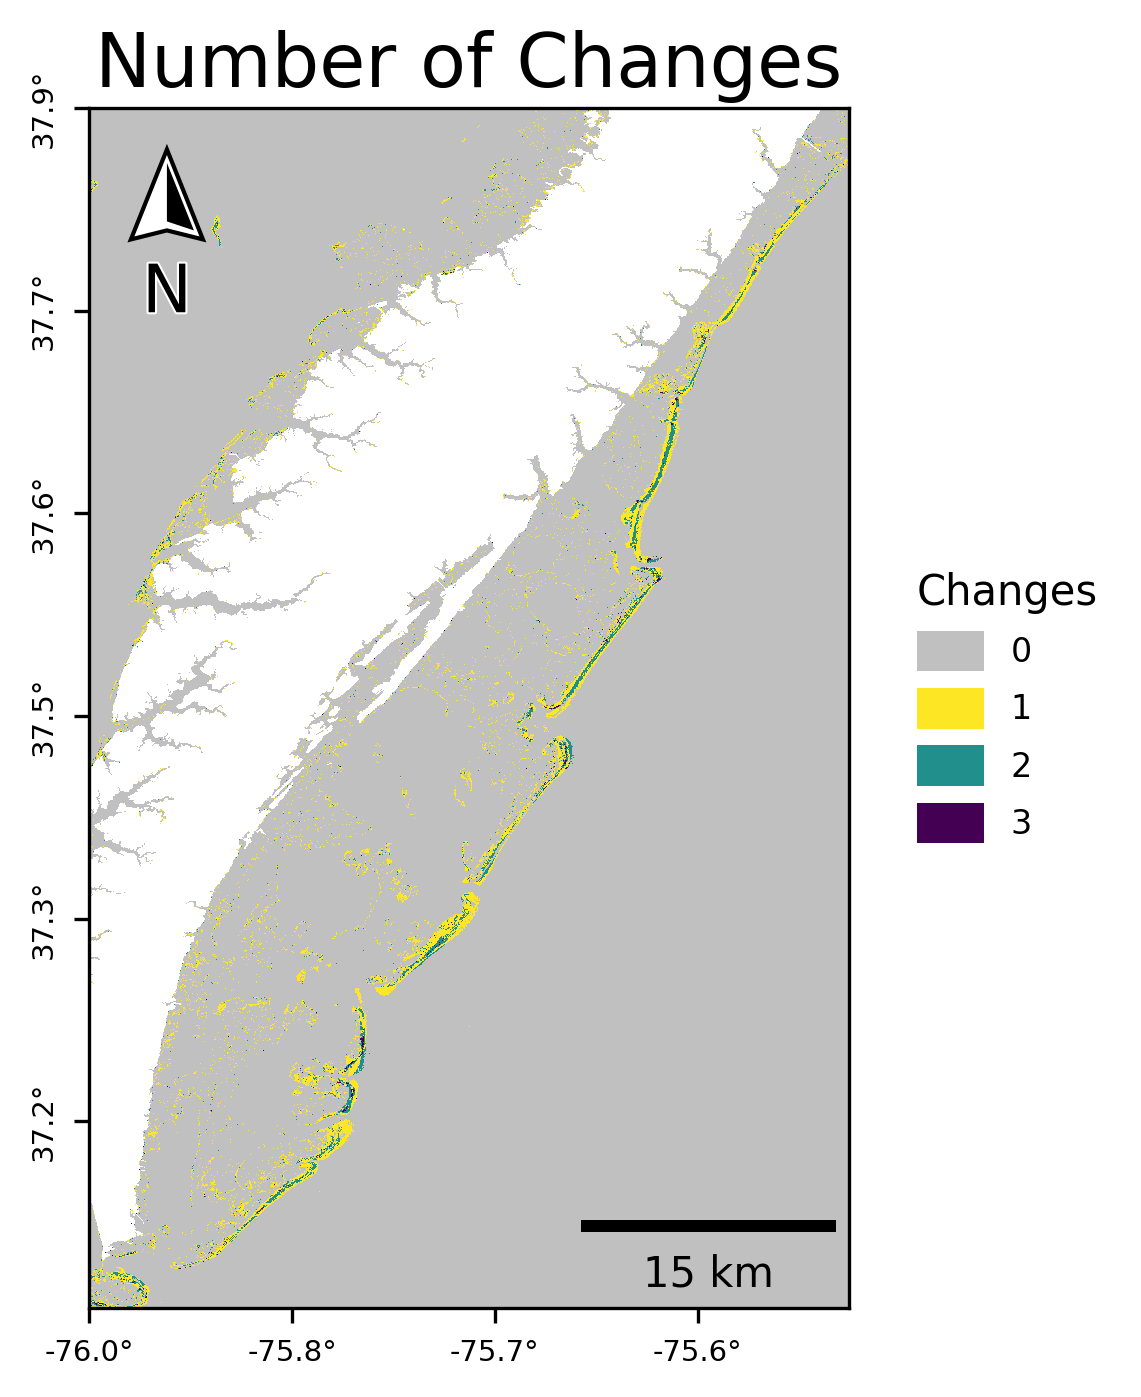

Map figure saved successfully to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/maps/map_number_of_changes.png


In [ ]:
# @title 5.6.2 Plot number of changes map
def plot_number_of_changes_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "number_of_changes.tif",
) -> None:
    """
    Plot the Number of Changes raster map with cartographic elements.

    Parameters
    ----------
    output_dir : str
        Directory containing the raster file and where the map will be saved.
    nodata_val : int
        Value representing NoData in the raster to be masked out.
    raster_filename : str, optional
        Name of the raster file to plot (default is "number_of_changes.tif").

    Returns
    -------
    None
        This function does not return a value; it saves a PNG file to disk
        and displays the plot.

    Raises
    ------
    FileNotFoundError
        If the specified raster file does not exist in the output directory.
    """

    # 1) Input raster path
    # Point to the 'rasters' subfolder
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )

    raster_to_plot_path = os.path.join(
        rasters_dir,
        raster_filename,
    )

    if not os.path.exists(raster_to_plot_path):
        raise FileNotFoundError(
            f"Raster not found: {raster_to_plot_path}. Make sure the raster was created first.",
        )

    # Calculate pixel size for scale bar
    pixel_size_km = compute_display_pixel_size_km(
        raster_path=raster_to_plot_path,
        downsample_divisor=1
    )

    # 2) Read raster and basic metadata
    with rasterio.open(
        raster_to_plot_path,
    ) as src:
        scale_factor = 1

        data = src.read(
            1,
            out_shape=(
                int(src.height * scale_factor),
                int(src.width * scale_factor),
            ),
            resampling=rasterio.enums.Resampling.nearest,
        )

        # Force masking using the provided variable
        data = np.ma.masked_equal(
            data,
            nodata_val,
        )

        left, bottom, right, top = src.bounds
        src_crs = src.crs
        transform = src.transform

    # 3) Figure (Fixed size for identical map areas)
    fig, ax = plt.subplots(
        figsize=(10, 5),
        dpi=300,
    )

    # Fix the map bounding box to exact coordinates inside the figure
    fig.subplots_adjust(
        left=0.1,
        right=0.7,
        top=0.9,
        bottom=0.1
    )

    # Data range
    min_val = int(
        np.ma.min(
            data,
        ),
    )
    max_val = int(
        np.ma.max(
            data,
        ),
    )

    # 4) Colormap (gray for 0 + jet for 1..max)
    original_cmap = plt.get_cmap(
        "viridis_r",
    )
    color_list = [
        "#c0c0c0",
    ] + [
        original_cmap(i)
        for i in np.linspace(
            0,
            1,
            max_val,
        )
    ]
    cmap = ListedColormap(
        color_list,
    )

    # Discrete normalization
    bounds = np.arange(
        min_val,
        max_val + 2,
    ) - 0.5
    norm = BoundaryNorm(
        bounds,
        cmap.N,
    )

    # 5) Plot raster in original projection coordinates
    ax.imshow(
        data,
        cmap=cmap,
        interpolation="nearest",
        norm=norm
    )

    # 6) Discrete box legend
    legend_elements = []

    # Find out which values actually exist in the valid map pixels
    present_values = np.unique(
        data.compressed()
    )

    for i in range(
        min_val,
        max_val + 1,
    ):
        # Append the item to the legend ONLY if the class exists in the raster
        if i in present_values:
            legend_elements.append(
                Patch(
                    facecolor=cmap(
                        norm(i),
                    ),
                    edgecolor="none",
                    linewidth=0,
                    label=str(i),
                ),
            )

    ax.legend(
        handles=legend_elements,
        title="Changes",
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left",
        handlelength=2.0,
        handleheight=1.5,
    )

    # 7) Cartographic elements
    scalebar = ScaleBar(
        dx=pixel_size_km,
        units="km",
        length_fraction=0.35,
        location="lower right",
        scale_loc="bottom",
        color="black",
        box_alpha=0,
        scale_formatter=lambda value, _: f"{int(value)} km",
    )
    ax.add_artist(
        scalebar,
    )

    # Add north arrow to the last subplot
    north_arrow(
        ax,
        location="upper left",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3,
    )

    # 8) Axes styling (with Lat/Lon labels)
    ax.set_title(
        "Number of Changes",
        fontsize=18,
        pad=5,
    )
    ax.set_aspect(
        "equal",
    )

    # Initialize Transformer (Native CRS -> Lat/Lon)
    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )

    # Get dimensions from the loaded data
    height, width = data.shape

    def format_lon(
        x,
        pos,
    ):
        # Clamp x to be within image bounds
        x = np.clip(
            x,
            0,
            width - 1,
        )
        # Project pixel to map coordinates (using middle of height)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            height // 2,
            x,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lon:.1f}°"

    def format_lat(
        y,
        pos,
    ):
        # Clamp y to be within image bounds
        y = np.clip(
            y,
            0,
            height - 1,
        )
        # Project pixel to map coordinates (using middle of width)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            y,
            width // 2,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lat:.1f}°"

    # Apply the custom formatters
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            format_lon,
        ),
    )
    ax.yaxis.set_major_formatter(
        FuncFormatter(
            format_lat,
        ),
    )

    # Limit ticks to avoid overcrowding
    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=4,
        ),
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=6,
        ),
    )

    # Final styling for ticks
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        pad=4,
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=90,
        va="center",
    )

    # 9) Save (REMOVED bbox_inches="tight" to maintain identical dimensions)
    maps_dir = os.path.join(
        output_dir,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    output_figure_path = os.path.join(
        maps_dir,
        "map_number_of_changes.png",
    )

    plt.savefig(
        output_figure_path,
        format="png",
        dpi=300,
        pad_inches=0.05,
    )
    plt.show()

    print(
        f"Map figure saved successfully to: {output_figure_path}",
    )

# Execute the function
plot_number_of_changes_map(
    output_dir=output_path,
    nodata_val=noData_value
)


## **6. Trajectory Classification**


In [ ]:
# @title 6.1 Compute trajectory raster map
@nb.njit(
    nogil=True,
)
def classify_pixel(
    pixel_series: np.ndarray,
    nodata_val: int,
) -> np.uint8:
    """
    Classify a single pixel trajectory into five categories based on MatricesMain11 logic.

    Parameters
    ----------
    pixel_series : np.ndarray
        A 1D numpy array representing the land cover class values
        of a single pixel over time.
    nodata_val : int
        The integer value representing no data.

    Returns
    -------
    np.uint8
        An integer representing the trajectory class:
        1: All stable (Gray)
        2: Extent stable with alternation (Red)
        3: Extent change without alternation (Yellow)
        4: Extent change with alternation - Direct transition exists (Orange)
        5: Extent change - Unaccounted/No direct transition (Dark Blue)
        0: NoData
    """
    # 1. Get the length of the time series
    length = len(
        pixel_series,
    )

    # 2. Check for empty or NoData series
    if length == 0:
        return np.uint8(
            nodata_val,
        )

    for i in range(
        length,
    ):
        if pixel_series[i] == nodata_val:
            return np.uint8(
                nodata_val,
            )

    # 3. Identify Start and End classes
    start = pixel_series[
        0
    ]
    end = pixel_series[
        length - 1
    ]

    # 4. Logic for Stable Extent (Start == End)
    if start == end:
        is_completely_stable = True

        # Check if any intermediate value differs from start
        for i in range(
            1,
            length,
        ):
            if pixel_series[i] != start:
                is_completely_stable = False
                break

        if is_completely_stable:
            # Trajectory 1: All stable
            return np.uint8(
                1,
            )
        else:
            # Trajectory 2: Extent stable with alternation
            return np.uint8(
                2,
            )

    # 5. Logic for Extent Change (Start != End)
    else:
        # Check if the direct transition (Start -> End) exists at any step
        has_direct_transition = False

        for i in range(
            length - 1,
        ):
            if pixel_series[i] == start and pixel_series[i + 1] == end:
                has_direct_transition = True
                break

        if not has_direct_transition:
            # Trajectory 5: Extent change with alternation shift (Unaccounted)
            # The transition Start->End never happens directly.
            return np.uint8(
                5,
            )

        else:
            # Direct transition exists. Now distinguish T3 vs T4.
            # We calculate the "path length" (ignoring consecutive duplicates)

            path_changes = 0
            last_val = start

            for i in range(
                1,
                length,
            ):
                current_val = pixel_series[
                    i
                ]
                if current_val != last_val:
                    path_changes += 1
                    last_val = current_val

            # If there is exactly 1 change (Start -> ... -> End), it is T3.
            if path_changes == 1:
                # Trajectory 3: Extent change without alternation
                return np.uint8(
                    3,
                )
            else:
                # Trajectory 4: Extent change with alternation (Direct exists)
                return np.uint8(
                    4,
                )


@nb.njit(
    nogil=True,
    parallel=True,
)
def compute_trajectory_chunk_parallel(
    stack: np.ndarray,
    nodata_val: int,
) -> np.ndarray:
    """
    Apply pixel classification to a 3D raster stack using parallel processing.

    Parameters
    ----------
    stack : np.ndarray
        A 3D numpy array of shape (time, height, width) containing
        the stacked raster data.
    nodata_val : int
        The integer value representing no data.

    Returns
    -------
    np.ndarray
        A 2D numpy array of shape (height, width) containing the
        classified trajectory codes (uint8).
    """
    height = stack.shape[
        1
    ]
    width = stack.shape[
        2
    ]

    # 1. Initialize result array with zeros
    result = np.zeros(
        (
            height,
            width,
        ),
        dtype=np.uint8,
    )

    # 2. Iterate over rows in parallel
    for y in prange(
        height,
    ):
        for x in range(
            width,
        ):
            # 3. Extract time series for pixel (y, x)
            pixel_series = stack[
                :,
                y,
                x,
            ]

            # 4. Classify the pixel
            result[
                y,
                x,
            ] = classify_pixel(
                pixel_series,
                nodata_val,
            )

    return result


def generate_trajectory_raster(
    file_list: list,
    output_dir: str,
    nodata_val: int,
    compress: str = "deflate",
) -> str:
    """
    Load time-series rasters, classify trajectories (1-5), and save the result
    using chunk-based processing to optimize memory usage.

    Parameters
    ----------
    file_list : list
        List of file paths to the raster images.
    output_dir : str
        The directory path where the output file will be saved.
    nodata_val : int
        The integer value representing no data.
    compress : str, optional
        Compression algorithm to use (default is "deflate").

    Returns
    -------
    str
        The full file path to the generated trajectory raster.
    """
    if not file_list:
        raise ValueError(
            "The provided file list is empty.",
        )

    image_paths = sorted(
        file_list,
    )

    # 1. Read metadata and set chunk windows from the first image
    with rasterio.open(
        image_paths[
            0
        ],
    ) as src:
        profile = src.profile.copy()
        current_nodata = int(
            nodata_val,
        )

        profile.update(
            dtype=np.uint8,
            count=1,
            nodata=current_nodata,
            compress=compress,
        )

        if compress == "deflate":
            profile.update(
                zlevel=9,
            )

        profile.pop(
            "blockxsize",
            None,
        )
        profile.pop(
            "blockysize",
            None,
        )
        profile.pop(
            "tiled",
            None,
        )

        windows = [
            window for ij, window in src.block_windows()
        ]

        if not windows:
            windows = []
            for idx in range(
                0,
                src.height,
                256,
            ):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

    # 2. Define output filename
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    os.makedirs(
        rasters_dir,
        exist_ok=True,
    )

    out_file = os.path.join(
        rasters_dir,
        "trajectory.tif",
    )

    print(
        f"Computing trajectory classification across {len(windows)} chunks...",
    )

    # 3. Process each chunk and write to disk
    with rasterio.open(
        out_file,
        "w",
        **profile,
    ) as dst:
        for window in tqdm(
            windows,
            desc="Processing chunks",
        ):
            stack_list = []
            for path in image_paths:
                with rasterio.open(
                    path,
                ) as src_layer:
                    stack_list.append(
                        src_layer.read(
                            1,
                            window=window,
                        ),
                    )

            stack = np.array(
                stack_list,
                dtype=np.uint8,
            )

            # Apply Numba-accelerated classification per chunk
            trajectory_chunk = compute_trajectory_chunk_parallel(
                stack,
                current_nodata,
            )

            dst.write(
                trajectory_chunk,
                1,
                window=window,
            )

    print(
        f"\nRaster map saved: {out_file}",
    )

    return out_file

# Execute trajectory analysis
trajectory_file = generate_trajectory_raster(
    file_list=image_paths,
    output_dir=output_path,
    nodata_val=noData_value,
    compress="deflate",
)


Computing trajectory classification across 1480 chunks...


Processing chunks: 100%|██████████| 1480/1480 [00:49<00:00, 29.71it/s]


Raster map saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/trajectory.tif


In [ ]:
# @title 6.2 Compute trajectories during time intervals
@nb.njit(
    nogil=True,
    fastmath=True,
)
def compute_trajectory_changes(
    trajectory_map: np.ndarray,
    stack: np.ndarray,
    nodata: int,
) -> np.ndarray:
    """
    Count pixels per trajectory type changing in each time interval using Numba.

    Parameters
    ----------
    trajectory_map : np.ndarray
        2D array (height, width) with trajectory IDs (2, 3, 4, 5).
    stack : np.ndarray
        3D array (time, height, width) with pixel values.
    nodata : int
        Value to ignore.

    Returns
    -------
    np.ndarray
        2D array of shape (n_intervals, 6) containing change counts.
        Rows correspond to time intervals.
        Columns correspond to trajectory IDs (0 to 5).
    """
    n_times = stack.shape[0]
    height = stack.shape[1]
    width = stack.shape[2]
    n_intervals = n_times - 1

    # Array to store counts: rows=intervals, cols=trajectory_ids(0-5)
    # We use 6 columns to map the trajectory ID directly as an index
    counts = np.zeros(
        (
            n_intervals,
            6,
        ),
        dtype=np.int64,
    )

    # Iterate over every pixel
    for y in range(
        height,
    ):
        for x in range(
            width,
        ):
            traj_id = trajectory_map[
                y,
                x,
            ]

            # We only care about Alternation(2), Step(3), Complex(4), Unaccounted(5)
            if traj_id < 2 or traj_id > 5:
                continue

            # Check changes across all time intervals
            for t in range(
                n_intervals,
            ):
                val_from = stack[
                    t,
                    y,
                    x,
                ]
                val_to = stack[
                    t + 1,
                    y,
                    x,
                ]

                # Check validity
                if (
                    val_from != nodata
                    and val_to != nodata
                    and val_from != val_to
                ):
                    counts[
                        t,
                        traj_id,
                    ] += 1

    return counts


def analyze_trajectory_intervals(
    image_paths: list[str],
    output_path: str,
    years: list[int],
    nodata_val: int,
) -> pd.DataFrame:
    """
    Load data in chunks, compute trajectory interval contributions, and save CSV.

    Parameters
    ----------
    image_paths : list[str]
        List of paths to input rasters.
    output_path : str
        Base directory containing the trajectory raster.
    years : list[int]
        List of years corresponding to the images.
    nodata_val : int
        NoData value to ignore.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the counts per interval and trajectory type.
    """
    # 1. Trajectory Map Path
    traj_path = os.path.join(
        output_path,
        "rasters",
        "trajectory.tif",
    )

    if not os.path.exists(
        traj_path,
    ):
        raise FileNotFoundError(
            f"Trajectory raster not found at: {traj_path}",
        )

    # 2. Read metadata to establish chunks (windows)
    with rasterio.open(traj_path) as src:
        windows = [window for ij, window in src.block_windows()]
        if not windows:
            windows = []
            for idx in range(0, src.height, 256):
                height = min(256, src.height - idx)
                windows.append(rasterio.windows.Window(0, idx, src.width, height))

    n_intervals = len(years) - 1
    raw_counts = np.zeros((n_intervals, 6), dtype=np.int64)

    print(f"Computing interval contributions across {len(windows)} chunks...")

    # 3. Iterate through chunks
    for window in tqdm(windows, desc="Processing chunks"):
        with rasterio.open(traj_path) as src_traj:
            trajectory_map = src_traj.read(1, window=window)

        stack_list = []
        for p in image_paths:
            with rasterio.open(p) as src:
                stack_list.append(src.read(1, window=window))

        stack = np.array(stack_list)

        # 4. Compute Counts using Numba for the chunk
        chunk_counts = compute_trajectory_changes(
            trajectory_map=trajectory_map,
            stack=stack,
            nodata=nodata_val,
        )
        raw_counts += chunk_counts

    # 5. Format Results into DataFrame
    # Extract only columns 2, 3, 4, 5
    relevant_counts = raw_counts[
        :,
        2:6,
    ]

    # Generate interval labels (e.g., "1985-1986")
    interval_labels = [
        f"{years[i]}-{years[i+1]}"
        for i in range(
            len(years) - 1,
        )
    ]

    df_results = pd.DataFrame(
        relevant_counts,
        index=interval_labels,
        columns=[
            2,
            3,
            4,
            5
        ],
    )

    # Rename columns for clarity in CSV
    df_results.index.name = "Interval"
    df_results.columns.name = "Trajectory_Class"

    # 6. Save to CSV
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    output_csv = os.path.join(
        tables_dir,
        "trajectory_contributions_per_interval.csv",
    )

    df_results.to_csv(
        output_csv,
    )

    print(
        f"CSV file saved to: {output_csv}",
    )

    return df_results


# Execution
df_trajectory_intervals = analyze_trajectory_intervals(
    image_paths=image_paths,
    output_path=output_path,
    years=years,
    nodata_val=noData_value,
)


Computing interval contributions across 740 chunks...


Processing chunks: 100%|██████████| 740/740 [00:29<00:00, 25.46it/s]

CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/trajectory_contributions_per_interval.csv


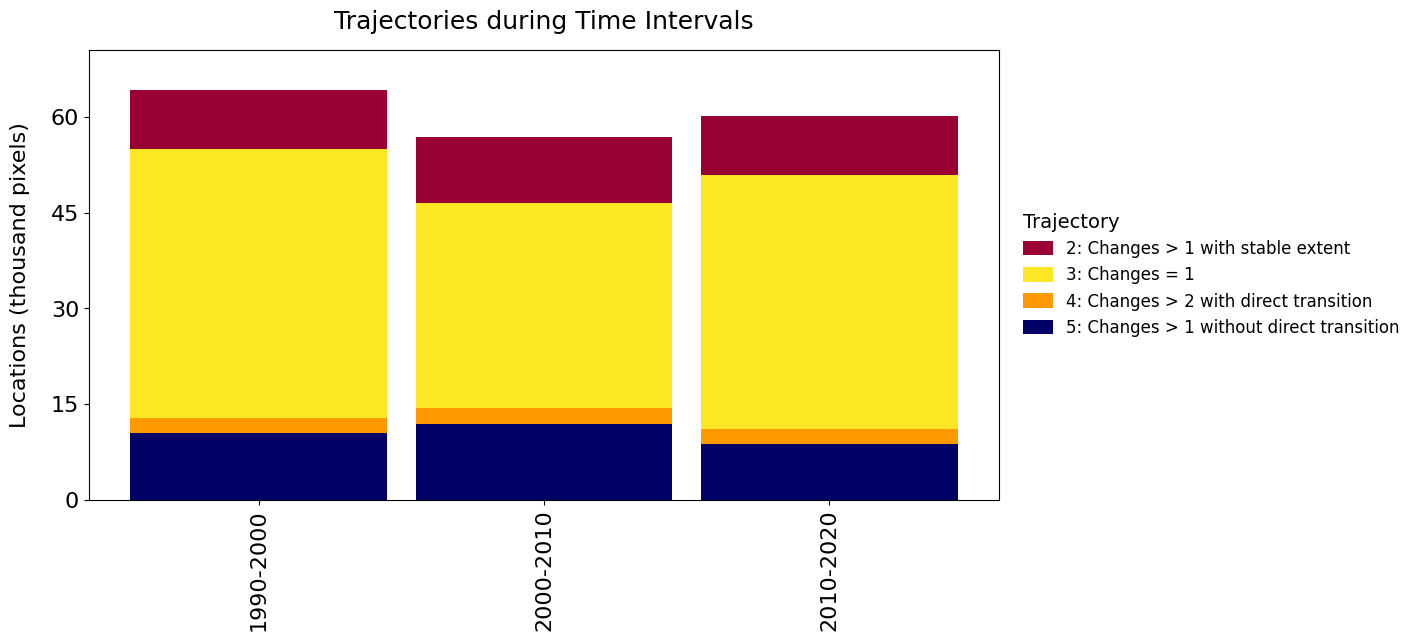

Figure saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_trajectory_time_interval.png


In [ ]:
# @title 6.3 Plot trajectories during time intervals
def plot_trajectory_contributions(
    df: pd.DataFrame,
    output_path: str,
) -> None:
    """
    Create stacked bar chart for trajectory contributions per interval.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with intervals as index and trajectory IDs (2, 3, 4, 5) as columns.
    output_path : str
        Path to output directory for saving figure.
    """
    import matplotlib.ticker as mticker
    # 0. Ensure columns are integers to match logic
    df = df.copy()
    df.columns = df.columns.astype(
        int,
    )

    # 1. Calculate the maximum value to determine scale factor
    max_val = df.sum(
        axis=1,
    ).max()

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Locations{suffix}"

    # Apply scaling
    df_scaled = (
        df / scale_factor
    )

    # 2. Define colors and stacking order
    colors = {
        2: "#990033",
        3: "#FDE725",
        4: "#ff9900",
        5: "#000066"
    }


    # Stacking order: 4 (bottom), 3 (middle), 2 (top)
    stack_order = [
        5,
        4,
        3,
        2,
    ]

    # 3. Create figure and axis
    fig, ax = plt.subplots(
        figsize=(
            14,
            6,
        ),
    )

    # 4. Plot stacked bars
    bottom = pd.Series(
        0.0,
        index=df_scaled.index,
    )

    for traj_id in stack_order:
        if traj_id in df_scaled.columns:
            values = df_scaled[
                traj_id
            ]
            ax.bar(
                df_scaled.index,
                values,
                label=f"{traj_id}",
                bottom=bottom,
                color=colors[
                    traj_id
                ],
                edgecolor="none",
                width=0.9,
            )
            bottom += values

    # 5. Customize axes and labels
    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15,
    )
    ax.set_title(
        "Trajectories during Time Intervals",
        fontsize=18,
        pad=15
    )

    # X-Axis formatting: Horizontal labels
    ax.tick_params(
        axis="x",
        labelsize=16,
        rotation=90,
    )

    # Y-Axis formatting
    ax.tick_params(
        axis="y",
        labelsize=16,
    )

    # Dynamically set y-axis limits and ticks
    max_y = df_scaled.sum(
        axis=1
    ).max()
    ax.set_ylim(
        0,
        max_y * 1.1 if max_y > 0 else 1.0
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=6
        )
    )

    # Spines visible, NO GRID
    for spine in [
        "top",
        "right",
        "left",
        "bottom",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )

    # 6. Legend
    handles, labels = ax.get_legend_handles_labels()

    if handles:
        # Reorder handles to match 2, 3, 4, 5
        legend_order_map = {
            "2": 0,
            "3": 1,
            "4": 2,
            "5": 3,
        }
        new_labels_map = {
            "2": "2: Changes > 1 with stable extent",
            "3": "3: Changes = 1",
            "4": "4: Changes > 2 with direct transition",
            "5": "5: Changes > 1 without direct transition",
        }

        # Sort handles based on labels
        sorted_pairs = sorted(
            zip(
                handles,
                labels,
            ),
            key=lambda x: legend_order_map.get(
                x[
                    1
                ],
                99,
            ),
        )
        sorted_handles, sorted_labels = zip(
            *sorted_pairs,
        )

        sorted_labels = [
            new_labels_map.get(l, l)
            for l in sorted_labels
        ]

        ax.legend(
            sorted_handles,
            sorted_labels,
            loc="center left",
            bbox_to_anchor=(
                1.01,
                0.5,
            ),
            title="Trajectory",
            title_fontsize=14,
            alignment="left",
            fontsize=12,
            frameon=False,
            handlelength=1.8,
            handleheight=1.0,
            labelspacing=0.5,
            handletextpad=0.8
        )

    # Force main plotting box spatial coordinates to match other interval charts
    fig.subplots_adjust(
        left=0.1,
        right=0.75,
        bottom=0.15,
        top=0.9,
    )

    # 7. Save figure
    charts_dir = os.path.join(
        output_path,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    output_fig = os.path.join(
        charts_dir,
        "chart_trajectory_time_interval.png",
    )
    plt.savefig(
        output_fig,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()

    print(
        f"Figure saved to: {output_fig}",
    )

# Execution
# 1. Load the CSV explicitly from the 'tables' folder
csv_path = os.path.join(
    output_path,
    "tables",
    "trajectory_contributions_per_interval.csv",
)
df_trajectory_intervals = pd.read_csv(
    csv_path,
    index_col="Interval",
)

# 2. Execute the visualization
plot_trajectory_contributions(
    df=df_trajectory_intervals,
    output_path=output_path,
)


In [ ]:
# @title 6.4 Compute trajectory overall (default)
def compute_total_changes_per_trajectory(
    output_dir: str,
) -> pd.DataFrame:
    """
    Sum the number of changes per trajectory across all time intervals
    using the CSV generated in section 5.2.

    Parameters
    ----------
    output_dir : str
        The base output directory where the 'tables' subfolder is located.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the total changes per trajectory class.
    """
    # 1. Define the input CSV path
    csv_path = os.path.join(
        output_dir,
        "tables",
        "trajectory_contributions_per_interval.csv",
    )

    # 2. Check if the CSV exists
    if not os.path.exists(
        csv_path,
    ):
        print(
            f"Error: CSV not found at {csv_path}. Please run section 5.2 first.",
        )
        return None

    # 3. Read the CSV generated in 5.2
    df_intervals = pd.read_csv(
        csv_path,
        index_col="Interval",
    )

    # 4. Sum across all intervals (summing each column)
    total_changes = df_intervals.sum(
        axis=0,
    )

    # 5. Convert to DataFrame for a clean display and saving
    df_total = pd.DataFrame(
        total_changes,
        columns=[
            "Total_Changes",
        ],
    )
    df_total.index.name = "Trajectory_Class"

    # 6. Save to a new CSV
    out_csv = os.path.join(
        output_dir,
        "tables",
        "trajectory_total_changes.csv",
    )

    df_total.to_csv(
        out_csv,
    )

    print(
        f"CSV file saved to: {out_csv}\n",
    )

    return df_total

# 7. Execute the function
df_traj_total_changes = compute_total_changes_per_trajectory(
    output_dir=output_path,
)

if df_traj_total_changes is not None:
    display(
        df_traj_total_changes,
    )

CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/trajectory_total_changes.csv



,Total_Changes
Trajectory_Class,
2,28835
3,114079
4,7146
5,31123


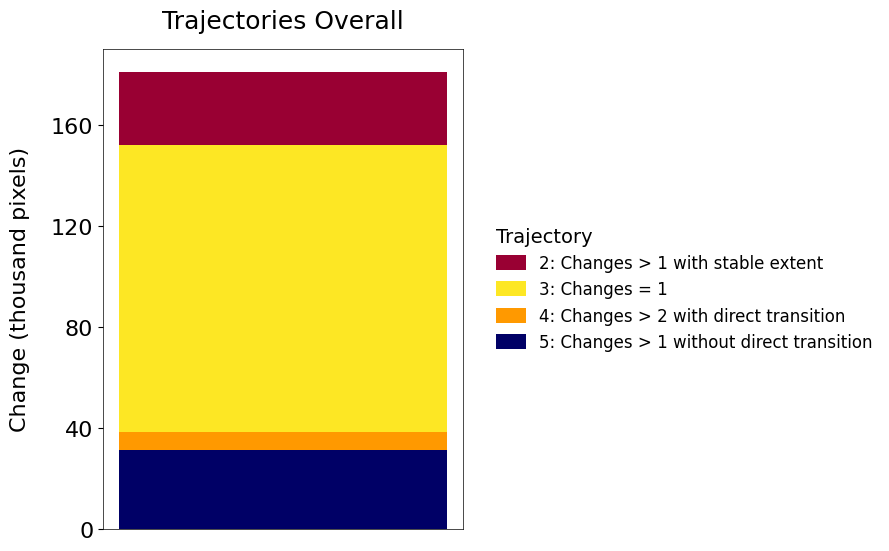

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_trajectory_overall_default.png


In [ ]:
# @title 6.5 Plot trajectory overall (default)

def plot_trajectory_overall_from_csv(
    output_dir: str,
) -> None:
    """
    Read the summary CSV for overall trajectory changes and plot it as a stacked bar chart
    using the standard layout and dynamic Y-axis ticks.

    Parameters
    ----------
    output_dir : str
        The base output directory where the 'tables' subfolder is located.

    Returns
    -------
    None
    """
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    csv_input_path = os.path.join(
        tables_dir,
        "trajectory_total_changes.csv",
    )

    if not os.path.exists(
        csv_input_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_input_path}.",
        )
        return

    # Load the summary CSV
    df = pd.read_csv(
        csv_input_path,
        index_col="Trajectory_Class",
    )

    colors = {
        5: "#000066",
        4: "#ff9900",
        3: "#FDE724",
        2: "#990033",
        1: "#d9d9d9",
    }

    # Stacking order (bottom to top)
    stack_order = [
        5,
        4,
        3,
        2,
        1,
    ]

    # Create the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            6,
        ),
    )

    bottom = 0.0
    active_trajs = []

    for traj in stack_order:
        if traj in df.index:
            val = df.loc[
                traj,
                "Total_Changes",
            ]
            if val > 0:
                ax.bar(
                    0,
                    val,
                    bottom=bottom,
                    color=colors.get(
                        traj,
                        "gray",
                    ),
                    width=0.4,
                    edgecolor="none",
                )
                bottom += val
                active_trajs.append(
                    traj,
                )

    # Formatting the Axes
    max_val = bottom

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Change{suffix}"

    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15,
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, pos: f"{x / scale_factor:g}",
        )
    )

    ax.set_title(
        "Trajectories Overall",
        fontsize=18,
        pad=15,
    )

    for spine in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )
        ax.spines[
            spine
        ].set_color(
            "black",
        )
        ax.spines[
            spine
        ].set_linewidth(
            0.5,
        )

    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )
    ax.set_xticks(
        [],
    )

    # ----- Y-Axis Dynamic Scaling Logic -----
    max_y_unscaled = bottom
    max_ylim = max_y_unscaled * 1.05 if max_y_unscaled > 0 else 1.0
    ax.set_ylim(
        0,
        max_ylim,
    )

    # By adding + 2 to the bins when value is small, we ensure MaxNLocator has enough room
    # to use step=1 instead of rounding up to step=2 for values like 15
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=max(6, int(max_ylim) + 2) if max_ylim < 20 else 6
        )
    )
    # ----------------------------------------

    # Legend
    legend_labels_map = {
        1: "1: Changes = 0",
        2: "2: Changes > 1 with stable extent",
        3: "3: Changes = 1",
        4: "4: Changes > 2 with direct transition",
        5: "5: Changes > 1 without direct transition",
    }

    legend_elements = [
        Patch(
            facecolor=colors[n],
            label=legend_labels_map.get(n, str(n)),
        )
        for n in sorted(
            active_trajs,
        )
    ]

    ax.legend(
        handles=legend_elements,
        title="Trajectory",
        title_fontsize=14,
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        fontsize=12,
        alignment="left",
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force main plotting box spatial coordinates
    fig.subplots_adjust(
        left=0.15,
        right=0.75,
        bottom=0.1,
        top=0.9,
    )

    # Save and show
    charts_dir = os.path.join(
        output_dir,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )
    out_fig_path = os.path.join(
        charts_dir,
        "chart_trajectory_overall_default.png",
    )

    plt.savefig(
        out_fig_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()
    print(
        f"Chart saved to: {out_fig_path}",
    )

# Execute function
plot_trajectory_overall_from_csv(
    output_dir=output_path,
)


### 6.6 Optional trajectory overall

#### 6.6.2 Percentage of study area

In [ ]:
# @title 6.6.2.1 Compute the percentage of the study area with trajectories
def compute_trajectory_percentage_csv(
    output_path: str,
) -> pd.DataFrame:
    """
    Calculate the percentage of the study area for trajectory classes 2, 3, 4,
    and 5 using chunk-based processing to avoid memory overload, and save
    the results to a CSV file.

    Parameters
    ----------
    output_path : str
        Directory path where the 'rasters' folder with 'trajectory.tif' is located,
        and where the output CSV will be saved in the 'tables' folder.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the trajectory classes and their corresponding percentages.
    """
    raster_path = os.path.join(
        output_path,
        "rasters",
        "trajectory.tif",
    )

    if not os.path.exists(
        raster_path,
    ):
        print(
            f"Error: Raster not found at {raster_path}.",
        )
        return None

    data_counts = {}
    total_pixels = 0

    with rasterio.open(
        raster_path,
    ) as src:
        nodata = src.nodata
        windows = [window for ij, window in src.block_windows()]

        if not windows:
            for idx in range(0, src.height, 256):
                height = min(256, src.height - idx)
                windows.append(rasterio.windows.Window(0, idx, src.width, height))

        for window in tqdm(
            windows,
            desc="Processing trajectory chunks",
        ):
            chunk = src.read(1, window=window)

            if nodata is not None:
                valid_pixels = chunk[chunk != nodata]
            else:
                valid_pixels = chunk

            unique_vals, counts = np.unique(
                valid_pixels,
                return_counts=True,
            )

            for val, count in zip(unique_vals, counts):
                data_counts[val] = data_counts.get(val, 0) + count
                total_pixels += count

    records = []
    for traj_class in [
        2,
        3,
        4,
        5,
    ]:
        pixels = data_counts.get(
            traj_class,
            0,
        )
        pct = float(
            (pixels / total_pixels) * 100.0
        ) if total_pixels > 0 else 0.0

        records.append(
            {
                "Trajectory": traj_class,
                "Percentage": pct,
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # Save to CSV
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "trajectory_distribution_percentage.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )

    return df_dist

# Execution
df_trajectory_percentage = compute_trajectory_percentage_csv(
    output_path=output_path,
)

if df_trajectory_percentage is not None:
    display(
        df_trajectory_percentage,
    )


Processing trajectory chunks: 100%|██████████| 740/740 [00:00<00:00, 3890.86it/s]


CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/trajectory_distribution_percentage.csv


,Trajectory,Percentage
0,2,0.336662
1,3,2.695162
2,4,0.056276
3,5,0.364942


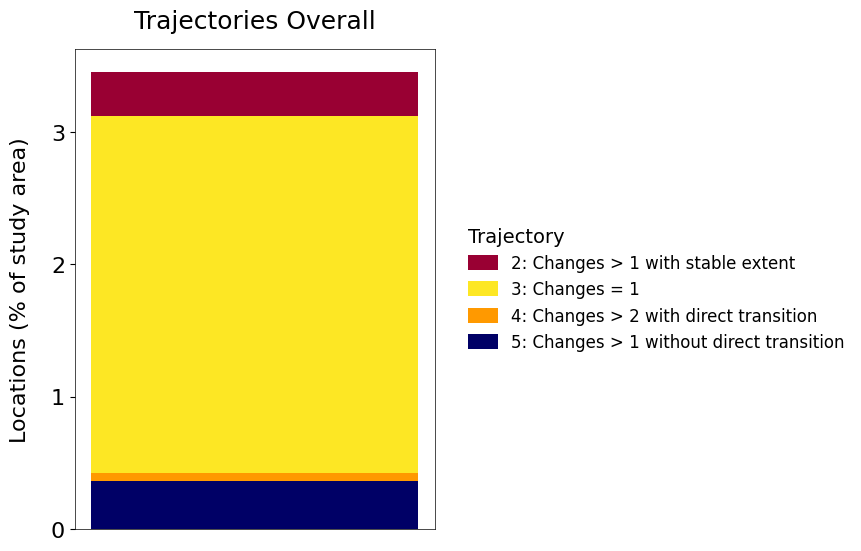

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_trajectory_percentage_overall.png


In [ ]:
# @title 6.6.2.2 Plot the percentage of the study area with trajectories
def plot_trajectory_percentage_overall(
    output_path: str,
) -> None:
    """
    Generate and save a stacked bar chart of trajectory class distributions
    by reading the previously saved CSV.

    Parameters
    ----------
    output_path : str
        Directory path containing the input 'trajectory.tif' raster.
        The output image 'graphic_trajectory_percentage_overall.png' will also
        be saved here.

    Returns
    -------
    None
        The function saves the plot to disk and displays it.
    """
    # 1. Read the CSV file
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    csv_path = os.path.join(
        tables_dir,
        "trajectory_distribution_percentage.csv",
    )

    if not os.path.exists(
        csv_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_path}."
        )
        return

    df_dist = pd.read_csv(
        csv_path,
    )

    # 2. Extract percentages
    percentages = dict(
        zip(
            df_dist[
                "Trajectory"
            ],
            df_dist[
                "Percentage"
            ],
        )
    )

    ordered_trajs = [
        5,
        4,
        3,
        2,
    ]
    colors = {
        5: "#000066", # Dark Blue
        4: "#ff9900", # Orange
        3: "#FDE724", # Yellow
        2: "#990033", # Dark Red
    }

    fig, ax = plt.subplots(
        figsize=(
            6,
            6,
        ),
    )

    bottom = 0.0
    for traj in ordered_trajs:
        val = percentages.get(
            traj,
            0,
        )
        ax.bar(
            0,
            val,
            bottom=bottom,
            color=colors[
                traj
            ],
            width=0.4,
            edgecolor="none",
        )
        bottom += val

    ax.set_ylabel(
        "Locations (% of study area)",
        fontsize=16,
        labelpad=15,
    )

    ax.set_title(
        "Trajectories Overall",
        fontsize=18,
        pad=15,
    )

    for spine in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )
        ax.spines[
            spine
        ].set_color(
            "black",
        )
        ax.spines[
            spine
        ].set_linewidth(
            0.5,
        )

    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )

    # Remove x-axis ticks to leave it blank
    ax.set_xticks(
        [],
    )

    ax.set_ylim(
        0,
        bottom * 1.05,
    )

    # Use mticker for consistency
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,  # Force integer ticks
            nbins=10,
        ),
    )
    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter(
            "%g",
        ),
    )

    # Legend with detailed descriptions
    legend_elements = [
        Patch(
            facecolor=colors[2],
            label="2: Changes > 1 with stable extent",
        ),
        Patch(
            facecolor=colors[3],
            label="3: Changes = 1",
        ),
        Patch(
            facecolor=colors[4],
            label="4: Changes > 2 with direct transition",
        ),
        Patch(
            facecolor=colors[5],
            label="5: Changes > 1 without direct transition",
        ),
    ]

    ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        title="Trajectory",
        title_fontsize=14,
        alignment="left",
        fontsize=12,
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force the main plotting box to always occupy the exact same spatial coordinates in the figure
    fig.subplots_adjust(
        left=0.15,
        right=0.75,
        bottom=0.1,
        top=0.9
    )

    # Save the figure
    charts_dir = os.path.join(
        output_path,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    out_fig_path = os.path.join(
        charts_dir,
        "chart_trajectory_percentage_overall.png",
    )
    plt.savefig(
        out_fig_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()

    print(
        f"Chart saved to: {out_fig_path}",
    )

# Execution
plot_trajectory_percentage_overall(
    output_path=output_path,
)


#### 6.6.3 Location of trajectories

In [ ]:
# @title 6.6.3.1 Compute location of trajectories
def compute_trajectory_location_csv(
    output_path: str,
) -> pd.DataFrame:
    """
    Calculate the total number of pixels for trajectory classes 2, 3, 4,
    and 5 using chunk-based processing to avoid memory overload, and save
    the results to a CSV file.

    Parameters
    ----------
    output_path : str
        Directory path where the 'rasters' folder with 'trajectory.tif' is located,
        and where the output CSV will be saved in the 'tables' folder.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the total pixels for each trajectory class.
    """
    raster_path = os.path.join(
        output_path,
        "rasters",
        "trajectory.tif",
    )

    if not os.path.exists(
        raster_path,
    ):
        print(
            f"Error: Raster not found at {raster_path}.",
        )
        return None

    data_counts = {}

    with rasterio.open(
        raster_path,
    ) as src:
        nodata = src.nodata
        windows = [
            window for ij, window in src.block_windows()
        ]

        if not windows:
            for idx in range(
                0,
                src.height,
                256,
            ):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

        for window in tqdm(
            windows,
            desc="Processing trajectory chunks",
        ):
            chunk = src.read(
                1,
                window=window,
            )

            if nodata is not None:
                valid_pixels = chunk[
                    chunk != nodata
                ]
            else:
                valid_pixels = chunk

            unique_vals, counts = np.unique(
                valid_pixels,
                return_counts=True,
            )

            for val, count in zip(
                unique_vals,
                counts,
            ):
                data_counts[
                    val
                ] = data_counts.get(
                    val,
                    0,
                ) + count

    records = []
    for traj_class in [
        2,
        3,
        4,
        5,
    ]:
        pixels = data_counts.get(
            traj_class,
            0,
        )

        records.append(
            {
                "Trajectory": traj_class,
                "Pixels": pixels,
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # Save to CSV
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "trajectory_distribution_location.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )

    return df_dist

# Execution
df_trajectory_location = compute_trajectory_location_csv(
    output_path=output_path,
)

if df_trajectory_location is not None:
    display(
        df_trajectory_location,
    )


Processing trajectory chunks: 100%|██████████| 740/740 [00:00<00:00, 3376.22it/s]

CSV file saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/trajectory_distribution_location.csv


,Trajectory,Pixels
0,2,14250
1,3,114079
2,4,2382
3,5,15447


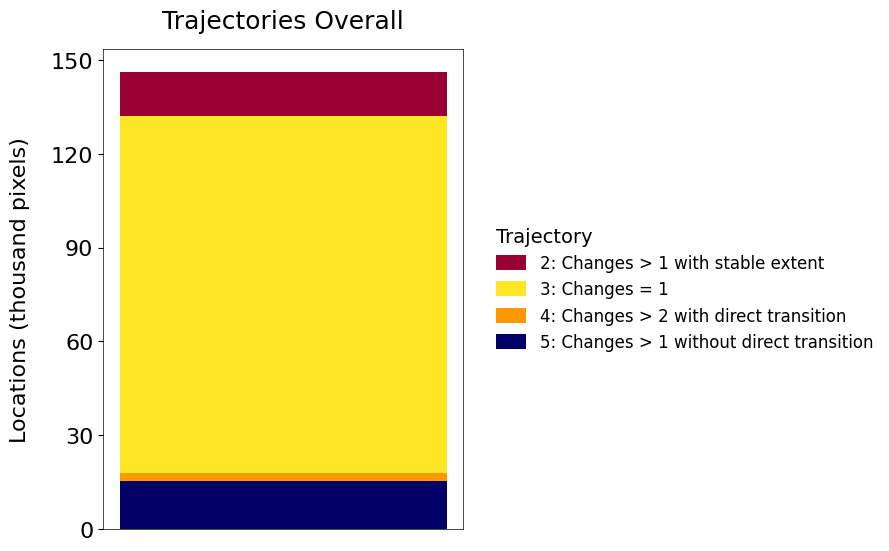

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_trajectory_location_overall.png


In [ ]:
# @title 6.6.3.2 Plot location of trajectories
def plot_trajectory_location_overall(
    output_path: str,
) -> None:
    """
    Generate and save a stacked bar chart of trajectory class distributions
    by reading the previously saved CSV.

    Parameters
    ----------
    output_path : str
        Directory path containing the input 'trajectory.tif' raster.
        The output image 'graphic_trajectory_location_overall.png' will also
        be saved here.

    Returns
    -------
    None
        The function saves the plot to disk and displays it.
    """
    # 1. Read the CSV file
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    csv_path = os.path.join(
        tables_dir,
        "trajectory_distribution_location.csv",
    )

    if not os.path.exists(
        csv_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_path}.",
        )
        return

    df_dist = pd.read_csv(
        csv_path,
    )

    # 2. Extract pixel counts
    pixel_counts = dict(
        zip(
            df_dist[
                "Trajectory"
            ],
            df_dist[
                "Pixels"
            ],
        )
    )

    ordered_trajs = [
        5,
        4,
        3,
        2,
    ]
    colors = {
        5: "#000066", # Dark Blue
        4: "#ff9900", # Orange
        3: "#FDE724", # Yellow
        2: "#990033", # Dark Red
    }

    fig, ax = plt.subplots(
        figsize=(
            6,
            6,
        ),
    )

    bottom = 0.0
    for traj in ordered_trajs:
        val = pixel_counts.get(
            traj,
            0,
        )
        ax.bar(
            0,
            val,
            bottom=bottom,
            color=colors[
                traj
            ],
            width=0.4,
            edgecolor="none",
        )
        bottom += val

    max_val = bottom

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Locations{suffix}"

    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15,
    )

    ax.set_title(
        "Trajectories Overall",
        fontsize=18,
        pad=15,
    )

    for spine in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )
        ax.spines[
            spine
        ].set_color(
            "black",
        )
        ax.spines[
            spine
        ].set_linewidth(
            0.5,
        )

    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16,
    )

    # Remove x-axis ticks to leave it blank
    ax.set_xticks(
        [],
    )

    max_y = bottom * 1.05 if bottom > 0 else 1.0
    ax.set_ylim(
        0,
        max_y,
    )

    # Use mticker for consistency
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=max(6, int(max_y) + 2) if max_y < 20 else 6,
        ),
    )
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, pos: f"{x / scale_factor:g}",
        ),
    )

    # Legend with detailed descriptions
    legend_elements = [
        Patch(
            facecolor=colors[2],
            label="2: Changes > 1 with stable extent",
        ),
        Patch(
            facecolor=colors[3],
            label="3: Changes = 1",
        ),
        Patch(
            facecolor=colors[4],
            label="4: Changes > 2 with direct transition",
        ),
        Patch(
            facecolor=colors[5],
            label="5: Changes > 1 without direct transition",
        ),
    ]

    ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(
            1.05,
            0.5,
        ),
        title="Trajectory",
        title_fontsize=14,
        alignment="left",
        fontsize=12,
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force the main plotting box to always occupy the exact same spatial coordinates in the figure
    fig.subplots_adjust(
        left=0.15,
        right=0.75,
        bottom=0.1,
        top=0.9
    )

    # Save the figure
    charts_dir = os.path.join(
        output_path,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    out_fig_path = os.path.join(
        charts_dir,
        "chart_trajectory_location_overall.png",
    )
    plt.savefig(
        out_fig_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()

    print(
        f"Chart saved to: {out_fig_path}",
    )

# Execution
plot_trajectory_location_overall(
    output_path=output_path,
)


### 6.5 Plot trajectory map

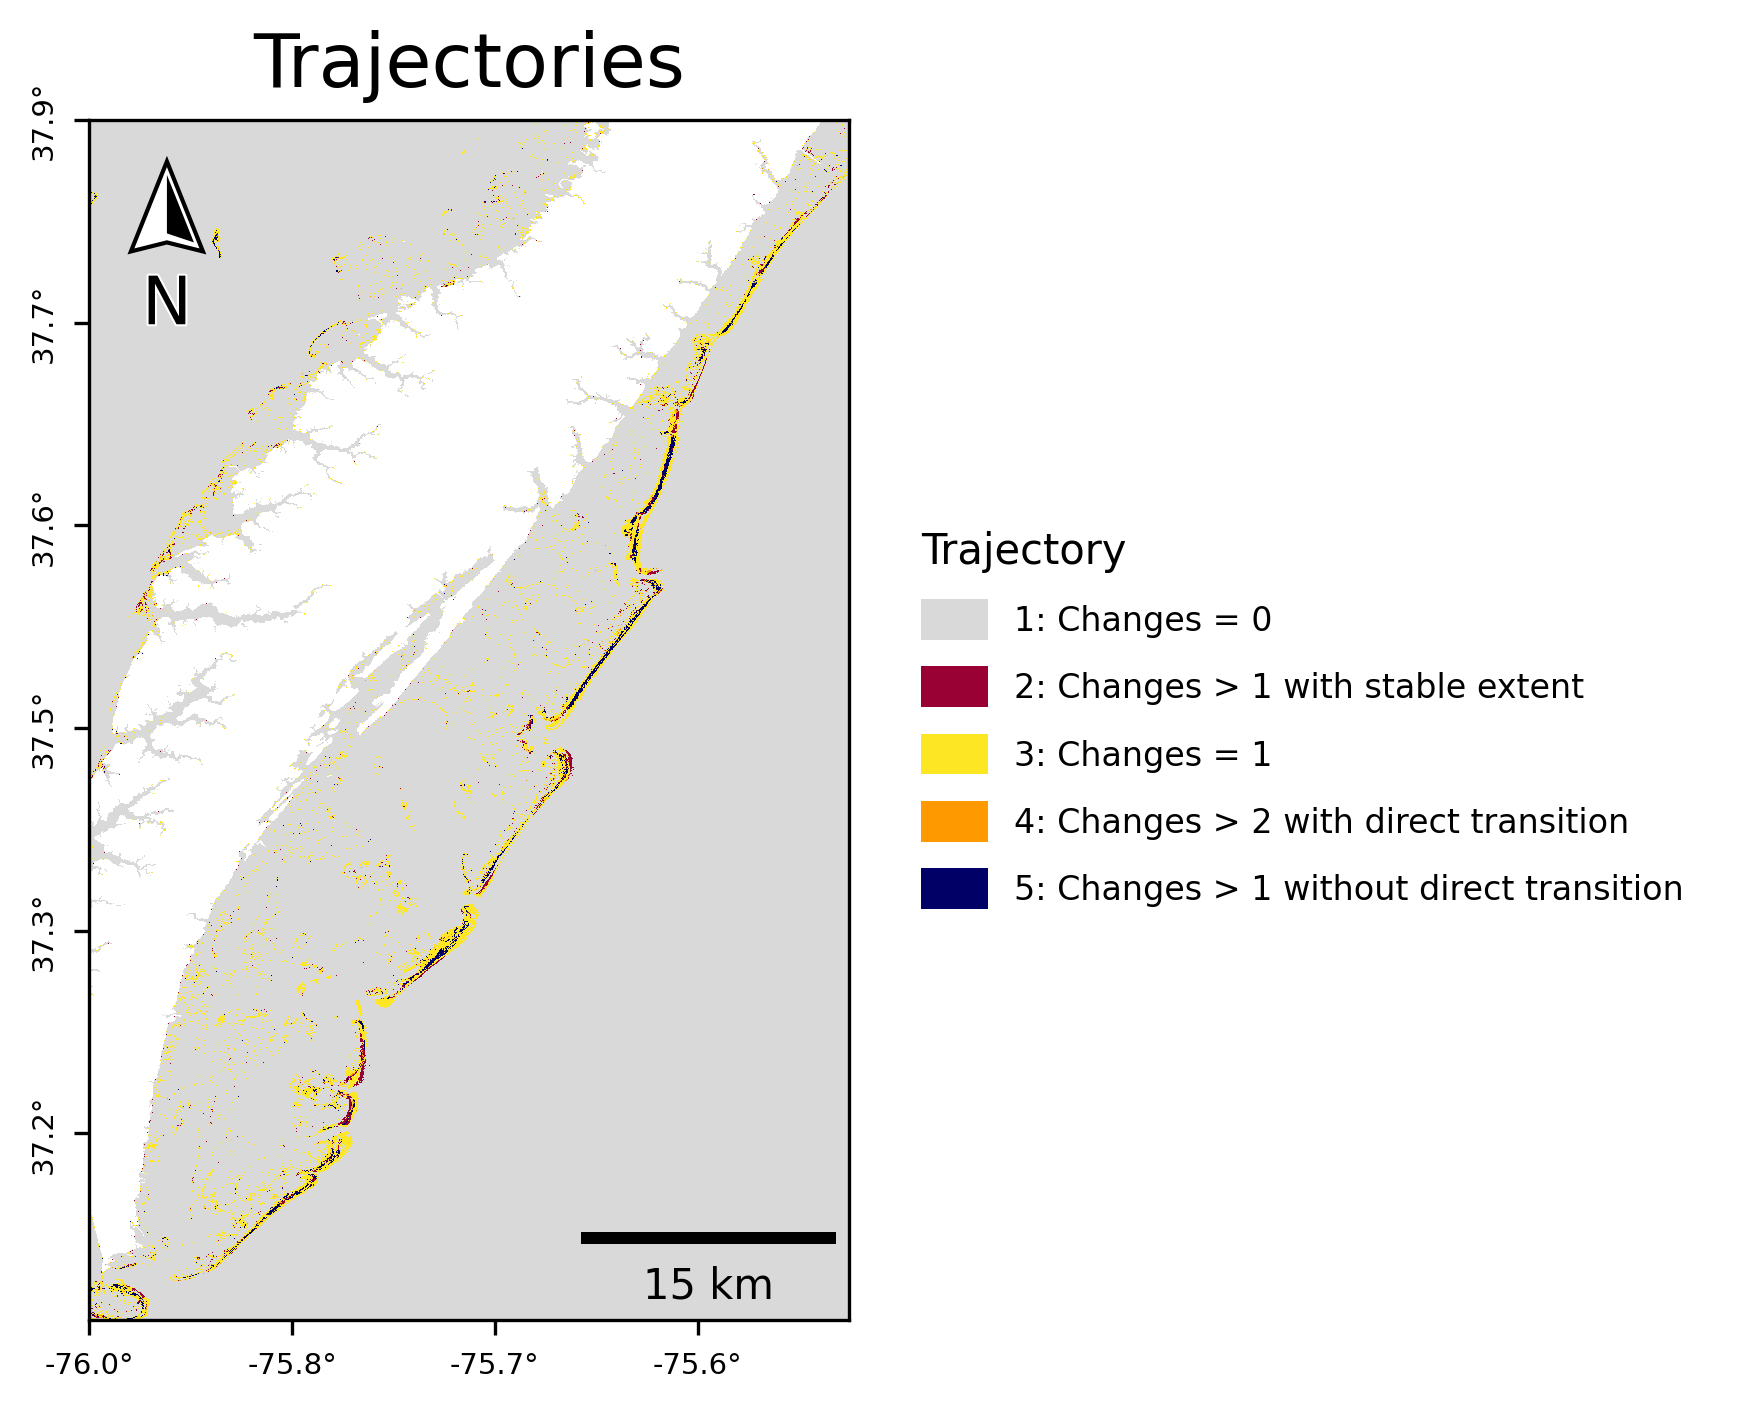

Map figure saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/maps/map_trajectories.png


In [ ]:
def plot_trajectory_map(
    output_dir: str,
    raster_filename: str = "trajectory.tif",
) -> None:
    """
    Plot the Trajectory raster map with specific categorical coloring and new legend descriptions.

    Parameters
    ----------
    output_dir : str
        Directory containing the raster file and where the map will be saved.
    raster_filename : str, optional
        Name of the raster file to plot (default is "trajectory.tif").

    Returns
    -------
    None
        This function does not return a value; it saves a PNG file to disk
        and displays the plot.

    Raises
    ------
    FileNotFoundError
        If the specified raster file does not exist in the output directory.
    """

    # 1) Input raster path
    raster_path = os.path.join(
        output_dir,
        "rasters",
        raster_filename,
    )

    if not os.path.exists(
        raster_path,
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}",
        )

    pixel_size_km = compute_display_pixel_size_km(
        raster_path=raster_path,
        downsample_divisor=1,
    )

    # 2) Read raster and basic metadata
    with rasterio.open(
        raster_path,
    ) as src:
        scale_factor = 1

        data = src.read(
            1,
            out_shape=(
                int(
                    src.height * scale_factor,
                ),
                int(
                    src.width * scale_factor,
                ),
            ),
            resampling=rasterio.enums.Resampling.nearest,
        )

        nodata_val = src.nodata
        if nodata_val is not None:
             data = np.ma.masked_equal(
                 data,
                 nodata_val,
             )

        left, bottom, right, top = src.bounds
        src_crs = src.crs
        transform = src.transform

    # 3) Figure (Fixed size for identical map areas)
    fig, ax = plt.subplots(
        figsize=(10, 5),
        dpi=300,
    )

    # Fix the map bounding box to exact coordinates inside the figure
    fig.subplots_adjust(
        left=0.1,
        right=0.7,
        top=0.9,
        bottom=0.1
    )

    # 4) Colormap
    cmap = ListedColormap(
        [
            "#d9d9d9",  # Trajectory 1
            "#990033",  # Trajectory 2
            "#FDE725",  # Trajectory 3
            "#ff9900",  # Trajectory 4
            "#000066",  # Trajectory 5
        ],
    )
    bounds = [
        0.5,
        1.5,
        2.5,
        3.5,
        4.5,
        5.5,
    ]
    norm = BoundaryNorm(
        bounds,
        cmap.N,
    )

    # 5) Plot raster in original projection coordinates
    ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    # 6) Legend (Updated as requested with colons)
    legend_elements = [
        Patch(
            facecolor="#d9d9d9",
            label="1: Changes = 0",
            edgecolor="black",
            linewidth=0,
        ),
        Patch(
            facecolor="#990033",
            label="2: Changes > 1 with stable extent",
            edgecolor="black",
            linewidth=0,
        ),
        Patch(
            facecolor="#FDE725",
            label="3: Changes = 1",
            edgecolor="black",
            linewidth=0,
        ),
        Patch(
            facecolor="#ff9900",
            label="4: Changes > 2 with direct transition",
            edgecolor="black",
            linewidth=0,
        ),
        Patch(
            facecolor="#000066",
            label="5: Changes > 1 without direct transition",
            edgecolor="black",
            linewidth=0,
        ),
    ]

    ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(
            1.02,
            0.5,
        ),
        frameon=False,
        fontsize=8,
        borderpad=1.2,
        title="Trajectory",
        title_fontsize=10,
        alignment="left",
        handletextpad=0.8,
        columnspacing=2,
        labelspacing=0.8,
        handlelength=2.0,
        handleheight=1.5,
    )

    # 7) Cartographic elements
    scalebar = ScaleBar(
        dx=pixel_size_km,
        units="km",
        length_fraction=0.35,
        location="lower right",
        box_alpha=0.0,
        scale_formatter=lambda value, _: f"{int(value)} km",
    )
    ax.add_artist(
        scalebar,
    )

    north_arrow(
        ax,
        location="upper left",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3,
    )

    # 8) Axes styling (with Lat/Lon labels)
    ax.set_title(
        "Trajectories",
        fontsize=18,
        pad=8,
    )
    ax.set_aspect(
        "equal",
    )

    # Initialize Transformer (Native CRS -> Lat/Lon)
    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )

    # Get dimensions from the loaded data
    height, width = data.shape

    def format_lon(
        x,
        pos,
    ):
        """
        Convert a pixel column index to a formatted Longitude string.

        Parameters
        ----------
        x : float
            The pixel column index (x-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The longitude coordinate formatted as a string.
        """
        # Clamp x to be within image bounds
        x = np.clip(
            x,
            0,
            width - 1,
        )
        # Project pixel to map coordinates (using middle of height)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            height // 2,
            x,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lon:.1f}°"

    def format_lat(
        y,
        pos,
    ):
        """
        Convert a pixel row index to a formatted Latitude string.

        Parameters
        ----------
        y : float
            The pixel row index (y-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The latitude coordinate formatted as a string.
        """
        # Clamp y to be within image bounds
        y = np.clip(
            y,
            0,
            height - 1,
        )
        # Project pixel to map coordinates (using middle of width)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            y,
            width // 2,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lat:.1f}°"

    # Apply the custom formatters
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            format_lon,
        ),
    )
    ax.yaxis.set_major_formatter(
        FuncFormatter(
            format_lat,
        ),
    )

    # Limit ticks to avoid overcrowding
    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=4,
        ),
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=6,
        ),
    )

    # Final styling for ticks
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        pad=4,
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=90,
        va="center",
    )

    # 9) Save (REMOVED bbox_inches="tight" to maintain identical dimensions)
    maps_dir = os.path.join(
        output_dir,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    output_figure_path = os.path.join(
        maps_dir,
        "map_trajectories.png",
    )

    plt.savefig(
        output_figure_path,
        format="png",
        dpi=300,
        pad_inches=0.05,
    )
    plt.show()

    print(
        f"Map figure saved to: {output_figure_path}",
    )


# Execute the function
plot_trajectory_map(
    output_dir=output_path,
)


## **7. Change Components**

This section performs the core spatial-temporal analysis by first processing multi-year rasters into a consistent valid pixel mask. It executes a dual-track transition analysis to compute individual interval matrices for step-by-step changes while simultaneously deriving change components.

The process generates the following transition matrices:

1. *transition_matrix_time_intervals*: The total sum of all transitions across all time intervals.

2. *transition_matrix_extent*: The end-to-end transition matrix from the first to the last time point.

3. *transition_matrix_allocation_exchange*: Spatial swaps derived from the extent matrix.

4. *transition_matrix_allocation_shift*: Spatial displacement derived from the extent matrix.

5. *transition_matrix_alternation_exchange*: Temporal swaps captured at the pixel-level trajectories.

6. *transition_matrix_alternation_shift*: Temporal displacement captured at the pixel-level trajectories.

7. *transition_matrix_indirect_extent*: Extent change representing indirect transitions.

8. *transition_matrix_indirect_ratio*: The ratio of indirect transitions relative to the overall extent change.

In [ ]:
# @title 7.1 Compute time intervals transition matrix

@nb.njit(nogil=True)
def compute_interval_matrices_chunk(
    stack: np.ndarray,
    nodata: int,
    class_to_idx: np.ndarray,
    num_classes: int,
) -> np.ndarray:
    """
    Calculate interval transition matrices for a chunk of raster data.

    Parameters
    ----------
    stack : np.ndarray
        3D array of shape (time, height, width) with pixel values.
    nodata : int
        Value representing NoData.
    class_to_idx : np.ndarray
        1D array mapping class values to matrix indices.
    num_classes : int
        Total number of valid classes.

    Returns
    -------
    np.ndarray
        3D array of shape (n_intervals, num_classes, num_classes)
        containing the accumulated transition counts.
    """
    # 1. Extract dimensions
    n_times = stack.shape[0]
    h = stack.shape[1]
    w = stack.shape[2]
    n_intervals = n_times - 1

    # 2. Initialize output matrices
    out_matrices = np.zeros(
        (
            n_intervals,
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )

    # 3. Iterate over spatial dimensions
    for y in range(h):
        for x in range(w):
            # 4. Check for NoData across the pixel's trajectory
            has_nodata = False
            for t in range(n_times):
                if stack[t, y, x] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            # 5. Accumulate transitions for valid pixels
            for t in range(n_intervals):
                val_s = stack[t, y, x]
                val_e = stack[t + 1, y, x]

                idx_s = class_to_idx[val_s]
                idx_e = class_to_idx[val_e]

                if idx_s >= 0 and idx_e >= 0:
                    out_matrices[
                        t,
                        idx_s,
                        idx_e,
                    ] += 1

    return out_matrices


def generate_interval_transition_matrices_chunked(
    image_paths: list,
    output_dir: str,
    years: list,
    class_dict: dict,
    nodata_val: int,
) -> tuple:
    """
    Generate and save time interval transition matrices using chunked processing.

    Parameters
    ----------
    image_paths : list
        List of file paths to the input raster images.
    output_dir : str
        Path to the output directory where tables will be saved.
    years : list
        List of years representing the time points.
    class_dict : dict
        Dictionary mapping class IDs to their names and colors.
    nodata_val : int
        Value representing NoData.

    Returns
    -------
    tuple
        A tuple containing:
        - dict: Saved dataframes mapping interval strings to pd.DataFrame.
        - list: Sorted list of valid class IDs.
    """
    # 1. Extract class information and initialize mapping array
    class_ids = sorted(class_dict.keys())
    num_classes = len(class_ids)
    max_id = max(class_ids) if class_ids else 255

    class_to_idx_arr = np.full(
        max_id + 1,
        -1,
        dtype=np.int64,
    )
    for idx, cid in enumerate(class_ids):
        class_to_idx_arr[cid] = idx

    # 2. Read windows/chunks from the first raster
    with rasterio.open(image_paths[0]) as src:
        windows = [window for ij, window in src.block_windows()]
        if not windows:
            windows = []
            for idx in range(0, src.height, 256):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

    # 3. Initialize global matrices
    n_intervals = len(years) - 1
    global_matrices = np.zeros(
        (
            n_intervals,
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )

    # 4. Process each chunk
    for window in tqdm(
        windows,
        desc="Processing chunks for interval matrices",
    ):
        stack_list = []
        for path in image_paths:
            with rasterio.open(path) as src:
                stack_list.append(
                    src.read(
                        1,
                        window=window,
                    )
                )

        stack = np.array(
            stack_list,
            dtype=np.uint8,
        )

        chunk_matrices = compute_interval_matrices_chunk(
            stack=stack,
            nodata=nodata_val,
            class_to_idx=class_to_idx_arr,
            num_classes=num_classes,
        )

        global_matrices += chunk_matrices

    # 5. Prepare output directory
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    # 6. Save matrices to CSV and collect results
    saved_matrices = {}
    print("\nSaving interval matrices to CSV...")
    for t in range(n_intervals):
        interval_name = f"{years[t]}-{years[t+1]}"
        df_mat = pd.DataFrame(
            global_matrices[t],
            index=class_ids,
            columns=class_ids,
        )
        out_csv = os.path.join(
            tables_dir,
            f"transition_matrix_{interval_name}.csv",
        )
        df_mat.to_csv(
            out_csv,
        )
        saved_matrices[interval_name] = df_mat
        print(
            f" - Saved: {out_csv}",
        )

    return saved_matrices, class_ids


# --- Execution ---
interval_matrices, all_classes_list = generate_interval_transition_matrices_chunked(
    image_paths=image_paths,
    output_dir=output_path,
    years=years,
    class_dict=class_labels_dict,
    nodata_val=noData_value,
)

# 7. Maintain variables for subsequent cells
all_classes = np.array(all_classes_list)
n = len(all_classes)
class_to_idx = {cls: i for i, cls in enumerate(all_classes)}


Processing chunks for interval matrices: 100%|██████████| 1480/1480 [00:59<00:00, 25.04it/s]



Saving interval matrices to CSV...
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_1990-2000.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_2000-2010.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_2010-2020.csv


In [ ]:
# @title 7.2 Compute change component matrices

@nb.njit(nogil=True)
def compute_component_matrices_chunk(
    stack: np.ndarray,
    nodata: int,
    class_to_idx: np.ndarray,
    num_classes: int,
) -> tuple:
    """
    Calculate change component matrices for a chunk of raster data.

    Parameters
    ----------
    stack : np.ndarray
        3D array of shape (time, height, width) with pixel values.
    nodata : int
        Value representing NoData.
    class_to_idx : np.ndarray
        1D array mapping class values to matrix indices.
    num_classes : int
        Total number of valid classes.

    Returns
    -------
    tuple
        A tuple containing 5 np.ndarray matrices:
        - Sum of all transitions
        - Extent matrix
        - Alternation exchange matrix
        - Alternation shift matrix
        - Unaccounted extent matrix
    """
    # 1. Extract dimensions
    n_times = stack.shape[0]
    h = stack.shape[1]
    w = stack.shape[2]

    # 2. Initialize local accumulation matrices
    m_sum = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_ext = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_x = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_s = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_u = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )

    # 3. Iterate over spatial dimensions
    for y in range(h):
        for x in range(w):
            # 4. Check for NoData across the pixel's trajectory
            has_nodata = False
            for t in range(n_times):
                if stack[t, y, x] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            start_val = stack[0, y, x]
            end_val = stack[-1, y, x]

            start_idx = class_to_idx[start_val]
            end_idx = class_to_idx[end_val]

            if start_idx < 0 or end_idx < 0:
                continue

            # 5. Compute transition matrix for pixel r
            m_r = np.zeros(
                (
                    num_classes,
                    num_classes,
                ),
                dtype=np.int64,
            )
            for t in range(n_times - 1):
                s_t = class_to_idx[
                    stack[t, y, x]
                ]
                e_t = class_to_idx[
                    stack[t + 1, y, x]
                ]
                if s_t >= 0 and e_t >= 0:
                    m_r[
                        s_t,
                        e_t,
                    ] += 1

            # 6. Compute extent matrix for pixel r
            e_r = np.zeros(
                (
                    num_classes,
                    num_classes,
                ),
                dtype=np.int64,
            )
            e_r[
                start_idx,
                end_idx,
            ] = 1

            # 7. Compute alternation exchange matrix
            diff_m_e = m_r - e_r
            x_r = np.maximum(
                0,
                np.minimum(
                    diff_m_e,
                    diff_m_e.T,
                ),
            )

            # 8. Compute alternation shift matrix
            s_r = np.maximum(
                0,
                m_r - x_r - e_r,
            )

            # 9. Compute unaccounted extent matrix
            u_r = e_r + x_r + s_r - m_r

            # 10. Accumulate into global chunk matrices
            m_sum += m_r
            m_ext += e_r
            m_x += x_r
            m_s += s_r
            m_u += u_r

    return m_sum, m_ext, m_x, m_s, m_u


def generate_component_matrices_chunked(
    image_paths: list,
    output_dir: str,
    years: list,
    class_dict: dict,
    nodata_val: int,
) -> dict:
    """
    Generate and save overall change component matrices using chunked processing.

    Parameters
    ----------
    image_paths : list
        List of file paths to the input raster images.
    output_dir : str
        Path to the output directory where tables will be saved.
    years : list
        List of years representing the time points.
    class_dict : dict
        Dictionary mapping class IDs to their names and colors.
    nodata_val : int
        Value representing NoData.

    Returns
    -------
    dict
        A dictionary containing the aggregated component matrices.
    """
    # 1. Extract class information and initialize mapping array
    class_ids = sorted(class_dict.keys())
    num_classes = len(class_ids)
    max_id = max(class_ids) if class_ids else 255

    class_to_idx_arr = np.full(
        max_id + 1,
        -1,
        dtype=np.int64,
    )
    for idx, cid in enumerate(class_ids):
        class_to_idx_arr[cid] = idx

    # 2. Read windows/chunks from the first raster
    with rasterio.open(image_paths[0]) as src:
        windows = [window for ij, window in src.block_windows()]
        if not windows:
            windows = []
            for idx in range(0, src.height, 256):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

    # 3. Initialize global matrices
    mat_sum = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    mat_ext = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    mat_x = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    mat_s = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    mat_u = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )

    # 4. Process each chunk
    for window in tqdm(
        windows,
        desc="Processing chunks for component matrices",
    ):
        stack_list = []
        for path in image_paths:
            with rasterio.open(path) as src:
                stack_list.append(
                    src.read(
                        1,
                        window=window,
                    )
                )

        stack = np.array(
            stack_list,
            dtype=np.uint8,
        )

        chunk_sum, chunk_ext, chunk_x, chunk_s, chunk_u = compute_component_matrices_chunk(
            stack=stack,
            nodata=nodata_val,
            class_to_idx=class_to_idx_arr,
            num_classes=num_classes,
        )

        mat_sum += chunk_sum
        mat_ext += chunk_ext
        mat_x += chunk_x
        mat_s += chunk_s
        mat_u += chunk_u

    # 5. Post-Loop Calculations for Allocation Components
    # Compute allocation exchange matrix
    mat_c = np.minimum(
        mat_ext,
        mat_ext.T,
    )

    # Compute quantity & allocation shift matrix
    mat_q = mat_ext - mat_c

    # Calculate Unaccounted Extent Ratio (% Indirect/Extent)
    with np.errstate(divide='ignore', invalid='ignore'):
        mat_ratio = np.where(
            mat_ext != 0,
            (mat_u / mat_ext) * 100.0,
            np.nan,
        )

    interval_str = f"{years[0]}-{years[-1]}"

    aggregated_matrices = {
        "time_intervals": mat_sum,
        "extent": mat_ext,
        "allocation_exchange": mat_c,
        "quantity_allocation_shift": mat_q,
        "alternation_exchange": mat_x,
        "alternation_shift": mat_s,
        "indirect_extent": mat_u,
        "indirect_ratio": mat_ratio,
    }

    # 6. Prepare output directory
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    # 7. Save matrices to CSV
    print("\nSaving aggregated component matrices to CSV...")
    for name, mat in aggregated_matrices.items():
        file_name = f"transition_matrix_{name}_{interval_str}.csv"
        output_csv_path = os.path.join(
            tables_dir,
            file_name,
        )

        df_matrix = pd.DataFrame(
            mat,
            index=class_ids,
            columns=class_ids,
        )
        df_matrix.to_csv(
            output_csv_path,
        )
        print(
            f" - Saved: {output_csv_path}",
        )

    return aggregated_matrices


# --- Execution ---
aggregated_matrices = generate_component_matrices_chunked(
    image_paths=image_paths,
    output_dir=output_path,
    years=years,
    class_dict=class_labels_dict,
    nodata_val=noData_value,
)


Processing chunks for component matrices: 100%|██████████| 1480/1480 [00:47<00:00, 31.45it/s]



Saving aggregated component matrices to CSV...
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_time_intervals_1990-2020.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_extent_1990-2020.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_allocation_exchange_1990-2020.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_quantity_allocation_shift_1990-2020.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_alternation_exchange_1990-2020.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_alternation_shift_1990-2020.csv
 - Saved: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/transition_matrix_indirect_extent_1990-2020.

In [ ]:
# @title 7.3 Compute change components
class ComponentCalculator:
    """
    Compute change components for a matrix.

    Supports pre-decomposed matrices via force_component parameter.
    """

    def __init__(
        self,
        transition_matrix: np.ndarray,
    ) -> None:
        """
        Initialize the calculator with a transition matrix.

        Parameters
        ----------
        transition_matrix : np.ndarray
            Square matrix representing transitions.
        """
        self.matrix = transition_matrix.astype(
            float,
        )
        self.num_classes = transition_matrix.shape[
            0
        ]
        self.class_components: list[
            dict
        ] = []

    def calculate_components(
        self,
        force_component: str = None,
    ) -> "ComponentCalculator":
        """
        Calculate gain, loss, exchange, and shift for all classes.

        Parameters
        ----------
        force_component : str, optional
            If set to "Exchange" or "Shift", forces the interpretation of the
            matrix content to that specific component.

        Returns
        -------
        ComponentCalculator
            Returns self for chaining.
        """
        for class_idx in range(
            self.num_classes,
        ):
            gain_sum = np.sum(
                self.matrix[
                    :,
                    class_idx,
                ],
            )
            loss_sum = np.sum(
                self.matrix[
                    class_idx,
                    :,
                ],
            )

            # Standard net change calculation
            q_gain = max(
                0.0,
                gain_sum - loss_sum,
            )
            q_loss = max(
                0.0,
                loss_sum - gain_sum,
            )

            if force_component == "Exchange":
                # Matrix content is treated purely as exchange
                exchange = loss_sum - self.matrix[
                    class_idx,
                    class_idx,
                ]
                shift = 0.0
                q_gain, q_loss = (
                    gain_sum - loss_sum
                ), (
                    loss_sum - gain_sum
                )
            elif force_component == "Shift":
                # Matrix content is treated purely as shift
                exchange = 0.0
                shift = loss_sum - self.matrix[
                    class_idx,
                    class_idx,
                ]
                q_gain, q_loss = (
                    0.0,
                    0.0,
                )
            else:
                # Standard Pontius decomposition
                mutual = np.sum(
                    np.minimum(
                        self.matrix[
                            class_idx,
                            :,
                        ],
                        self.matrix[
                            :,
                            class_idx,
                        ],
                    ),
                )
                exchange = mutual - self.matrix[
                    class_idx,
                    class_idx,
                ]
                total_trans = loss_sum - self.matrix[
                    class_idx,
                    class_idx,
                ]
                shift = total_trans - q_loss - exchange

            self.class_components.append(
                {
                    "Quantity_Gain": q_gain,
                    "Quantity_Loss": q_loss,
                    "Exchange_Gain": exchange,
                    "Exchange_Loss": exchange,
                    "Shift_Gain": shift,
                    "Shift_Loss": shift,
                },
            )
        return self


def _extract_year_str(
    val,
) -> str:
    """
    Extract the first sequence of digits from a year string or integer.

    Parameters
    ----------
    val : str or int
        The value containing the year (e.g., "time_2000" or 2000).

    Returns
    -------
    str
        The extracted year digits.
    """
    match = re.search(
        r"(\d+)",
        str(
            val,
        ),
    )
    return match.group(
        1,
    ) if match else str(
        val,
    )


def process_matrix(
    matrix_type,
    output_path,
    years_list,
    start_year=None,
    end_year=None,
):
    """
    Search for a transition matrix file and calculate its change components.

    Parameters
    ----------
    matrix_type : str
        Type of matrix ("interval", "extent", "sum", etc.).
    output_path : str
        Directory where CSV files are stored.
    years_list : list
        List of all years in the timeline.
    start_year : str or int, optional
        Start year for interval matrices.
    end_year : str or int, optional
        End year for interval matrices.

    Returns
    -------
    list[dict]
        List of dictionaries containing component values per class.
    """
    results = []

    # 1. Determine naming patterns to search for (Short vs Long names)
    patterns = []

    if matrix_type == "interval":
        # Try "time_0-time_1" AND "0-1"
        s_str, e_str = str(
            start_year,
        ), str(
            end_year,
        )
        patterns.append(
            f"transition_matrix_{s_str}-{e_str}.csv",
        )
        patterns.append(
            f"transition_matrix_{s_str.replace('time_', '')}-{e_str.replace('time_', '')}.csv",
        )
        label_time = f"{s_str}-{e_str}"
    else:
        # Try "sum_time_0-time_2" AND "sum_0-2"
        y0_str, yN_str = str(
            years_list[
                0
            ],
        ), str(
            years_list[
                -1
            ],
        )
        patterns.append(
            f"transition_matrix_{matrix_type}_{y0_str}-{yN_str}.csv",
        )
        patterns.append(
            f"transition_matrix_{matrix_type}_{y0_str.replace('time_', '')}-{yN_str.replace('time_', '')}.csv",
        )
        label_time = matrix_type

    # 2. Find the existing file
    full_path = None
    for p in patterns:
        path = os.path.join(
            output_path,
            "tables",
            p,
        )
        if os.path.exists(
            path,
        ):
            full_path = path
            break

    if not full_path:
        return []

    # 3. Process components
    force_comp = (
        "Exchange"
        if "exchange" in matrix_type
        else (
            "Shift"
            if "shift" in matrix_type
            else None
        )
    )

    df_mat = pd.read_csv(
        full_path,
        index_col=0,
    )
    calc = ComponentCalculator(
        df_mat.values,
    ).calculate_components(
        force_component=force_comp,
    )

    for idx, class_id in enumerate(
        [
            int(
                c,
            )
            for c in df_mat.index
        ],
    ):
        # Use simple "Class X" if class_labels_dict is missing or generic
        cls_name = class_labels_dict.get(
            class_id,
            {},
        ).get(
            "name",
            f"Class {class_id}",
        )
        comp_vals = calc.class_components[
            idx
        ]

        for comp_name in [
            "Quantity",
            "Exchange",
            "Shift",
        ]:
            # Standardize component labels for the plot
            label_comp = comp_name
            if matrix_type in [
                "extent",
                "sum",
            ]:
                label_comp = f"Allocation_{comp_name}"
            if "alternation" in matrix_type:
                label_comp = f"Alternation_{comp_name}"

            results.append(
                {
                    "Time_Interval": label_time,
                    "Class": cls_name,
                    "Component": label_comp,
                    "Gain": comp_vals[
                        f"{comp_name}_Gain"
                    ],
                    "Loss": comp_vals[
                        f"{comp_name}_Loss"
                    ],
                },
            )
    return results


def main(
    output_path,
):
    """
    Main execution function to process all interval and aggregate matrices.

    Parameters
    ----------
    output_path : str
        Path to the output directory.
    """
    all_results = []
    # 1) Annual Intervals
    for i in range(
        len(
            years,
        ) - 1,
    ):
        # Apply Item 6: Clean year extraction for intervals
        # Assuming _extract_year_str is defined in previous cells
        y_start = _extract_year_str(
            years[
                i
            ],
        )
        y_end = _extract_year_str(
            years[
                i + 1
            ],
        )

        all_results.extend(
            process_matrix(
                "interval",
                output_path,
                years,
                y_start,
                y_end,
            ),
        )

    # 2) Aggregated Matrices
    for mtype in [
        "extent",
        "sum",
        "alternation_exchange",
        "alternation_shift",
    ]:
        all_results.extend(
            process_matrix(
                mtype,
                output_path,
                years,
            ),
        )

    df_out = pd.DataFrame(
        all_results,
    )
    output_file = os.path.join(
        output_path,
        "tables",
        "change_components.csv",
    )
    df_out.to_csv(
        output_file,
        index=False,
    )
    print(
        f"CSV file saved to {output_file}",
    )


# Execute main function
main(
    output_path=output_path,
)


CSV file saved to /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/change_components.csv


### 7.4 Heat maps

In [ ]:
# @title 7.4.1 Input setup and integrity checks
# Convert years to a list to satisfy the type check
years = list(years)

# 1. Validate global inputs
assert isinstance(
    years,
    (
        list,
        tuple,
    ),
) and len(
    years,
) >= 2, "`years` missing or invalid."

assert isinstance(
    output_path,
    str,
) and output_path, "`output_path` missing or invalid."

assert isinstance(
    class_labels_dict,
    dict,
) and class_labels_dict, "`class_labels_dict` missing or invalid."


# 2. Helper to extract year digits for filename matching
def _extract_year_str(
    val,
) -> str:
    """
    Extract the first sequence of digits from a year string or integer.

    Parameters
    ----------
    val : str or int
        The value containing the year (e.g., "time_2000" or 2000).

    Returns
    -------
    str
        The extracted year digits.
    """
    match = re.search(
        r"(\d+)",
        str(
            val,
        ),
    )
    return match.group(
        1,
    ) if match else str(
        val,
    )


# 3. Define interval string based on years
str_y0 = _extract_year_str(
    years[
        0
    ],
)

str_y1 = _extract_year_str(
    years[
        -1
    ],
)

interval_str = f"{str_y0}-{str_y1}"

In [ ]:
# @title 7.4.2 Data transformation
# 1. Load matrix and align labels function
def load_square_matrix(
    csv_path: str,
) -> pd.DataFrame:
    """
    Load a square transition matrix from CSV and align row/column labels.

    Parameters
    ----------
    csv_path : str
        Path to a CSV file where the first column and the header row
        contain class IDs (or labels), and the remaining cells contain
        transition counts.

    Returns
    -------
    pd.DataFrame
        Square DataFrame with string labels on both rows and columns.
        When row and column labels differ, their union is used and
        missing cells are filled with 0.0.
    """
    df = pd.read_csv(
        csv_path,
        index_col=0,
    )

    df.index = df.index.map(
        str,
    )
    df.columns = df.columns.map(
        str,
    )

    if list(
        df.index,
    ) != list(
        df.columns,
    ):
        labels = sorted(
            set(
                df.index,
            ).union(
                df.columns,
            ),
            key=lambda x: int(
                x,
            ),
        )
        df = df.reindex(
            index=labels,
            columns=labels,
        ).fillna(
            0.0,
        )

    if df.shape[
        0
    ] != df.shape[
        1
    ]:
        raise ValueError(
            f"Matrix not square after alignment: {csv_path}",
        )

    return df


# 2. Map class ID strings to names function
def label_id_to_name(
    labels: Iterable[
        str
    ],
) -> list[
    str
]:
    """
    Map class ID strings to human-readable names using `class_labels_dict`.

    Parameters
    ----------
    labels : Iterable[str]
        Class IDs as strings (e.g., ["0", "1", "2"]).

    Returns
    -------
    list[str]
        List of class names mapped from IDs.
    """
    id_to_name = {
        int(
            k,
        ): v.get(
            "rename",
            v.get(
                "name",
                str(
                    k,
                ),
            ),
        )
        for k, v in class_labels_dict.items()
    }

    names: list[
        str
    ] = []

    for lab in labels:
        try:
            cid = int(
                str(
                    lab,
                ),
            )
            names.append(
                id_to_name.get(
                    cid,
                    str(
                        lab,
                    ),
                ),
            )
        except Exception:
            names.append(
                str(
                    lab,
                ),
            )

    return names


# 3. Compute net change function
def compute_net_change_from_sum(
    df_sum: pd.DataFrame,
) -> pd.Series:
    """
    Compute net change per class from a SUM transition matrix.

    Parameters
    ----------
    df_sum : pd.DataFrame
        Square transition matrix representing total transitions over
        the full time span.

    Returns
    -------
    pd.Series
        Net change for each class (gains - losses).
    """
    m_vals = df_sum.values.astype(
        float,
    ).copy()

    np.fill_diagonal(
        m_vals,
        0.0,
    )

    gains = m_vals.sum(
        axis=0,
    )
    losses = m_vals.sum(
        axis=1,
    )
    net_change = gains - losses

    return pd.Series(
        net_change,
        index=df_sum.index,
    )


# 4. Reorder all matrices dict function
def reorder_all_matrices(
    matrices_dict: dict[
        str,
        pd.DataFrame,
    ],
) -> dict[
    str,
    pd.DataFrame,
]:
    """
    Reorder rows and columns of all matrices using net change from sum.

    Parameters
    ----------
    matrices_dict : dict[str, pd.DataFrame]
        Dictionary containing all loaded DataFrames.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary with all input DataFrames reindexed.
    """
    net_change = compute_net_change_from_sum(
        df_sum=matrices_dict[
            "sum"
        ],
    )

    order_labels = net_change.sort_values(
        ascending=True,
    ).index.tolist()

    reordered = {}

    for k, df in matrices_dict.items():
        reordered[
            k
        ] = df.reindex(
            index=order_labels,
            columns=order_labels,
        )

    return reordered


#### 7.4.3 Plot Heat Maps

In [ ]:
# @title 7.4.3.1 Load and reorder matrices
# 1. Define matrix metadata dictionary
# Format: {key: [file_suffix, title_part, matrix_type]}
MATRIX_META = {
    "sum": [
        "time_intervals",
        "Time Intervals",
        "flow",
    ],
    "alt_exc": [
        "alternation_exchange",
        "Alternation Exchange",
        "flow",
    ],
    "alt_shift": [
        "alternation_shift",
        "Alternation Shift",
        "flow",
    ],
    "ext": [
        "extent",
        "Extent",
        "stock",
    ],
    "all_exc": [
        "allocation_exchange",
        "Allocation Exchange",
        "stock",
    ],
    "qty_shift": [
        "quantity_allocation_shift",
        "Quantity & Allocation Shift",
        "stock",
    ],
    "unacc_ext": [
        "indirect_extent",
        "Indirect",
        "stock",
    ],
}

# 2. Define tables directory path
tables_dir = os.path.join(
    output_path,
    "tables",
)

# 3. Load all matrices into a dictionary
matrices = {}

for key, meta in MATRIX_META.items():
    csv_path = os.path.join(
        tables_dir,
        f"transition_matrix_{meta[0]}_{interval_str}.csv",
    )
    matrices[
        key
    ] = load_square_matrix(
        csv_path=csv_path,
    )

# 4. Reorder all loaded matrices using the sum net change
matrices = reorder_all_matrices(
    matrices_dict=matrices,
)

print(
    f"Success! {len(matrices)} matrices loaded and reordered.",
)

Success! 7 matrices loaded and reordered.


In [ ]:
# @title 7.4.3.2 Annotate heatmap function
# 1. Annotate heatmap function
def annotate_heatmap(
    ax,
    m_vals: np.ndarray,
    fontsize: float = 8.0,
    show_diagonal: bool = False,
    equalize_diagonal_font: bool = False,
    white_cells: list = None,
    diag_vmax: float = None,
) -> None:
    """
    Annotate a heatmap with integer cell values.
    Diagonal text is adaptive based on cell intensity, off-diagonal text is black.
    Font size is applied globally to ensure uniformity and fit across all cells.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes object where the heatmap is plotted.
    m_vals : np.ndarray
        The matrix containing the values to display.
    fontsize : float, optional
        The font size of the annotations (default is 8.0).
    show_diagonal : bool, optional
        If True, annotates the diagonal.
        If False, skips the diagonal.
    equalize_diagonal_font : bool, optional
        Kept for compatibility.
    white_cells : list of tuple, optional
        List of (row_idx, col_idx) that should also be colored white.
    diag_vmax : float, optional
        Fixed maximum value for diagonal scaling (determines text contrast).
    """
    from matplotlib.patches import Rectangle

    if m_vals.size == 0:
        return

    if white_cells is None:
        white_cells = []

    rows, cols = m_vals.shape

    if diag_vmax is not None:
        diag_max = diag_vmax
    else:
        diag_vals = np.diag(
            m_vals,
        )
        diag_max = float(
            np.nanmax(
                diag_vals,
            )
        ) if len(
            diag_vals,
        ) > 0 else 1.0

        if diag_max <= 0:
            diag_max = 1.0

    for i in range(rows):
        for j in range(cols):
            val = float(
                m_vals[
                    i,
                    j,
                ],
            )

            if i == j:
                if not show_diagonal:
                    continue
                color = "white" if (
                    val / diag_max
                ) > 0.5 else "black"
                ax.add_patch(
                    Rectangle(
                        (
                            j - 0.5,
                            i - 0.5,
                        ),
                        1,
                        1,
                        fill=False,
                        edgecolor="black",
                        linewidth=0.5,
                    ),
                )
            elif (
                i,
                j,
            ) in white_cells:
                color = "white"
            else:
                color = "black"

            if np.isnan(
                val,
            ):
                txt = ""
            else:
                txt = f"{int(round(val))}"

            if txt:
                ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                    color=color,
                    clip_on=True,
                )


In [ ]:
# @title 7.4.3.3 Plot heatmap function
# 1. Main plot heatmap function
def plot_heatmap(
    df: pd.DataFrame,
    title: str,
    save_path: str = None,
    figsize: tuple = None,
    cmap: str = "YlOrRd",
    vmin: float = 0.0,
    vmax: float = None,
    rotate_xticks_deg: int = 90,
    annotate: bool = True,
    cell_size_inch: float = 0.8,
    tick_fontsize: int = None,
    ann_fontsize: int = 12,
    tick_fontsize_x: int = None,
    tick_fontsize_y: int = None,
    axis_label_fontsize: int = None,
    title_fontsize: int = None,
    xlabel: str = "To class",
    ylabel: str = "From class",
    show_diagonal_values: bool = False,
    equalize_diagonal_font: bool = False,
    white_cells: list = None,
    diag_vmax: float = None,
) -> None:
    """
    Plot a square matrix as a heatmap without colorbars.

    Parameters
    ----------
    df : pd.DataFrame
        The square dataframe to plot.
    title : str
        The title of the plot.
    save_path : str, optional
        Path to save the figure image, by default None.
    figsize : tuple, optional
        Figure size in inches (width, height), by default None.
    cmap : str, optional
        Colormap name, by default "YlOrRd".
    vmin : float, optional
        Minimum value for colormap scaling, by default 0.0.
    vmax : float, optional
        Maximum value for colormap scaling, by default None.
    rotate_xticks_deg : int, optional
        Rotation angle for x-axis ticks, by default 0.
    annotate : bool, optional
        Whether to annotate cells with values, by default True.
    cell_size_inch : float, optional
        Size of each cell in inches used for auto-figsize, by default 0.8.
    tick_fontsize : int, optional
        General font size for ticks (deprecated or overridden by specific tick sizes), by default None.
    ann_fontsize : int, optional
        Font size for annotations, by default 12.
    tick_fontsize_x : int, optional
        Font size for x-axis ticks, by default None.
    tick_fontsize_y : int, optional
        Font size for y-axis ticks, by default None.
    axis_label_fontsize : int, optional
        Font size for axis labels, by default None.
    title_fontsize : int, optional
        Font size for the title, by default None.
    xlabel : str, optional
        Label for the x-axis, by default "To class".
    ylabel : str, optional
        Label for the y-axis, by default "From class".
    show_diagonal_values : bool, optional
        If True, shows text on the black diagonal, by default False.
    equalize_diagonal_font : bool, optional
        If True, uses the same font size for diagonal as other cells, by default False.
    white_cells : list of tuple, optional
        List of (row_idx, col_idx) that should also be colored white, by default None.
    diag_vmax : float, optional
        Fixed maximum value for the diagonal grayscale, by default None.

    Returns
    -------
    None
        This function does not return a value. It displays the plot and optionally saves it.
    """
    # 2. Validate font sizes
    if tick_fontsize_x is None or tick_fontsize_y is None:
        raise ValueError(
            "Set `tick_fontsize_x` and `tick_fontsize_y` explicitly.",
        )

    if axis_label_fontsize is None:
        axis_label_fontsize = 12

    if title_fontsize is None:
        title_fontsize = 14

    # 3. Prepare data and values
    labels = list(
        df.index,
    )
    matrix_values = df.values.astype(
        float,
    )

    # 4. Prepare scale ignoring diagonal
    matrix_scale = matrix_values.copy()

    np.fill_diagonal(
        matrix_scale,
        0.0,
    )

    finite_vals = matrix_scale[
        np.isfinite(
            matrix_scale,
        )
    ]

    # 5. Define effective limits for the color scale
    if finite_vals.size == 0:
        has_negative = False
        vmin_eff, vmax_eff = 0.0, 1.0
    else:
        has_negative = float(
            np.nanmin(
                finite_vals,
            ),
        ) < 0.0

        min_val = float(
            np.nanmin(
                finite_vals,
            ),
        )
        max_val = float(
            np.nanmax(
                finite_vals,
            ),
        )

        if has_negative:
            vmin_eff, vmax_eff = min_val, max_val
        else:
            vmin_eff = vmin
            vmax_eff = float(
                max_val,
            ) if vmax is None else float(
                vmax,
            )

        if vmin_eff == vmax_eff:
            vmax_eff += 1.0

    # 6. Determine Figure Size dynamically so axes box is strictly identical
    nrows, ncols = df.shape

    # Calculate raw dimensions for the heatmap itself
    heatmap_w = cell_size_inch * ncols + 0.5
    heatmap_h = cell_size_inch * nrows + 0.5

    if figsize is None:
        figsize = (heatmap_w, heatmap_h)

    # 7. Initialize Plot
    fig, ax = plt.subplots(
        figsize=figsize,
    )
    # Fix margins so the bounding box is physically identical regardless of content
    fig.subplots_adjust(
        left=0.2,
        right=0.95,
        bottom=0.2,
        top=0.85,
    )

    # 8. Plot layers (Negative in Blues, Positive in YlOrRd)
    cmap_neg = mcolors.LinearSegmentedColormap.from_list(
        "CustomBlues",
        [
            "#08306b",
            "#b3e0ff",
        ],
    )

    if has_negative:
        matrix_pos = np.ma.masked_less_equal(
            matrix_values,
            0.0,
        )
        norm_pos = mcolors.Normalize(
            vmin=0.0,
            vmax=vmax_eff,
        )
        ax.imshow(
            matrix_pos,
            aspect="equal",
            cmap=plt.cm.YlOrRd,
            norm=norm_pos,
        )

        matrix_neg = np.ma.masked_where(
            matrix_values >= 0.0,
            matrix_values,
        )
        norm_neg = mcolors.Normalize(
            vmin=vmin_eff,
            vmax=0.0,
        )
        ax.imshow(
            matrix_neg,
            aspect="equal",
            cmap=cmap_neg,
            norm=norm_neg,
        )
    else:
        matrix_pos = np.ma.masked_equal(
            matrix_values,
            0.0,
        )
        norm_pos = mcolors.Normalize(
            vmin=vmin_eff,
            vmax=vmax_eff,
        )
        ax.imshow(
            matrix_pos,
            aspect="equal",
            cmap=plt.cm.YlOrRd,
            norm=norm_pos,
        )

    # 9. Overlay diagonal with grayscale
    diag_mask = np.eye(
        nrows,
        dtype=bool,
    )
    matrix_diag = np.ma.masked_where(
        ~diag_mask,
        matrix_values,
    )

    if diag_vmax is not None:
        diag_max = diag_vmax
    else:
        diag_max = float(np.nanmax(matrix_diag.filled(0)))
        if diag_max <= 0:
            diag_max = 1.0

    im_diag = ax.imshow(
        matrix_diag,
        aspect="equal",
        cmap="Greys",
        vmin=0,
        vmax=diag_max,
    )

    # 10. Axis formatting
    ax.set_xticks(
        range(
            len(
                labels,
            ),
        ),
    )
    ax.set_yticks(
        range(
            len(
                labels,
            ),
        ),
    )

    tick_names = label_id_to_name(
        labels,
    )

    ax.set_xticklabels(
        tick_names,
        rotation=rotate_xticks_deg,
        fontsize=tick_fontsize_x,
    )
    ax.set_yticklabels(
        tick_names,
        fontsize=tick_fontsize_y,
    )

    ax.set_xlabel(
        xlabel,
        fontsize=axis_label_fontsize,
    )
    ax.set_ylabel(
        ylabel,
        fontsize=axis_label_fontsize,
    )
    ax.set_title(
        title,
        fontsize=title_fontsize,
    )

    # 11. Annotate Cells
    if annotate:
        if white_cells is None:
            white_cells = []
        for i in range(nrows):
            for j in range(ncols):
                if i != j and vmax_eff > 0 and (abs(matrix_values[i, j]) / vmax_eff) >= 0.6:
                    if (i, j) not in white_cells:
                        white_cells.append((i, j))

        annotate_heatmap(
            ax=ax,
            m_vals=matrix_values,
            fontsize=ann_fontsize,
            show_diagonal=show_diagonal_values,
            equalize_diagonal_font=equalize_diagonal_font,
            white_cells=white_cells,
            diag_vmax=diag_vmax,
        )

    # 12. Save and Show
    if save_path:
        fig.savefig(
            save_path,
            dpi=300,
        )

    plt.show()


Generating Heatmaps...


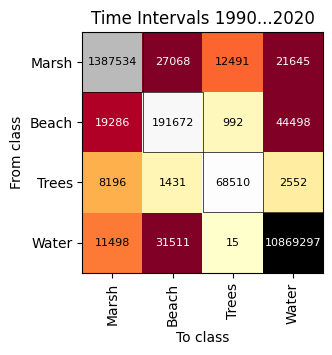

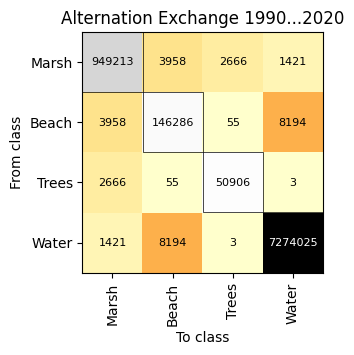

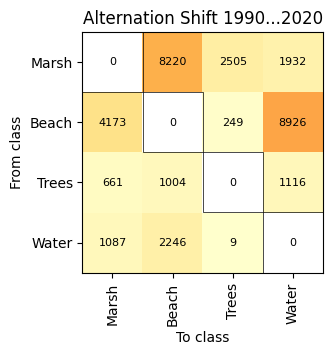

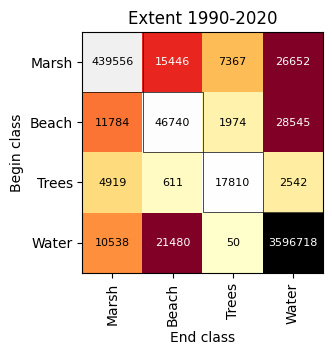

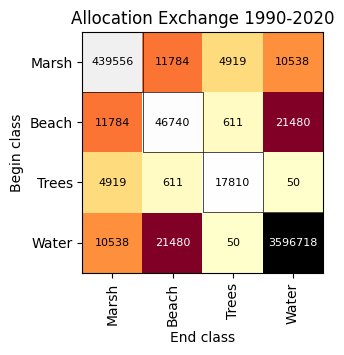

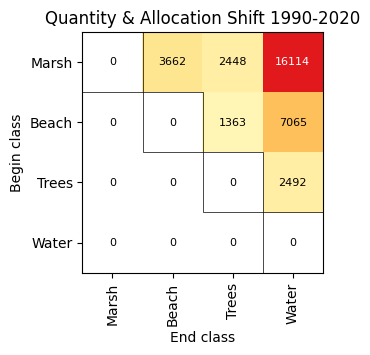

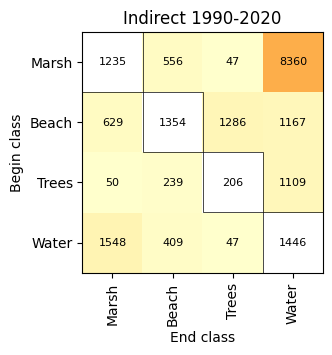

All heatmaps saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts


In [ ]:
# @title 7.4.3.4 Plot heatmaps
# 1. Define visual style configuration
# Adjust the values below to customize the appearance of all 7 heatmaps.
style_config = {
    # Font size for the class names on the X-axis (bottom)
    "tick_fontsize_x": 10,

    # Font size for the class names on the Y-axis (left)
    "tick_fontsize_y": 10,

    # Font size for the axis labels ("To class", "Begin class", etc.)
    "axis_label_fontsize": 10,

    # Font size for the main title of the heatmap
    "title_fontsize": 12,

    # Colormap for positive values (default is Yellow-Orange-Red: "YlOrRd")
    "cmap": "YlOrRd",

    # Base size of each cell in inches (controls the overall figure size)
    "cell_size_inch": 0.8,

    # Auto color scale bounds
    "vmin": 0.0,
    "vmax": None,
}

print(
    "Generating Heatmaps...",
)

# Identify the maximum value of the diagonal of the "Allocation Exchange" (all_exc) matrix
global_diag_vmax = float(np.diag(matrices["all_exc"].values).max())

# Identify the maximum off-diagonal value of the "Allocation Exchange" (all_exc) matrix
# to standardize the color scale across all matrices.
all_exc_vals = matrices["all_exc"].values.astype(float).copy()
np.fill_diagonal(all_exc_vals, 0.0)
global_off_diag_vmax = float(np.nanmax(all_exc_vals))
if global_off_diag_vmax <= 0.0:
    global_off_diag_vmax = 1.0

# Update style_config to apply the global scale
style_config["vmax"] = global_off_diag_vmax

# Calculate a uniform font size based on the "Time Intervals" (sum) matrix to prevent overflow
sum_matrix_vals = matrices["sum"].values
max_digits = 0
for i in range(sum_matrix_vals.shape[0]):
    for j in range(sum_matrix_vals.shape[1]):
        val = float(sum_matrix_vals[i, j])
        if not np.isnan(val):
            num_digits = len(f"{int(round(val))}")
            if num_digits > max_digits:
                max_digits = num_digits

base_fs = 20.0 # base annotation font size
if max_digits > 3:
    scale_factor = max(0.4, 3.0 / max_digits)
    global_ann_fontsize = max(5.0, base_fs * scale_factor)
else:
    global_ann_fontsize = base_fs

style_config["ann_fontsize"] = global_ann_fontsize

# 2. Iterate and plot each heatmap
for key, meta in MATRIX_META.items():
    suffix = meta[0]
    title_part = meta[1]
    m_type = meta[2]

    df_to_plot = matrices[key]

    is_flow = m_type == "flow"
    label_suffix = "..." if is_flow else "-"

    full_title = f"{title_part} {str_y0}{label_suffix}{str_y1}"

    save_fig_path = os.path.join(
        output_path,
        "charts",
        f"heatmap_{suffix}_{interval_str}.png",
    )

    x_label = "To class" if is_flow else "End class"
    y_label = "From class" if is_flow else "Begin class"

    is_extent = (key == "ext")

    # Identify blank cells for the specific matrix (Time Intervals = sum)
    # Beach = '3', Water = '4'
    white_cells = []
    if key == "sum":
        labels_list = list(df_to_plot.index)
        if '3' in labels_list and '4' in labels_list:
            row_idx = labels_list.index('3')
            col_idx = labels_list.index('4')
            white_cells.append((row_idx, col_idx))

    plot_heatmap(
        df=df_to_plot,
        title=full_title,
        save_path=save_fig_path,
        xlabel=x_label,
        ylabel=y_label,
        show_diagonal_values=True,
        equalize_diagonal_font=is_extent,
        white_cells=white_cells,
        diag_vmax=global_diag_vmax,
        **style_config,
    )

final_out_dir = os.path.join(
    output_path,
    "charts",
)

print(
    f"All heatmaps saved to: {final_out_dir}",
)


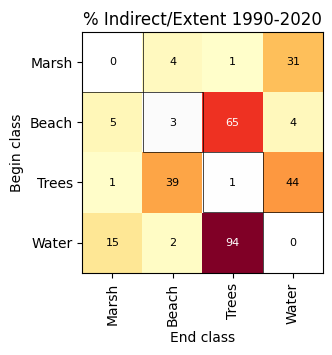

Plot saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/heatmap_indirect_ratio_1990-2020.png


In [ ]:
# @title 7.4.3.5 Plot indirect ratio heatmap
def _extract_year_str(val) -> str:
    """
    Extract the first sequence of digits from a given value to represent a year.

    Parameters
    ----------
    val : any
        The input value (e.g., string, integer) from which to extract the year.

    Returns
    -------
    str
        A string containing the extracted digits, or the original value as a string if no digits are found.
    """
    match = re.search(r"(\d+)", str(val))
    return match.group(1) if match else str(val)

str_y0 = _extract_year_str(years[0])
str_y1 = _extract_year_str(years[-1])
interval_str = f"{str_y0}-{str_y1}"

# 1. Load the ratio matrix from the previously generated CSV
csv_filename = f"transition_matrix_indirect_ratio_{interval_str}.csv"
csv_path_ratio = os.path.join(
    output_path,
    "tables",
    csv_filename,
)

df_unaccounted_ratio = pd.read_csv(
    csv_path_ratio,
    index_col=0,
)

# Convert index/columns back to string for consistency
df_unaccounted_ratio.index = df_unaccounted_ratio.index.map(
    str,
)
df_unaccounted_ratio.columns = df_unaccounted_ratio.columns.map(
    str,
)

# Reorder based on the sum matrix order (to keep it consistent with other maps)
if "sum" in matrices:
    order_labels = list(
        matrices["sum"].index,
    )
    df_unaccounted_ratio = df_unaccounted_ratio.reindex(
        index=order_labels,
        columns=order_labels,
    )

# 2. Plot the heatmap using formatting from the no-legend panel
chart_filename = f"heatmap_indirect_ratio_{interval_str}.png"
chart_path_ratio = os.path.join(
    output_path,
    "charts",
    chart_filename,
)

# Determine max value for color scale (ignoring NaNs safely)
valid_vals = df_unaccounted_ratio.values[
    np.isfinite(
        df_unaccounted_ratio.values,
    )
]
if valid_vals.size > 0:
    max_val = float(
        np.nanmax(
            valid_vals,
        ),
    )
else:
    max_val = 100.0

if max_val <= 0:
    max_val = 100.0

plot_heatmap(
    df=df_unaccounted_ratio,
    title=f"% Indirect/Extent {interval_str}",
    save_path=chart_path_ratio,
    xlabel="End class",
    ylabel="Begin class",
    show_diagonal_values=True,
    equalize_diagonal_font=True,
    white_cells=[],
    vmin=0.0,
    vmax=max_val,
    diag_vmax=100.0,
    ann_fontsize=global_ann_fontsize, # Uses global font size computed before
    tick_fontsize_x=10,
    tick_fontsize_y=10,
    axis_label_fontsize=10,
    title_fontsize=12,
    cmap="YlOrRd",
    cell_size_inch=0.8,
)

print(
    f"Plot saved to: {chart_path_ratio}",
)


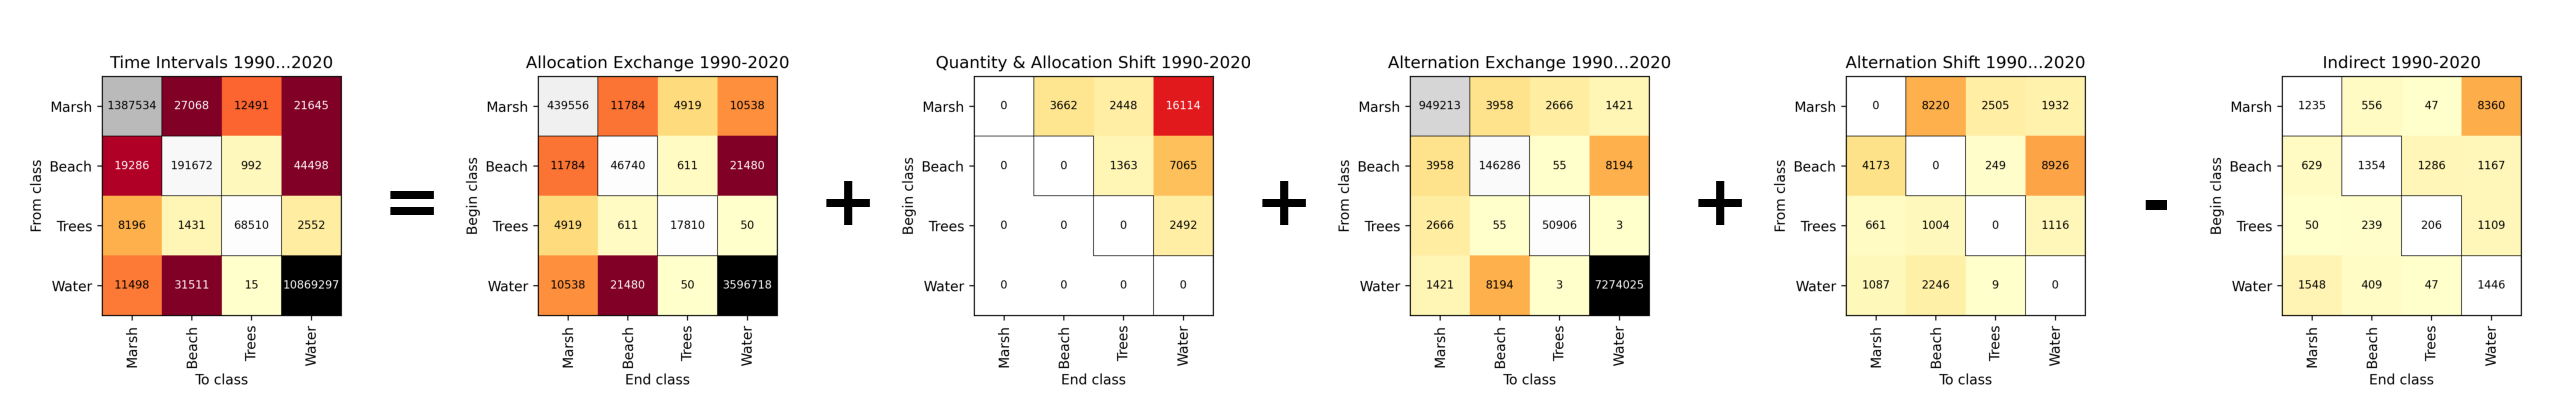

Heatmap panel saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/heatmap_panel_equation_1990-2020.png


In [ ]:
# @title 7.4.3.6 Plot heatmap panel
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def create_arithmetic_heatmap_panel(
    output_dir: str,
    interval: str,
) -> None:
    """
    Create a horizontal panel of matrix heatmaps by loading already saved images.

    Parameters
    ----------
    output_dir : str
        The base directory where charts are saved.
    interval : str
        The time interval string used in filenames.
    """
    # 1. Define the sequence of heatmap file suffixes and symbols
    image_suffixes = [
        "time_intervals",
        "allocation_exchange",
        "quantity_allocation_shift",
        "alternation_exchange",
        "alternation_shift",
        "indirect_extent",
    ]
    symbols = [
        "=",
        "+",
        "+",
        "+",
        "-",
    ]
    total_elements = len(image_suffixes) + len(symbols)

    # 2. Create a figure with subplots
    fig, axes = plt.subplots(
        nrows=1,
        ncols=total_elements,
        figsize=(
            26,
            4,
        ),
        gridspec_kw={
            "width_ratios": [
                4, 0.5, 4, 0.5, 4, 0.5, 4, 0.5, 4, 0.5, 4
            ],
            "wspace": 0.05,
        },
    )

    # 3. Iterate over the subplot axes to populate the panel
    img_idx, sym_idx = 0, 0
    for i in range(
        total_elements,
    ):
        ax = axes[i]
        ax.axis(
            "off",
        )

        # Plot images on even indices
        if i % 2 == 0:
            img_name = f"heatmap_{image_suffixes[img_idx]}_{interval}.png"
            img_path = os.path.join(
                output_dir,
                "charts",
                img_name,
            )
            if os.path.exists(
                img_path,
            ):
                img = mpimg.imread(
                    img_path,
                )
                ax.imshow(
                    img,
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    f"Missing\n{img_name}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )
            img_idx += 1
        # Plot symbols on odd indices
        else:
            ax.text(
                0.5,
                0.5,
                symbols[sym_idx],
                ha="center",
                va="center",
                fontsize=50,
                fontweight="bold",
            )
            sym_idx += 1

    # 4. Adjust layout and save the panel
    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.99,
        bottom=0.01,
        wspace=0.05,
    )
    panel_path = os.path.join(
        output_dir,
        "charts",
        f"heatmap_panel_equation_{interval}.png",
    )
    plt.savefig(
        panel_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()
    print(
        f"Heatmap panel saved to: {panel_path}",
    )

create_arithmetic_heatmap_panel(
    output_dir=output_path,
    interval=interval_str,
)


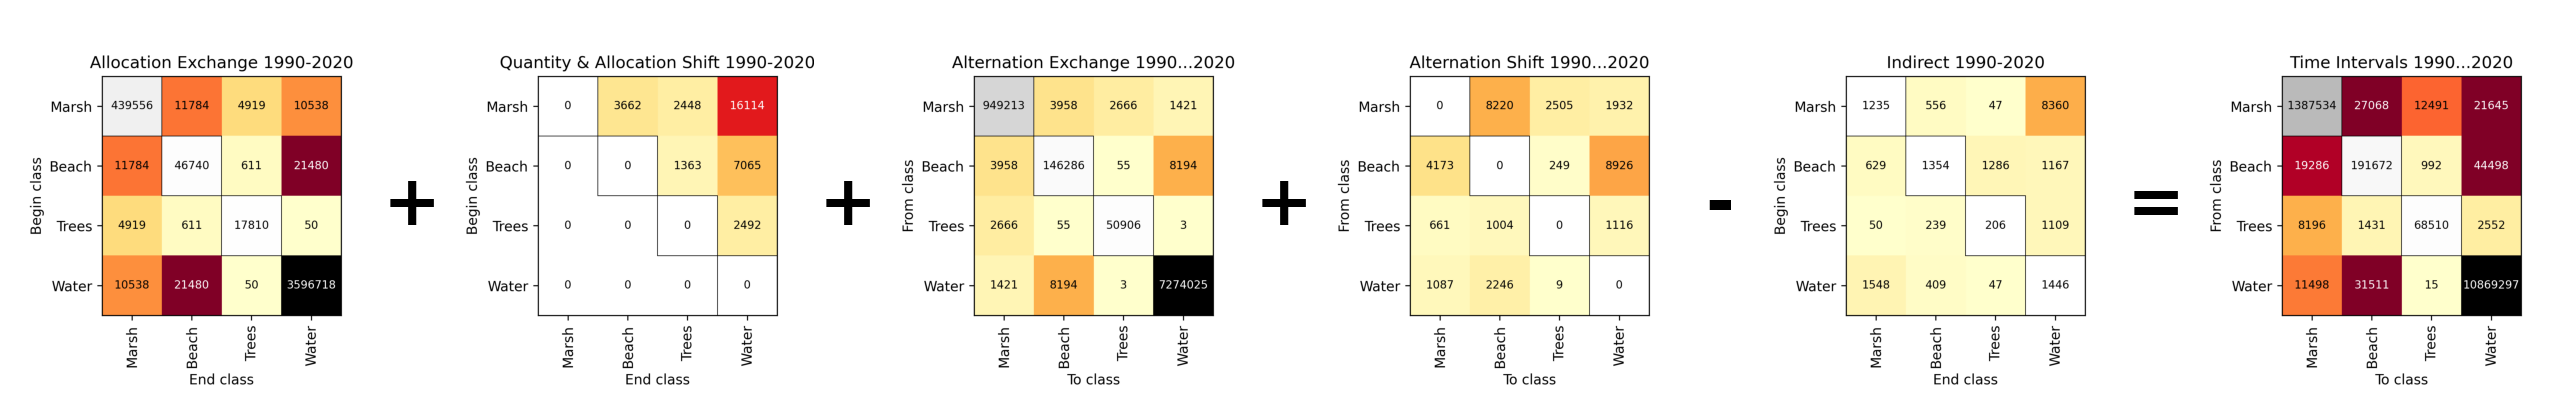

Alternative heatmap panel saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/heatmap_panel_equation_alt_1990-2020.png


In [ ]:
# @title 7.4.3.7 Plot alternative heatmap panel
def create_arithmetic_heatmap_panel_alt(
    output_dir: str,
    interval: str,
) -> None:
    """
    Create a horizontal panel of matrix heatmaps by loading already saved images.
    This version places the 'time_intervals' matrix at the end of the equation.
    """
    # 1. Define the sequence of heatmap file suffixes and symbols
    image_suffixes = [
        "allocation_exchange",
        "quantity_allocation_shift",
        "alternation_exchange",
        "alternation_shift",
        "indirect_extent",
        "time_intervals",
    ]
    symbols = [
        "+",
        "+",
        "+",
        "-",
        "=",
    ]
    total_elements = len(image_suffixes) + len(symbols)

    # 2. Create a figure with subplots
    fig, axes = plt.subplots(
        nrows=1,
        ncols=total_elements,
        figsize=(
            26,
            4,
        ),
        gridspec_kw={
            "width_ratios": [
                4, 0.5, 4, 0.5, 4, 0.5, 4, 0.5, 4, 0.5, 4
            ],
            "wspace": 0.05,
        },
    )

    # 3. Iterate over the subplot axes to populate the panel
    img_idx, sym_idx = 0, 0
    for i in range(
        total_elements,
    ):
        ax = axes[i]
        ax.axis(
            "off",
        )

        # Plot images on even indices
        if i % 2 == 0:
            img_name = f"heatmap_{image_suffixes[img_idx]}_{interval}.png"
            img_path = os.path.join(
                output_dir,
                "charts",
                img_name,
            )
            if os.path.exists(
                img_path,
            ):
                img = mpimg.imread(
                    img_path,
                )
                ax.imshow(
                    img,
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    f"Missing\n{img_name}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )
            img_idx += 1
        # Plot symbols on odd indices
        else:
            ax.text(
                0.5,
                0.5,
                symbols[sym_idx],
                ha="center",
                va="center",
                fontsize=50,
                fontweight="bold",
            )
            sym_idx += 1

    # 4. Adjust layout and save the panel
    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.99,
        bottom=0.01,
        wspace=0.05,
    )
    panel_path = os.path.join(
        output_dir,
        "charts",
        f"heatmap_panel_equation_alt_{interval}.png",
    )
    plt.savefig(
        panel_path,
        dpi=300,
        bbox_inches="tight",
        format="png",
    )
    plt.show()
    print(
        f"Alternative heatmap panel saved to: {panel_path}",
    )

# Execute
create_arithmetic_heatmap_panel_alt(
    output_dir=output_path,
    interval=interval_str,
)


### 7.5 Charts




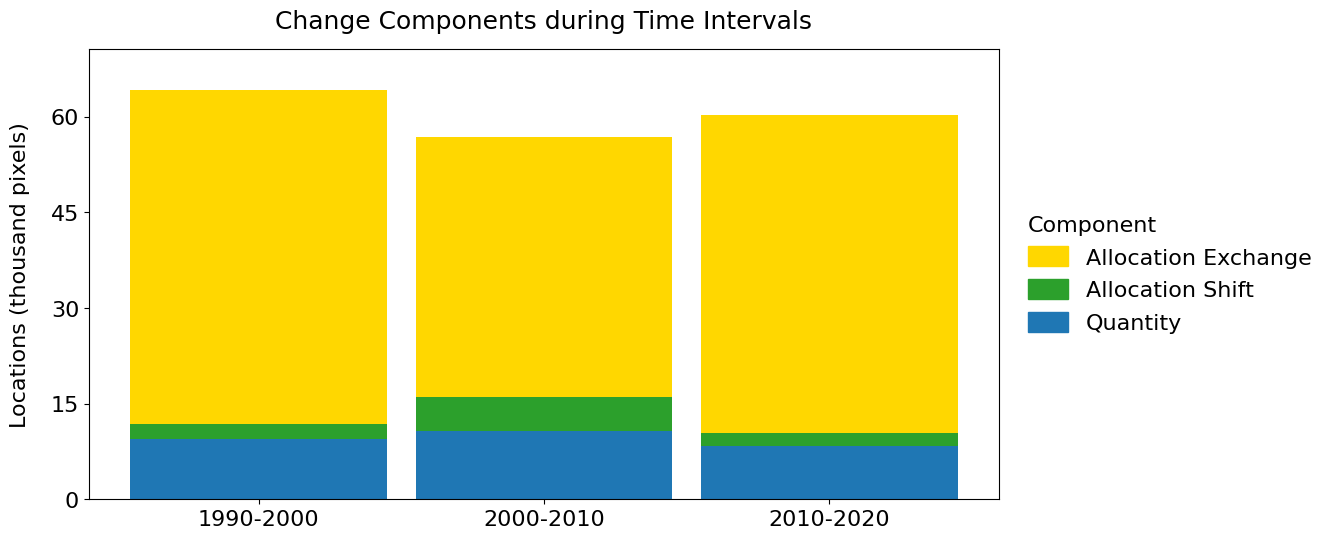

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_change_components_time_interval.png


In [ ]:
# @title 7.5.1 Plot change components during time intervals

# Read change components CSV from the tables folder
csv_path = os.path.join(
    output_path,
    "tables",
    "change_components.csv",
)
df = pd.read_csv(
    csv_path,
)

# Filter only time intervals
time_df = df[
    df["Time_Interval"].str.contains("-")
]

# Aggregate totals per interval and component (Gain)
totals = (
    time_df.groupby(
        ["Time_Interval", "Component"],
    )["Gain"]
    .sum()
    .unstack()
)

# Choose scale automatically based on max value
max_val = totals[["Quantity", "Shift", "Exchange"]].to_numpy().max()

if max_val >= 1_000_000_000_000:
    scale_factor = 1_000_000_000_000
    suffix = " (trillion pixels)"
elif max_val >= 1_000_000_000:
    scale_factor = 1_000_000_000
    suffix = " (billion pixels)"
elif max_val >= 1_000_000:
    scale_factor = 1_000_000
    suffix = " (million pixels)"
elif max_val >= 1_000:
    scale_factor = 1_000
    suffix = " (thousand pixels)"
elif max_val >= 100:
    scale_factor = 100
    suffix = " (hundred pixels)"
else:
    scale_factor = 1
    suffix = " (pixels)"

y_label = f"Locations{suffix}"

# Scaled totals per component for plotting
scaled_totals = totals[
    [
        "Quantity",
        "Shift",
        "Exchange",
    ]
] / scale_factor

# Maximum stacked height (Quantity + Exchange + Shift)
stacked_max = scaled_totals.sum(
    axis=1,
).max()

# Create figure and axis
fig, ax = plt.subplots(
    figsize=(
        14,
        6,
    ),
)

# Colors
colors = [
    "#1f77b4",  # Quantity
    "#2ca02c",  # Shift
    "#ffd700",  # Exchange

]
components_color = {
    "Quantity": "#1f77b4",
    "Shift":    "#2ca02c",
    "Exchange": "#ffd700"

}

# Stacked bars using scaled values
for idx, comp in enumerate(
    [
        "Quantity",
        "Shift",
        "Exchange",
    ],
):
    bottom_values = (
        scaled_totals.iloc[:, :idx].sum(
            axis=1,
        )
        if idx > 0
        else 0
    )
    ax.bar(
        totals.index,
        scaled_totals[comp],
        label=comp,
        color=colors[idx],
        edgecolor="none",
        bottom=bottom_values,
        width=0.9,
    )

# Axes formatting
ax.set_ylabel(
    y_label,
    fontsize=16,
    labelpad=15
)
ax.set_title(
    "Change Components during Time Intervals",
    fontsize=18,
    pad=15
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=16,
)

# Adaptive rotation for x-axis tick labels
labels = ax.get_xticklabels()
n_labels = len(labels)

if n_labels <= 6:
    rotation = 0
    ha = "center"
elif n_labels <= 12:
    rotation = 45
    ha = "right"
else:
    rotation = 90
    ha = "center"

plt.setp(
    labels,
    rotation=rotation,
    ha=ha,
)

# Dynamically set y-axis limits and ticks
ax.set_ylim(0, stacked_max * 1.1 if stacked_max > 0 else 1.0)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

# Legend (custom labels)
legend_elements = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=components_color["Exchange"],
        label="Allocation Exchange",
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=components_color["Shift"],
        label="Allocation Shift",
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=components_color["Quantity"],
        label="Quantity",
    ),
]
ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(
        1.01,
        0.5,
    ),
    title="Component",
    title_fontsize=16,
    fontsize=16,
    alignment="left",
    frameon=False,
    handlelength=1.8,
    handleheight=1.0,
    labelspacing=0.5,
    handletextpad=0.8
)

# Force main plotting box spatial coordinates to match other interval charts
fig.subplots_adjust(
    left=0.1,
    right=0.75,
    bottom=0.15,
    top=0.9,
)

# Save and show
charts_dir = os.path.join(
    output_path,
    "charts",
)
os.makedirs(
    charts_dir,
    exist_ok=True,
)

out_fig_path = os.path.join(
    charts_dir,
    "chart_change_components_time_interval.png",
)

plt.savefig(
    out_fig_path,
    bbox_inches="tight",
    format="png",
    dpi=300,
)
plt.show()

print(f"Chart saved to: {out_fig_path}")

In [ ]:
# @title 7.5.2 Compute change components overall

def export_overall_change_components(
    csv_path: str,
    output_dir: str,
) -> None:
    """
    Calculate the overall change components and export them to a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the 'change_components.csv' file.
    output_dir : str
        Directory path to the main output folder.
    """
    # 1. Load data
    df = pd.read_csv(csv_path)

    # 2. Calculate standard components
    component_totals = {
        "Quantity": df[
            (df["Component"] == "Allocation_Quantity")
            & (df["Time_Interval"] == "extent")
        ]["Gain"].sum(),
        "Allocation_Exchange": df[
            (df["Component"] == "Allocation_Exchange")
            & (df["Time_Interval"] == "extent")
        ]["Gain"].sum(),
        "Allocation_Shift": df[
            (df["Component"] == "Allocation_Shift")
            & (df["Time_Interval"] == "extent")
        ]["Gain"].sum(),
        "Alternation_Exchange": df[
            (df["Time_Interval"] == "alternation_exchange")
        ]["Gain"].sum(),
        "Alternation_Shift": df[
            (df["Time_Interval"] == "alternation_shift")
        ]["Gain"].sum(),
    }

    # 3. Read the Unaccounted Extent matrix
    tables_dir = os.path.join(
        output_dir,
        "tables"
    )
    u_csv = os.path.join(
        tables_dir,
        f"transition_matrix_indirect_extent_{years[0]}-{years[-1]}.csv"
    )

    if os.path.exists(u_csv):
        df_u = pd.read_csv(u_csv, index_col=0)
        u_vals = df_u.values.astype(float)
        np.fill_diagonal(u_vals, 0)
        sum_u = u_vals.sum()
    else:
        print(f"Warning: Indirect Extent file not found at {u_csv}.")
        sum_u = 0.0

    # 4. Include Unaccounted Extent into Alternation Shift
    component_totals["Alternation_Shift"] -= sum_u

    # 5. Create DataFrame and Export
    df_export = pd.DataFrame(
        list(component_totals.items()),
        columns=["Component", "Pixels"]
    )

    out_csv_path = os.path.join(
        tables_dir,
        "change_components_overall_summary.csv"
    )
    df_export.to_csv(
        out_csv_path,
        index=False
    )

    print(f"Overall components successfully saved to: {out_csv_path}")
    display(df_export)

# 6. Execute the function
csv_components_path = os.path.join(
    output_path,
    "tables",
    "change_components.csv"
)

export_overall_change_components(
    csv_path=csv_components_path,
    output_dir=output_path,
)

Overall components successfully saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/tables/change_components_overall_summary.csv


,Component,Pixels
0,Quantity,26990.0
1,Allocation_Exchange,98764.0
2,Allocation_Shift,6154.0
3,Alternation_Exchange,32594.0
4,Alternation_Shift,16681.0


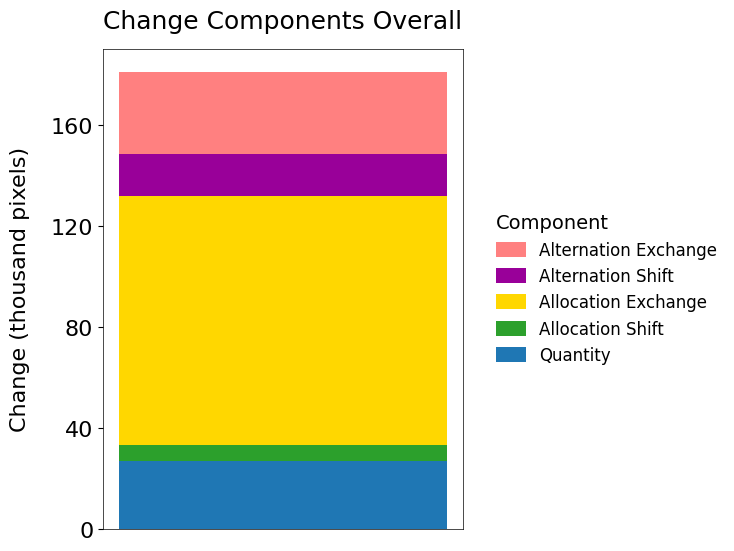

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_change_components_overall.png


In [ ]:
# @title 7.5.3 Plot change component overall

def plot_overall_change_components(
    summary_csv_path: str,
    output_path: str,
) -> None:
    """
    Plot overall change components as a single stacked bar chart, reading from the summary CSV.

    Parameters
    ----------
    summary_csv_path : str
        Path to the summary CSV containing overall change components.
    output_path : str
        Directory to save the resulting chart.

    Returns
    -------
    None
    """
    # 1. Load data from the summary CSV calculated in the previous cell
    df = pd.read_csv(summary_csv_path)
    component_totals = dict(zip(df['Component'], df['Pixels']))

    # 2. Define Colors and component order
    components_color = {
        "Quantity": "#1f77b4",
        "Allocation_Exchange": "#ffd700",
        "Alternation_Exchange": "#ff8080",
        "Allocation_Shift": "#2ca02c",
        "Alternation_Shift": "#990099",
    }

    component_order = [
        "Quantity",
        "Allocation_Shift",
        "Allocation_Exchange",
        "Alternation_Shift",
        "Alternation_Exchange",
    ]

    # 3. Initialize figure and axis
    fig, ax = plt.subplots(
        figsize=(
            6,
            6
        ),
    )

    # 4. Plot each component in a stacked bar at a single x-position
    bottom = 0.0
    for component in component_order:
        val = component_totals.get(component, 0.0)
        if val > 0:
            ax.bar(
                0,
                val,
                bottom=bottom,
                color=components_color[component],
                edgecolor="none",
                width=0.4,
            )
            bottom += val

    # 5. Automatic scale calculation
    max_val = bottom
    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Change{suffix}"

    # 6. Axes formatting and labels
    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x / scale_factor:g}"))
    ax.set_title(
        "Change Components Overall",
        fontsize=18,
        pad=15
        )
    ax.set_xticks([])
    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16
    )

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    # ----- 7. Y-Axis Dynamic Scaling Logic -----
    max_y_unscaled = bottom
    max_ylim = max_y_unscaled * 1.05 if max_y_unscaled > 0 else 1.0
    ax.set_ylim(0, max_ylim)

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=max(6, int(max_ylim) + 2) if max_ylim < 20 else 6
        )
    )
    # ----------------------------------------

    # 8. Define custom legend elements
    legend_elements = [
        Patch(facecolor=components_color["Alternation_Exchange"], label="Alternation Exchange"),
        Patch(facecolor=components_color["Alternation_Shift"],    label="Alternation Shift"),
        Patch(facecolor=components_color["Allocation_Exchange"],  label="Allocation Exchange"),
        Patch(facecolor=components_color["Allocation_Shift"],     label="Allocation Shift"),
        Patch(facecolor=components_color["Quantity"],             label="Quantity"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        title="Component",
        title_fontsize=14,
        fontsize=12,
        alignment="left",
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force the main plotting box to always occupy the exact same spatial coordinates in the figure
    fig.subplots_adjust(
      left=0.15,
      right=0.75,
      bottom=0.1,
      top=0.9
    )

    # 9. Final layout adjustment and export
    charts_dir = os.path.join(
      output_path,
      "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )

    out_path = os.path.join(
        charts_dir,
        "chart_change_components_overall.png"
    )
    plt.savefig(
        out_path,
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()
    print(f"Chart saved to: {out_path}")


# 10. Specify paths and execute the plotting function
summary_csv_path = os.path.join(
    output_path,
    "tables",
    "change_components_overall_summary.csv"
)

plot_overall_change_components(
    summary_csv_path=summary_csv_path,
    output_path=output_path,
)


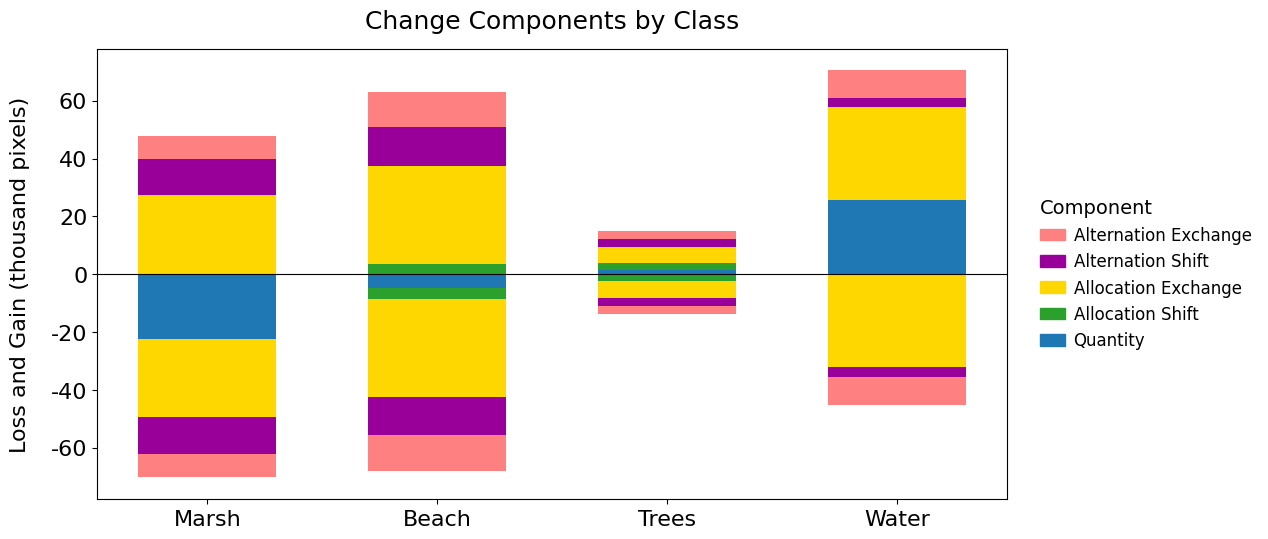

Chart saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/charts/chart_change_component_change_class.png


In [ ]:
# @title 7.5.4 Plot change components by class
class ComponentVisualizer:
    """
    Visualize change components by class.

    Handles negative correction terms in alternation components correctly.
    """

    @staticmethod
    def plot_gain_loss_stacked(
        df: pd.DataFrame,
        class_labels_dict: dict,
        title: str,
        output_path: str,
    ) -> None:
        """
        Plot per-class gains and losses as stacked bars with auto-scaled y-axis.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the change components data.
        class_labels_dict : dict
            Dictionary mapping class IDs to metadata (must contain "name").
        title : str
            Title of the chart.
        output_path : str
            Directory path where the output plot will be saved.

        Returns
        -------
        None
        """
        # 1. Filter and Prepare Data
        target_intervals = [
            "extent",
            "alternation_shift",
            "alternation_exchange",
        ]

        df_sub = df[
            df[
                "Time_Interval"
            ].isin(
                target_intervals,
            )
        ].copy()

        df_sub[
            "Component"
        ] = df_sub[
            "Component"
        ].str.replace(
            "Allocation_Quantity",
            "Quantity",
        )

        # 2. Colors and Order
        components_map = {
            "Quantity":            "#1f77b4",
            "Allocation_Exchange": "#ffd700",
            "Alternation_Exchange":"#ff8080",
            "Allocation_Shift":    "#2ca02c",
            "Alternation_Shift":   "#990099",
        }

        comp_groups = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
        ]

        # 3. Identify Classes and Sort by Net Quantity Change
        classes = sorted(
            df_sub[
                "Class"
            ].unique(),
        )

        class_stats = []
        for cls in classes:
            c_data = df_sub[
                df_sub[
                    "Class"
                ] == cls
            ]
            qty_gain = c_data[
                c_data[
                    "Component"
                ] == "Quantity"
            ][
                "Gain"
            ].sum()

            qty_loss = c_data[
                c_data[
                    "Component"
                ] == "Quantity"
            ][
                "Loss"
            ].sum()

            class_stats.append(
                (
                    cls,
                    qty_gain - qty_loss,
                ),
            )

        ordered_classes = [
            x[
                0
            ]
            for x in sorted(
                class_stats,
                key=lambda x: x[
                    1
                ],
            )
        ]

        # 4. Prepare Plot Data (Handling the Net Logic)
        plot_data = []
        max_val = 0.0

        for cls in ordered_classes:
            c_data = df_sub[
                df_sub[
                    "Class"
                ] == cls
            ]

            # --- GAINS ---
            gains = {}
            for comp in comp_groups:
                gains[
                    comp
                ] = c_data[
                    c_data[
                        "Component"
                    ] == comp
                ][
                    "Gain"
                ].sum()

            raw_alt_exc = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Exchange"
            ][
                "Gain"
            ].sum()

            raw_alt_shift = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Shift"
            ][
                "Gain"
            ].sum()

            net_alt = raw_alt_exc + raw_alt_shift

            adj_alt_exc = 0.0
            adj_alt_shift = 0.0

            if net_alt > 0.0001:
                if raw_alt_exc > 0:
                    adj_alt_exc = raw_alt_exc
                    adj_alt_shift = max(
                        0,
                        net_alt - raw_alt_exc,
                    )
                else:
                    adj_alt_exc = 0
                    adj_alt_shift = net_alt

            gains[
                "Alternation_Exchange"
            ] = adj_alt_exc
            gains[
                "Alternation_Shift"
            ] = adj_alt_shift

            # --- LOSSES ---
            losses = {}
            for comp in comp_groups:
                losses[
                    comp
                ] = c_data[
                    c_data[
                        "Component"
                    ] == comp
                ][
                    "Loss"
                ].sum()

            raw_alt_exc_l = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Exchange"
            ][
                "Loss"
            ].sum()

            raw_alt_shift_l = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Shift"
            ][
                "Loss"
            ].sum()

            net_alt_l = raw_alt_exc_l + raw_alt_shift_l

            adj_alt_exc_l = 0.0
            adj_alt_shift_l = 0.0

            if net_alt_l > 0.0001:
                if raw_alt_exc_l > 0:
                    adj_alt_exc_l = raw_alt_exc_l
                    adj_alt_shift_l = max(
                        0,
                        net_alt_l - raw_alt_exc_l,
                    )
                else:
                    adj_alt_exc_l = 0
                    adj_alt_shift_l = net_alt_l

            losses[
                "Alternation_Exchange"
            ] = adj_alt_exc_l
            losses[
                "Alternation_Shift"
            ] = adj_alt_shift_l

            total_g = sum(
                gains.values(),
            )
            total_l = sum(
                losses.values(),
            )
            max_val = max(
                max_val,
                total_g,
                total_l,
            )

            plot_data.append(
                {
                    "class": cls,
                    "gains": gains,
                    "losses": losses,
                },
            )

        # 5. Determine Scale Factor
        if max_val >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000
            suffix = " (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor = 1_000_000_000
            suffix = " (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor = 1_000_000
            suffix = " (million pixels)"
        elif max_val >= 1_000:
            scale_factor = 1_000
            suffix = " (thousand pixels)"
        elif max_val >= 100:
            scale_factor = 100
            suffix = " (hundred pixels)"
        else:
            scale_factor = 1
            suffix = " (pixels)"

        y_label = f"Loss and Gain{suffix}"

        # 6. Plotting
        fig, ax = plt.subplots(
            figsize=(
                14,
                6,
            ),
        )

        x_pos = np.arange(
            len(
                ordered_classes,
            ),
        )
        width = 0.6

        stack_order = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
            "Alternation_Shift",
            "Alternation_Exchange",
        ]

        for idx, item in enumerate(
            plot_data,
        ):
            bottom_g = 0.0
            for comp in stack_order:
                val = item[
                    "gains"
                ][
                    comp
                ] / scale_factor
                if val > 0:
                    ax.bar(
                        x_pos[
                            idx
                        ],
                        val,
                        width,
                        bottom=bottom_g,
                        color=components_map[
                            comp
                        ],
                        edgecolor="none",
                    )
                    bottom_g += val

            bottom_l = 0.0
            for comp in stack_order:
                val = item[
                    "losses"
                ][
                    comp
                ] / scale_factor
                if val > 0:
                    ax.bar(
                        x_pos[
                            idx
                        ],
                        -val,
                        width,
                        bottom=bottom_l,
                        color=components_map[
                            comp
                        ],
                        edgecolor="none",
                    )
                    bottom_l -= val

        class_names = [
            class_labels_dict.get(
                int(
                    c,
                ) if str(
                    c,
                ).isdigit() else c,
                {},
            ).get(
                "name",
                str(
                    c,
                ),
            )
            for c in ordered_classes
        ]

        ax.set_xticks(
            x_pos,
        )
        ax.set_xticklabels(
            class_names,
            rotation=0,
            ha="center",
            fontsize=16,
        )
        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
        )

        ax.set_ylabel(
            y_label,
            fontsize=16,
            labelpad=15,
        )

        ax.set_title(
            title,
            fontsize=18,
            pad=15,
        )

        ax.tick_params(
            axis="x",
            labelsize=16,
        )

        ax.tick_params(
            axis="y",
            labelsize=16,
        )

        limit = max_val / scale_factor * 1.1 if max_val > 0 else 1.0
        ax.set_ylim(
            -limit,
            limit,
        )
        ax.yaxis.set_major_locator(
            ticker.MaxNLocator(
                integer=True,
                nbins=10,
            ),
        )
        ax.yaxis.set_major_formatter(
            ticker.FormatStrFormatter(
                "%d",
            ),
        )

        handles = [
            plt.Rectangle(
                (
                    0,
                    0,
                ),
                1,
                1,
                color=components_map[
                    c
                ],
                label=c.replace(
                    "_",
                    " ",
                ),
            )
            for c in reversed(
                stack_order,
            )
        ]

        ax.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            title="Component",
            title_fontsize=14,
            alignment="left",
            fontsize=12,
            frameon=False,
            handletextpad=0.5,
            handlelength=1.5,
        )

        # Force main plotting box spatial coordinates to match other interval charts
        fig.subplots_adjust(
            left=0.1,
            right=0.75,
            bottom=0.15,
            top=0.9,
        )

        # 7. Save and show
        charts_dir = os.path.join(
            output_path,
            "charts",
        )
        os.makedirs(
            charts_dir,
            exist_ok=True,
        )

        out_fig = os.path.join(
            charts_dir,
            "chart_change_component_change_class.png",
        )

        plt.savefig(
            out_fig,
            bbox_inches="tight",
            format="png",
            dpi=300,
        )
        plt.show()

        print(
            f"Chart saved to: {out_fig}"
        )

# 8. Execution
csv_path = os.path.join(
    output_path,
    "tables",
    "change_components.csv",
)
df = pd.read_csv(
    csv_path,
)

ComponentVisualizer.plot_gain_loss_stacked(
    df=df,
    class_labels_dict=class_labels_dict,
    title="Change Components by Class",
    output_path=output_path,
)


### 7.6 Maps

In [ ]:
# @title 7.6.0 Compute raster maps
@nb.njit(
    nogil=True,
)
def compute_components_chunk(
    stack: np.ndarray,
    nodata: int,
) -> tuple:
    """
    Numba-optimized function to calculate Extent, Exchange, and Shift components.

    Parameters
    ----------
    stack : np.ndarray
        3D numpy array (time, height, width) for a specific spatial chunk.
    nodata : int
        Value representing NoData pixels.

    Returns
    -------
    tuple
        Three 2D numpy arrays (Extent, Exchange, Shift).
    """
    time_steps = stack.shape[0]
    h = stack.shape[1]
    w = stack.shape[2]

    out_extent = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )
    out_alt_exc = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )
    out_alt_shift = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )

    for y in range(
        h,
    ):
        for x in range(
            w,
        ):
            traj = stack[
                :,
                y,
                x,
            ]

            # 1. Check for NoData
            has_nodata = False
            for t in range(
                time_steps,
            ):
                if traj[t] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            # 2. Extent Component
            start_val = traj[0]
            end_val = traj[-1]
            extent_val = 1 if start_val != end_val else 0

            out_extent[
                y,
                x,
            ] = extent_val

            # 3. Find unique classes to build local transition matrix
            local_max = 0
            for t in range(
                time_steps,
            ):
                if traj[t] > local_max:
                    local_max = traj[t]

            m_r = np.zeros(
                (
                    local_max + 1,
                    local_max + 1,
                ),
                dtype=np.int32,
            )

            for t in range(
                time_steps - 1,
            ):
                s = traj[
                    t
                ]
                e = traj[
                    t + 1
                ]
                if s != e:
                    m_r[
                        s,
                        e,
                    ] += 1

            total_changes = np.sum(
                m_r,
            )

            # 4. Alternation Exchange Component
            total_exchange = 0
            for i in range(
                local_max + 1,
            ):
                for j in range(
                    local_max + 1,
                ):
                    if i != j:
                        val1 = m_r[
                            i,
                            j,
                        ]
                        val2 = m_r[
                            j,
                            i,
                        ]
                        total_exchange += val1 if val1 < val2 else val2

            out_alt_exc[
                y,
                x,
            ] = total_exchange

            # 5. Alternation Shift Component
            total_shift = total_changes - extent_val - total_exchange

            out_alt_shift[
                y,
                x,
            ] = total_shift if total_shift > 0 else 0

    return out_extent, out_alt_exc, out_alt_shift


def compute_all_change_rasters(
    file_list: list,
    output_dir: str,
    nodata_val: int,
    compress: str = "deflate",
) -> dict:
    """
    Compute Extent, Alternation Exchange, and Alternation Shift maps in a single pass.

    Parameters
    ----------
    file_list : list
        List of file paths to the input raster images.
    output_dir : str
        Directory to save the output rasters.
    nodata_val : int
        Value representing NoData pixels.
    compress : str, optional
        Compression algorithm to use (default is "deflate").

    Returns
    -------
    dict
        Dictionary containing paths to the generated output rasters.
    """
    # 1. Setup output paths
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    os.makedirs(
        rasters_dir,
        exist_ok=True,
    )

    out_paths = {
        "extent": os.path.join(
            rasters_dir,
            "map_extent.tif",
        ),
        "exchange": os.path.join(
            rasters_dir,
            "map_alternation_exchange.tif",
        ),
        "shift": os.path.join(
            rasters_dir,
            "map_alternation_shift.tif",
        )
    }

    # 2. Read metadata from first raster
    image_paths = sorted(
        file_list,
    )

    with rasterio.open(
        image_paths[0],
    ) as src:
        profile = src.profile.copy()

        profile.update(
            dtype=rasterio.uint8,
            count=1,
            nodata=nodata_val,
            compress=compress,
        )

        if compress == "deflate":
            profile.update(
                zlevel=9,
            )

        profile.pop(
            "blockxsize",
            None,
        )
        profile.pop(
            "blockysize",
            None,
        )
        profile.pop(
            "tiled",
            None,
        )

        # Use block windows if tiled, or row-by-row chunks
        windows = [
            window for ij, window in src.block_windows()
        ]

        if not windows:
            windows = []
            for idx in range(
                0,
                src.height,
                256,
            ):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    ),
                )

    print(
        f"Generating 3 raster maps across {len(windows)} chunks...",
    )

    # 3. Open writers for the 3 maps
    with rasterio.open(
        out_paths["extent"],
        'w',
        **profile,
    ) as dst_ext, \
         rasterio.open(
        out_paths["exchange"],
        'w',
        **profile,
    ) as dst_exc, \
         rasterio.open(
        out_paths["shift"],
        'w',
        **profile,
    ) as dst_shift:

        # 4. Iterate over chunks
        for window in tqdm(
            windows,
            desc="Processing chunks",
        ):
            stack_list = []

            for path in image_paths:
                with rasterio.open(
                    path,
                ) as src:
                    stack_list.append(
                        src.read(
                            1,
                            window=window,
                        ),
                    )

            stack = np.array(
                stack_list,
                dtype=np.uint8,
            )

            # 5. Compute components via Numba
            ext_arr, exc_arr, shift_arr = compute_components_chunk(
                stack,
                nodata_val,
            )

            # 6. Write chunk outputs
            dst_ext.write(
                ext_arr,
                1,
                window=window,
            )
            dst_exc.write(
                exc_arr,
                1,
                window=window,
            )
            dst_shift.write(
                shift_arr,
                1,
                window=window,
            )

    print(
        "\nSuccess! All 3 maps generated successfully.",
    )
    return out_paths


# 7. Execute the unified function
out_maps = compute_all_change_rasters(
    file_list=image_paths,
    output_dir=output_path,
    nodata_val=noData_value,
)

for map_type, path in out_maps.items():
    print(f"Raster map saved to: {path}")


Generating 3 raster maps across 1480 chunks...


Processing chunks: 100%|██████████| 1480/1480 [00:38<00:00, 38.89it/s]



Success! All 3 maps generated successfully.
Raster map saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/map_extent.tif
Raster map saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/map_alternation_exchange.tif
Raster map saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/map_alternation_shift.tif


Reading extent raster map for plotting: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/map_extent.tif


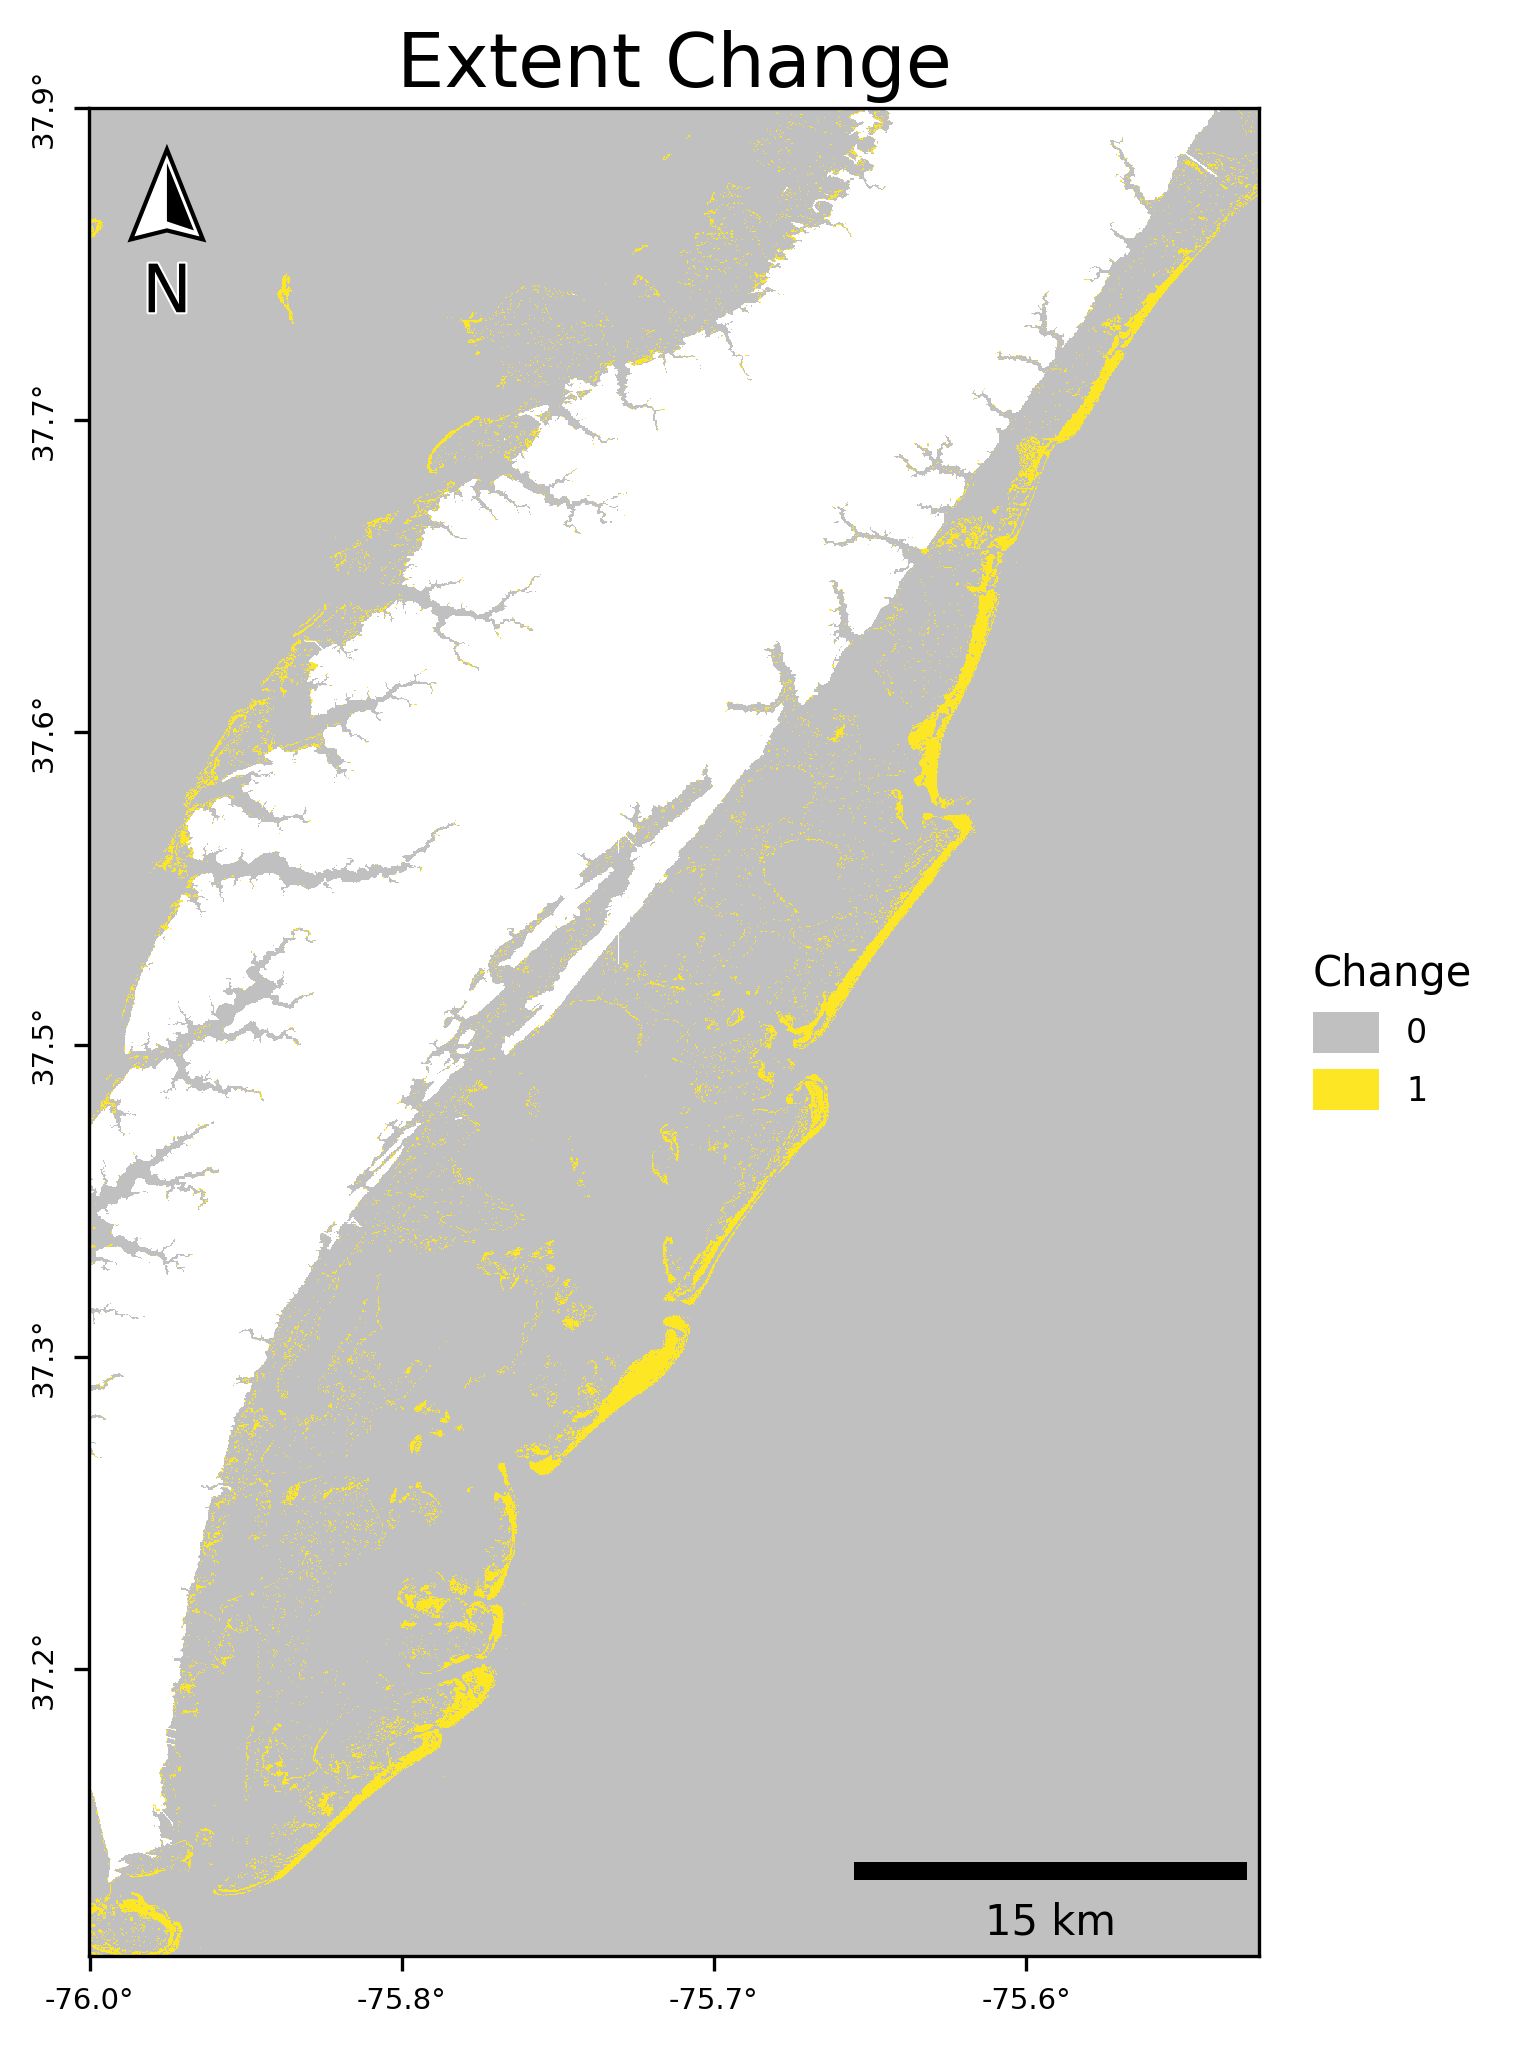

Map figure saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/maps/map_extent_change.png


In [ ]:
# @title 7.6.2 Plot extent change map
def plot_quantity_component_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "map_extent.tif",
) -> None:
    """
    Plot the Quantity Component map using a discrete integer scale.

    The visualization uses a specific color logic where the value 0 is
    represented in gray, while values greater than or equal to 1 are
    represented by a gradient color scale to indicate intensity.

    Parameters
    ----------
    output_dir : str
        The directory path containing the input raster file and where
        the output image will be saved.
    raster_filename : str, optional
        The filename of the raster to be plotted (default is
        "map_quantity_component.tif").

    Returns
    -------
    None
    """
    # 1. Input Validation and Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename,
    )

    if not os.path.exists(
        raster_path,
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}",
        )

    print(
        f"Reading extent raster map for plotting: {raster_path}",
    )

    pixel_size_km = compute_display_pixel_size_km(
            raster_path=raster_path,
            downsample_divisor=1
        )

    # 2. Data Loading and Masking
    with rasterio.open(
        raster_path,
    ) as src:
        scale_factor = 1
        data = src.read(
            1,
            out_shape=(
                int(src.height * scale_factor),
                int(src.width * scale_factor),
            ),
            resampling=rasterio.enums.Resampling.nearest,
        )

        # Force masking using the provided variable
        data_masked = np.ma.masked_equal(
            data,
            nodata_val,
        )

        left, bottom, right, top = src.bounds
        src_crs = src.crs
        transform = src.transform

    # Determine the integer range for the color scale
    data_max = int(
        data_masked.max(),
    )

    # Ensure at least 1 to prevent errors if the map is empty/flat
    if data_max == 0:
        data_max = 1

    # 3. Discrete Colormap Configuration
    original_cmap = plt.get_cmap("viridis_r")
    # Define the color for value 0 (Background/Gray)
    colors_list = ["#c0c0c0"] + [
        original_cmap(i) for i in np.linspace(0, 1, data_max)
    ]

    # Create the custom discrete colormap
    cmap = ListedColormap(
        colors_list,
    )

    # 4. Define Boundaries (Bins) for Integers
    bounds = np.arange(
        0,
        data_max + 2,
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N,
    )

    # 5. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            8,
        ),
        dpi=300,
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    # 6. Legend Configuration
    legend_elements = []
    for i in range(0, data_max + 1):
        legend_elements.append(
            Patch(
                facecolor=cmap(norm(i)),
                edgecolor="none",
                linewidth=0,
                label=str(i),
            ),
        )

    ax.legend(
        handles=legend_elements,
        title="Change",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left",
        handlelength=2.0,
        handleheight=1.5,
    )

    # 7. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_km,
        units="km",
        length_fraction=0.35,
        location="lower right",
        box_alpha=0.0,
        scale_formatter=lambda value, _: f"{int(value)} km",
    )
    ax.add_artist(
        scalebar,
    )

    # 8. North Arrow
    north_arrow(
        ax,
        location="upper left",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3,
    )

    # 9) Axes styling (with Lat/Lon labels)
    ax.set_title(
        "Extent Change",
        fontsize=18,
        pad=5,
    )
    ax.set_aspect(
        "equal",
    )

    # Initialize Transformer (Native CRS -> Lat/Lon)
    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )

    height, width = data.shape

    def format_lon(x, pos):
        """
        Convert a pixel column index to a formatted Longitude string.

        Parameters
        ----------
        x : float
            The pixel column index (x-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The longitude coordinate formatted as a string.
        """
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        """
        Convert a pixel row index to a formatted Latitude string.

        Parameters
        ----------
        y : float
            The pixel row index (y-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The latitude coordinate formatted as a string.
        """
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        lon, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    # Apply the custom formatters
    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))

    # Limit ticks to avoid overcrowding
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    # Final styling for ticks
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        pad=4,
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=90,
        va="center",
    )

    maps_dir = os.path.join(
        output_dir,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    output_figure_path = os.path.join(
        maps_dir,
        "map_extent_change.png",
    )

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png",
        bbox_inches="tight",
        pad_inches=0.5,
    )

    plt.show()

    print(
        f"Map figure saved to: {output_figure_path}",
    )

# Execute the function
plot_quantity_component_map(
    output_path,
    nodata_val=noData_value,
)


Reading alternation exchange raster for plotting: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/map_alternation_exchange.tif


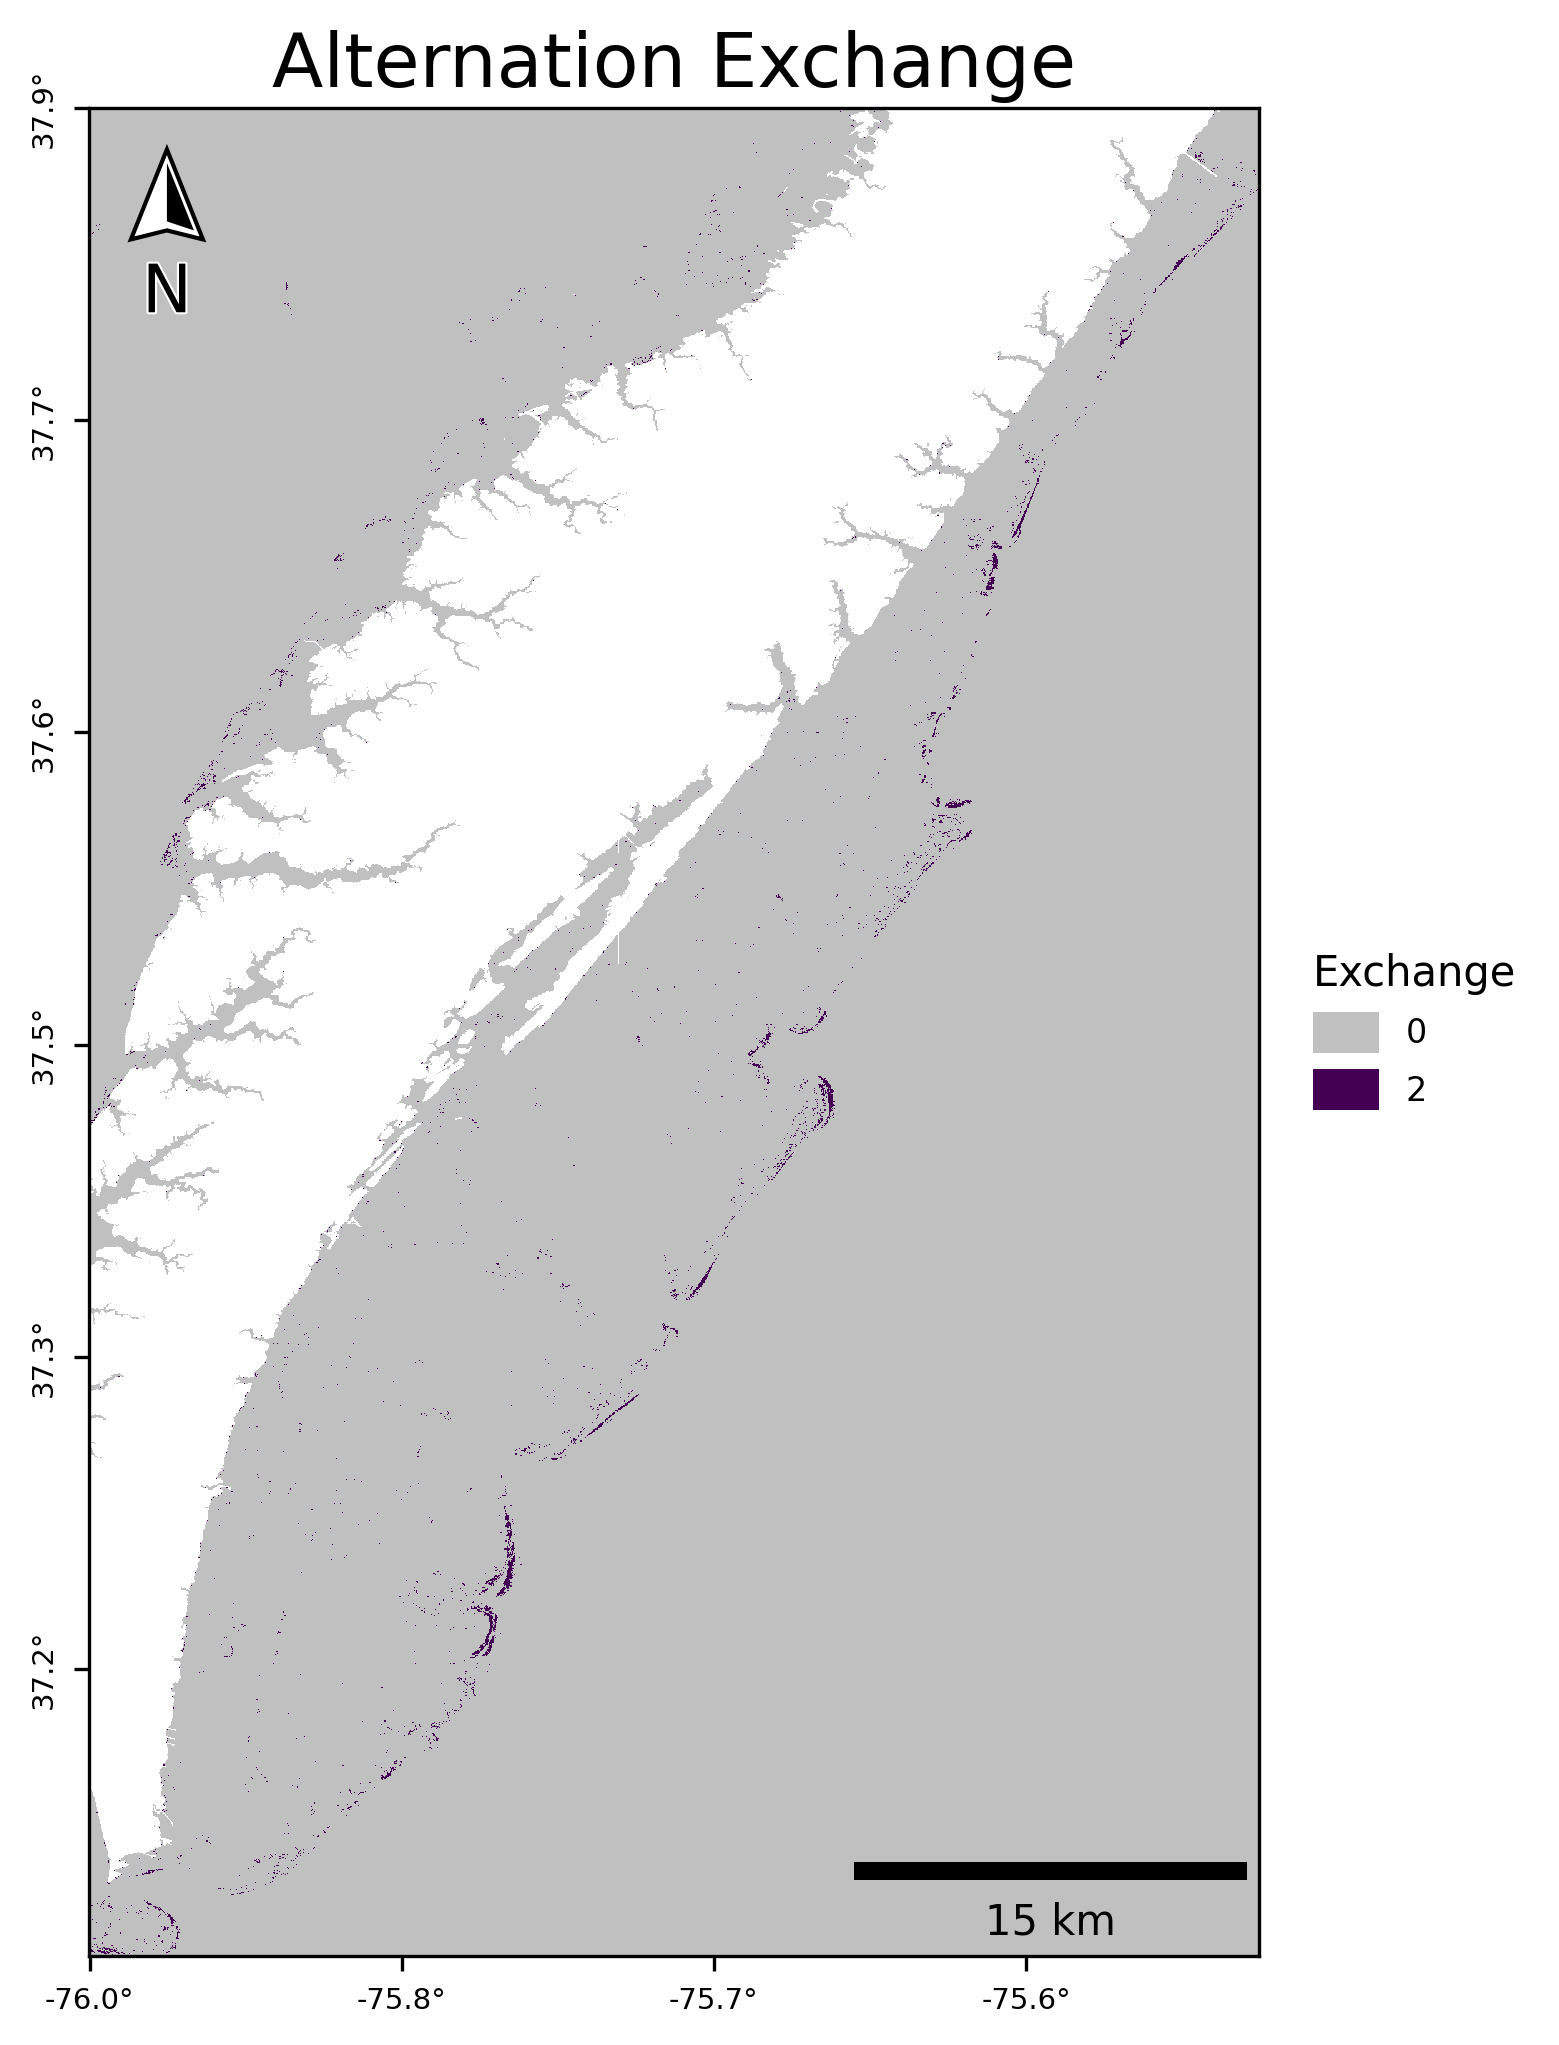

Map figure saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/maps/map_alternation_exchange.png


In [ ]:
# @title 7.6.4 Plot alternation exchange map
def plot_alternation_exchange_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "map_alternation_exchange.tif",
) -> None:
    """
    Plot the Alternation Exchange map using a discrete integer scale.

    The visualization uses a specific color logic where the value 0 is
    represented in gray (indicating stability or absence of exchange),
    while values greater than or equal to 1 are represented by a
    gradient color scale (e.g., from pink to dark red) to indicate
    the intensity of the exchange.

    Parameters
    ----------
    output_dir : str
        The directory path containing the input raster file and where
        the output image will be saved.
    raster_filename : str, optional
        The filename of the raster to be plotted (default is
        "map_alternation_exchange.tif").

    Returns
    -------
    None
        The function saves a PNG image to the output directory and
        displays the plot.

    Raises
    ------
    FileNotFoundError
        If the specified raster file does not exist in the output directory.
    """
    # 1. Input Validation and Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename,
    )

    if not os.path.exists(
        raster_path,
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}",
        )

    print(
        f"Reading alternation exchange raster for plotting: {raster_path}",
    )

    pixel_size_km = compute_display_pixel_size_km(
            raster_path=raster_path,
            downsample_divisor=1
        )

    # 2. Data Loading and Masking
    with rasterio.open(
        raster_path,
    ) as src:
        scale_factor = 1
        data = src.read(
            1,
            out_shape=(
                int(src.height * scale_factor),
                int(src.width * scale_factor),
            ),
            resampling=rasterio.enums.Resampling.nearest,
        )

        # Force masking using the provided variable
        data_masked = np.ma.masked_equal(
            data,
            nodata_val,
        )

        left, bottom, right, top = src.bounds
        src_crs = src.crs
        transform = src.transform

    # Determine the integer range for the color scale
    data_max = int(
        data_masked.max(),
    )

    # Ensure at least 1 to prevent errors if the map is empty/flat
    if data_max == 0:
        data_max = 1

    # 3. Discrete Colormap Configuration
    original_cmap = plt.get_cmap("viridis_r")
    # Define the color for value 0 (Background/Gray)
    colors_list = ["#c0c0c0"] + [
        original_cmap(i) for i in np.linspace(0, 1, data_max)
    ]

    # Create the custom discrete colormap
    cmap = ListedColormap(
        colors_list,
    )

    # 4. Define Boundaries (Bins) for Integers
    # Create boundaries for every integer from 0 to max + 1
    bounds = np.arange(
        0,
        data_max + 2,
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N,
    )

    # 5. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            8,
        ),
        dpi=300,
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    # 6. Legend Configuration
    legend_elements = []

    # Extract unique values actually present in the masked raster data
    present_values = np.unique(
        data_masked.compressed()
    )

    for i in range(0, data_max + 1):
        # Append to legend ONLY if the value is present in the map
        if i in present_values:
            legend_elements.append(
                Patch(
                    facecolor=cmap(norm(i)),
                    edgecolor="none",
                    linewidth=0,
                    label=str(i),
                ),
            )

    ax.legend(
        handles=legend_elements,
        title="Exchange",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left",
        handlelength=2.0,
        handleheight=1.5,
    )

    # 7. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_km,
        units="km",
        length_fraction=0.35,
        location="lower right",
        box_alpha=0.0,
        scale_formatter=lambda value, _: f"{int(value)} km",
    )
    ax.add_artist(
        scalebar,
    )

    # 8. North Arrow
    north_arrow(
        ax,
        location="upper left",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3
    )

    # 9) Axes styling (with Lat/Lon labels)
    ax.set_title(
        "Alternation Exchange",
        fontsize=18,
        pad=5,
    )
    ax.set_aspect(
        "equal",
    )

    # Initialize Transformer (Native CRS -> Lat/Lon)
    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )

    # Get dimensions from the loaded data
    height, width = data.shape

    def format_lon(
        x,
        pos,
    ):
        """
        Convert a pixel row index to a formatted Latitude string.

        This function calculates the latitude corresponding to the specific
        row (y) at the horizontal center of the image.

        Parameters
        ----------
        y : float
            The pixel row index (y-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The latitude coordinate formatted as a string with one decimal
            place and a degree symbol (e.g., "-12.5°").
        """
        # Clamp x to be within image bounds
        x = np.clip(
            x,
            0,
            width - 1,
        )
        # Project pixel to map coordinates (using middle of height)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            height // 2,
            x,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lon:.1f}°"

    def format_lat(
        y,
        pos,
    ):
        """
        Convert a pixel column index to a formatted Longitude string.

        This function calculates the longitude corresponding to the specific
        column (x) at the vertical center of the image.

        Parameters
        ----------
        x : float
            The pixel column index (x-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The longitude coordinate formatted as a string with one decimal
            place and a degree symbol (e.g., "-45.5°").
        """
        # Clamp y to be within image bounds
        y = np.clip(
            y,
            0,
            height - 1,
        )
        # Project pixel to map coordinates (using middle of width)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            y,
            width // 2,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lat:.1f}°"

    # Apply the custom formatters
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            format_lon,
        ),
    )
    ax.yaxis.set_major_formatter(
        FuncFormatter(
            format_lat,
        ),
    )

    # Limit ticks to avoid overcrowding
    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=4,
        ),
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=6,
        ),
    )

    # Final styling for ticks
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        pad=4,
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=90,
        va="center",
    )

    maps_dir = os.path.join(
        output_dir,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    output_figure_path = os.path.join(
        maps_dir,
        "map_alternation_exchange.png",
    )

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png",
        bbox_inches="tight",
        pad_inches=0.5,
    )
    plt.show()

    print(
        f"Map figure saved to: {output_figure_path}",
    )

# Execute the function
plot_alternation_exchange_map(
    output_path,
    nodata_val=noData_value,
)

Reading alternation shift raster for plotting: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/rasters/map_alternation_shift.tif


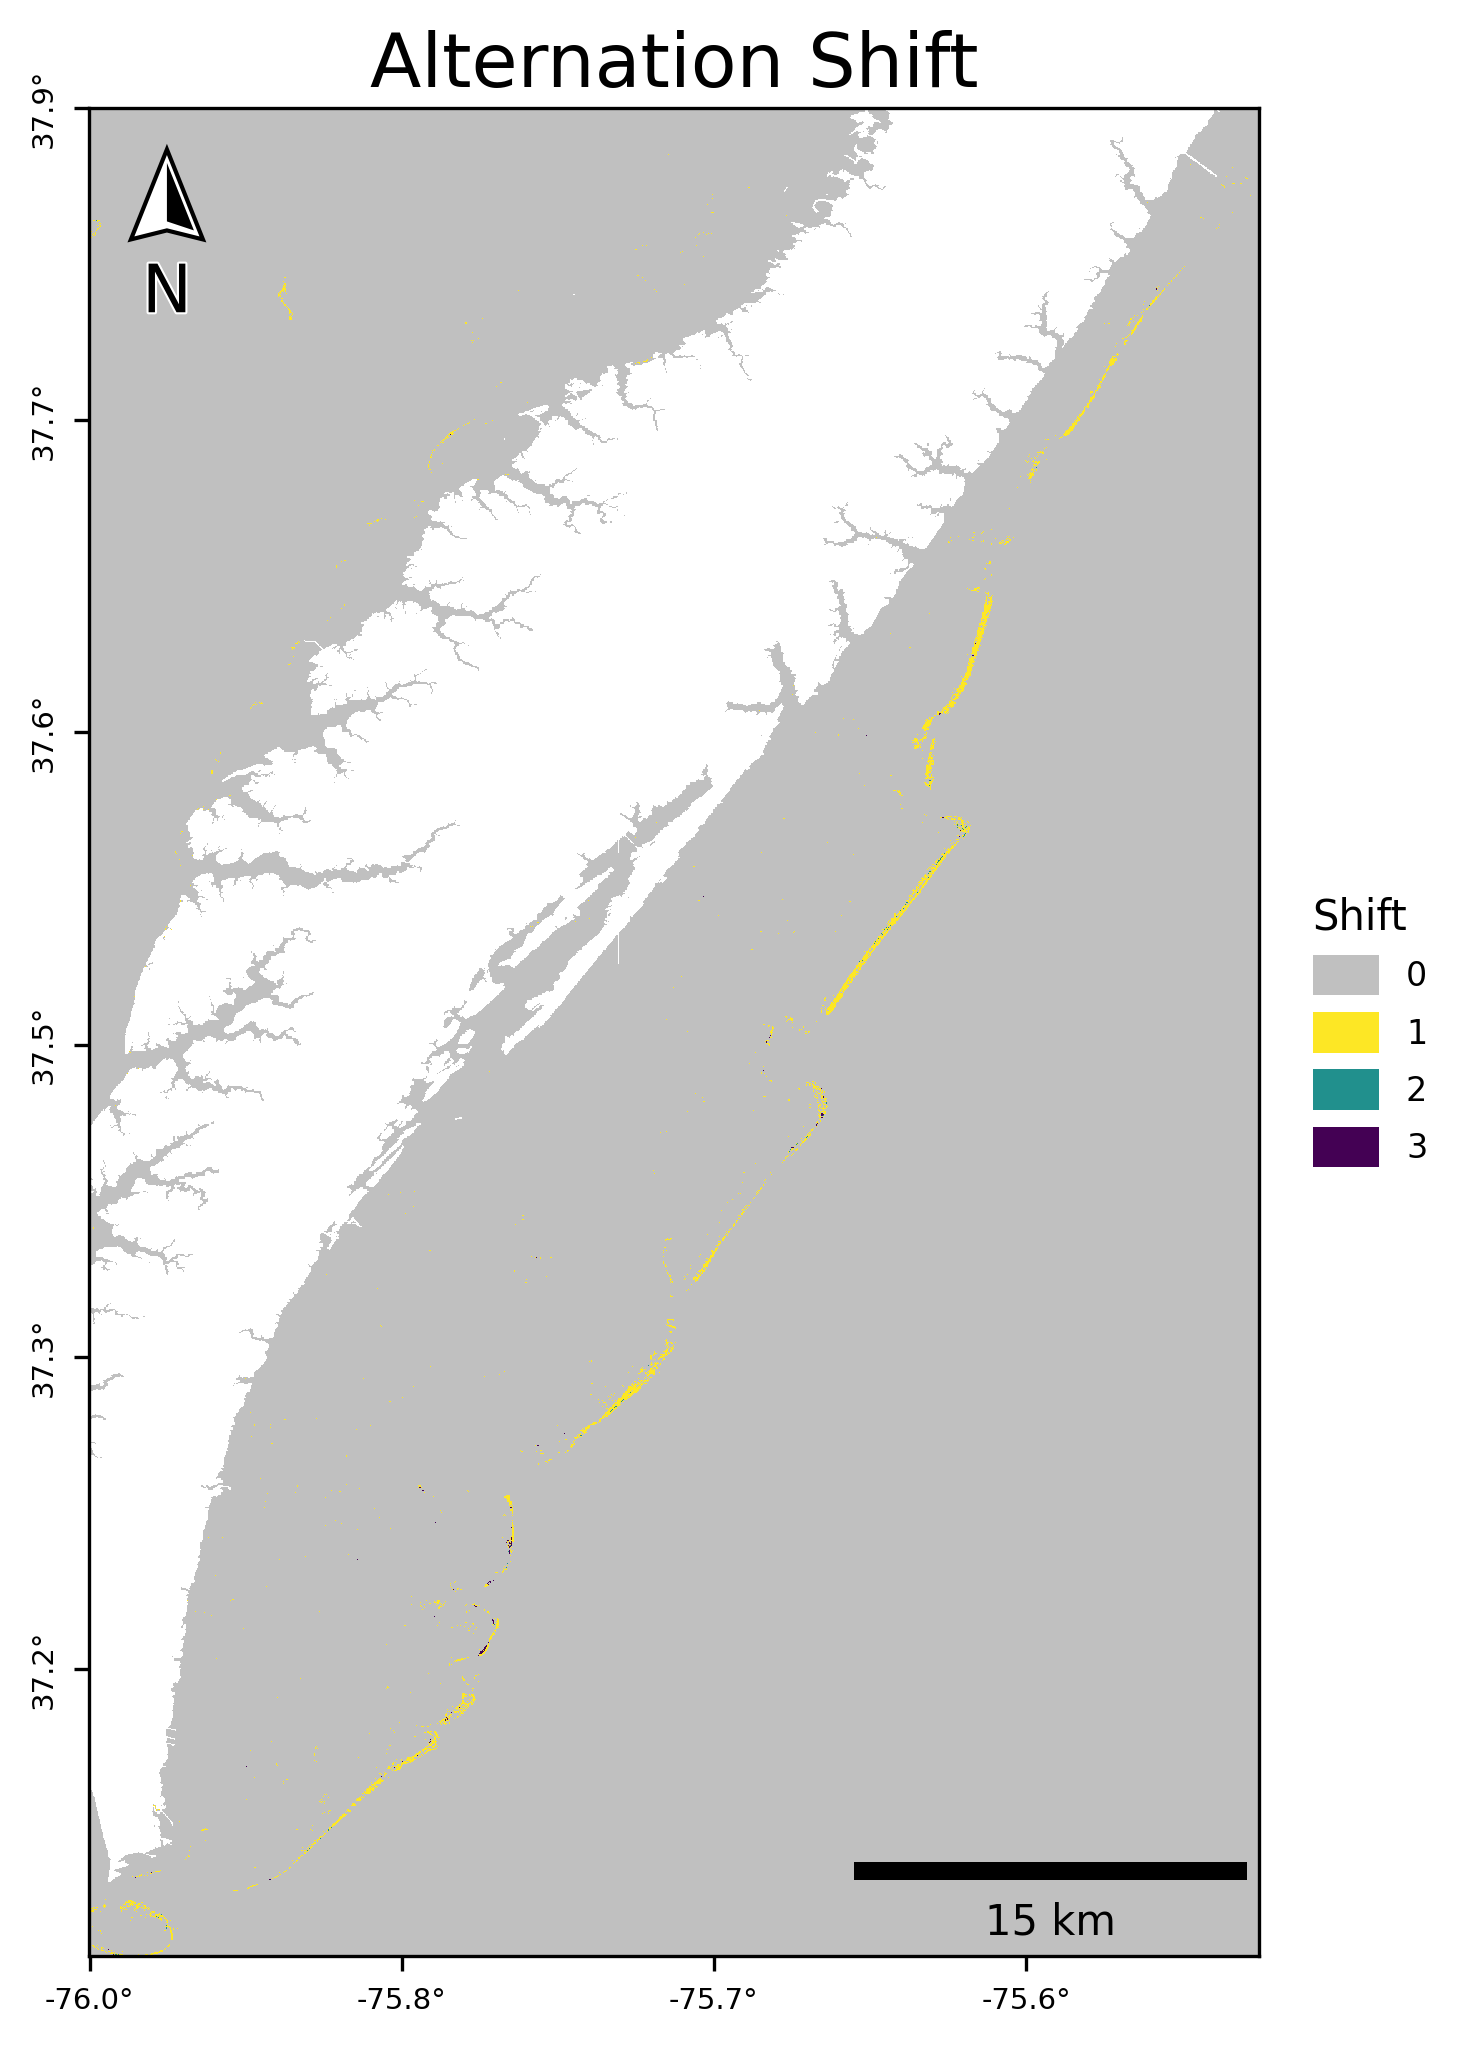

Map figure saved to: /content/drive/MyDrive/Events/2026CGA/workshop/dataset/quest_output_2/maps/map_alternation_shift.png


In [ ]:
# @title 7.6.6 Plot alternation shift map
def plot_alternation_shift_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "map_alternation_shift.tif",
) -> None:
    """
    Plot the Alternation Shift map using a discrete integer scale.

    The visualization uses a specific color logic where the value 0 is
    represented in gray (indicating stability or absence of shift),
    while values greater than or equal to 1 are represented by a
    gradient color scale (e.g., from green to dark green) to indicate
    the intensity of the shift.

    Parameters
    ----------
    output_dir : str
        The directory path containing the input raster file and where
        the output image will be saved.
    raster_filename : str, optional
        The filename of the raster to be plotted (default is
        "map_alternation_shift.tif").

    Returns
    -------
    None
        The function saves a PNG image to the output directory and
        displays the plot.

    Raises
    ------
    FileNotFoundError
        If the specified raster file does not exist in the output directory.
    """
    # 1. Input Validation and Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename,
    )

    if not os.path.exists(
        raster_path,
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}",
        )

    print(
        f"Reading alternation shift raster for plotting: {raster_path}",
    )

    pixel_size_km = compute_display_pixel_size_km(
            raster_path=raster_path,
            downsample_divisor=1
        )

    # 2. Data Loading and Masking
    with rasterio.open(
        raster_path,
    ) as src:
        scale_factor = 1
        data = src.read(
            1,
            out_shape=(
                int(src.height * scale_factor),
                int(src.width * scale_factor),
            ),
            resampling=rasterio.enums.Resampling.nearest,
        )

        # Force masking using the provided variable
        data_masked = np.ma.masked_equal(
            data,
            nodata_val,
        )

        left, bottom, right, top = src.bounds
        src_crs = src.crs
        transform = src.transform

    # Determine the integer range for the color scale
    data_max = int(
        data_masked.max(),
    )

    # Ensure at least 1 to prevent errors if the map is empty/flat
    if data_max == 0:
        data_max = 1

    # 3. Discrete Colormap Configuration
    original_cmap = plt.get_cmap("viridis_r")

    #colors_list = ["#c0c0c0"] + [
    colors_list = ["#c0c0c0"] + [
        original_cmap(i) for i in np.linspace(0, 1, data_max)
    ]

    cmap = ListedColormap(
        colors_list,
    )

    # 4. Define Boundaries (Bins) for Integers
    # Create boundaries for every integer from 0 to max + 1
    bounds = np.arange(
        0,
        data_max + 2,
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N,
    )

    # 5. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(
            6,
            8,
        ),
        dpi=300,
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    # 6. Legend Configuration
    legend_elements = []

    # Extract unique values actually present in the masked raster data
    present_values = np.unique(
        data_masked.compressed()
    )

    for i in range(0, data_max + 1):
        # Append to legend ONLY if the value is present in the map
        if i in present_values:
            legend_elements.append(
                Patch(
                    facecolor=cmap(norm(i)),
                    edgecolor="none",
                    linewidth=0,
                    label=str(i),
                ),
            )

    ax.legend(
        handles=legend_elements,
        title="Shift",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left",
        handlelength=2.0,
        handleheight=1.5,
    )

    # 7. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_km,
        units="km",
        length_fraction=0.35,
        location="lower right",
        box_alpha=0.0,
        scale_formatter=lambda value, _: f"{int(value)} km",
    )
    ax.add_artist(
        scalebar,
    )

    # 8. North Arrow
    north_arrow(
        ax,
        location="upper left",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3
    )

    # 8) Axes styling (with Lat/Lon labels)
    ax.set_title(
        "Alternation Shift",
        fontsize=18,
        pad=5,
    )
    ax.set_aspect(
        "equal",
    )

    # Initialize Transformer (Native CRS -> Lat/Lon)
    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )

    # Get dimensions from the loaded data
    height, width = data.shape

    def format_lon(
        x,
        pos,
    ):
        """
        Convert a pixel column index to a formatted Longitude string.

        This function calculates the longitude corresponding to the specific
        column (x) at the vertical center of the image.

        Parameters
        ----------
        x : float
            The pixel column index (x-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The longitude coordinate formatted as a string with one decimal
            place and a degree symbol (e.g., "-45.5°").
        """
        # Clamp x to be within image bounds
        x = np.clip(
            x,
            0,
            width - 1,
        )
        # Project pixel to map coordinates (using middle of height)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            height // 2,
            x,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lon:.1f}°"

    def format_lat(
        y,
        pos,
    ):
        """
        Convert a pixel row index to a formatted Latitude string.

        This function calculates the latitude corresponding to the specific
        row (y) at the horizontal center of the image.

        Parameters
        ----------
        y : float
            The pixel row index (y-axis coordinate) from the plot.
        pos : float
            The tick position. This argument is required by matplotlib's
            FuncFormatter interface but is not used in the calculation.

        Returns
        -------
        str
            The latitude coordinate formatted as a string with one decimal
            place and a degree symbol (e.g., "-12.5°").
        """
        # Clamp y to be within image bounds
        y = np.clip(
            y,
            0,
            height - 1,
        )
        # Project pixel to map coordinates (using middle of width)
        x_proj, y_proj = rasterio.transform.xy(
            transform,
            y,
            width // 2,
        )
        lon, lat = to_latlon.transform(
            x_proj,
            y_proj,
        )
        return f"{lat:.1f}°"

    # Apply the custom formatters
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            format_lon,
        ),
    )
    ax.yaxis.set_major_formatter(
        FuncFormatter(
            format_lat,
        ),
    )

    # Limit ticks to avoid overcrowding
    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=4,
        ),
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            nbins=6,
        ),
    )

    # Final styling for ticks
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        pad=4,
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=90,
        va="center",
    )

    maps_dir = os.path.join(
        output_dir,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    output_figure_path = os.path.join(
        maps_dir,
        "map_alternation_shift.png",
    )

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png",
        bbox_inches="tight",
        pad_inches=0.5,
    )
    plt.show()

    print(
        f"Map figure saved to: {output_figure_path}",
    )

# Execute the function
plot_alternation_shift_map(
    output_dir=output_path,
    nodata_val=noData_value,
    raster_filename="map_alternation_shift.tif",
)